# Notebook 15 - freezing the water model (C0), and the sediment-data quality gate (C1)

**What this notebook is.** Two decisions, documented end to end.

**C0 - freeze the hydrology.** This project simulates how much mud a large river carries. Mud
is carried by water, so a sediment model sits on top of a water model. Before any sediment
number is computed, the water model is *frozen*: its parameters, its outputs and its measured
skill are written to files that nothing downstream may change. The reason is blunt - a
sediment result that moves because the water model shifted underneath it is not a result, it
is an artefact of when you happened to run it.

**C1 - gate the sediment observations.** The project's target is *measured* sediment
concentration at river gauges. This notebook shows why the word "measured" cannot be taken at
face value, classifies all 79 sediment stations in the network, and reports how few survive.

**Who this is written for.** Someone competent who has never seen this project and does not
work in hydrology. Every technical term is defined in plain language the first time it is
used, before any formula. If you already know the vocabulary, the definitions are short
enough to skim.

**The single most transferable idea in this notebook is in section 5**, and it is not about
sediment: *a screen that inspects values cannot see records that are absent.* This project
learnt that the hard way in its rainfall network, where 153 of 294 gauges had silently
omitted their dry days, and the notebook then applies the same test to the sediment network.
If you read one section, read that one.

---

## 0 - How to read this notebook

Three conventions, applied without exception:

1. **Before every code cell** there is a markdown cell that states what the cell computes as
   an equation, defines every symbol with its physical units, and names the file each input
   comes from. Cells that only load or reshape data say so, and state the array shape and
   units they produce.
2. **After every figure** there is a three-part reading: **What is plotted** (axes, units,
   what each colour and marker means), **What it shows** (the numbers actually visible,
   quoted from the executed output above), **What it means** (the consequence for the
   project, including "this refutes X" or "this is inconclusive because Y" where that is the
   honest reading).
3. **Numbers are quoted from executed output, never from a document's prose.** Where a
   document and an artifact disagree, the disagreement is reported rather than smoothed. Two
   such disagreements are reported below (sections 2.6 and 5.2); neither was known before
   this notebook was written.

**Vocabulary you need in the first two sections** - each is defined properly where it first
appears, this is only a map:

| term | section | one line |
|---|---|---|
| minibacia, URH | 1.1 | the model's spatial and land-surface units |
| water balance, saturation-excess runoff | 1.1 | how rain becomes river flow in this model |
| surface runoff vs baseflow, baseflow index, Eckhardt filter | 1.2 | the fast and slow parts of a river's flow, and how they are separated |
| objective function, DDS, pre-registration | 1.3 | how the model was fitted, and the discipline around it |
| Klemes differential split-sample | 1.4 | why the fit is tested on the years it never saw |
| PET vs actual ET | 2.1 | the water the atmosphere *could* take vs what it actually takes |
| KGE and its three components r, alpha, beta; NSE; PBIAS | 2.2 | the skill scores, and what each one is blind to |
| climatology benchmark, skill over climatology | 2.3 | the yardstick that makes windows comparable |
| recession constant | 2.4 | how fast a river drains when it stops raining |
| railed parameter, equifinality | 2.5 | two ways a good fit can be meaningless |
| POT, annual maximum series | 2.6 | how flood peaks are counted |
| IDW, LOOCV, quantile mapping | 2.7 | how the rainfall field was built, tested and (not) merged |
| SSC, rating curve | 4 | suspended-sediment concentration, and why discharge is also modelled |
| MUSLE and its factors, sediment delivery ratio, specific erosion | 9 | what C1's output feeds into |

---

## 0.1 - Inputs, and the rule that nothing is improvised

Every input is a file that already exists. If one is missing the notebook stops rather than
falling back to a substitute, because a silently substituted input is how a wrong number
becomes a published number.

| file | what it holds | why this notebook needs it |
|---|---|---|
| `sim_calibrated_v2/report_H2E.json` | the C0 stage report: reproduction gate, parameters, mass balance, skill by period | the frozen record of the water model |
| `sim_calibrated_v2/parameters_H2E.csv` | 18 fitted parameter values with position in range and a railed flag | section 2.5 |
| `sim_calibrated_v2/metrics_fleet.csv` | fleet-median skill, 4 configurations x 6 periods | sections 2.2-2.4 |
| `sim_calibrated_v2/q_gauge_H2E.npz` | daily observed / prior / fitted / climatology discharge, 3652 days x 63 gauges | every hydrology figure, and the independent recomputation in 2.2 |
| `sediment_inventory_qc.csv` | 79 sediment stations with the C1 class and the measurement that decided it | sections 6-8 |
| `sediment_daily_qc.csv` | 269,337 daily sediment rows with every C1 flag | sections 5-6 |
| `sediment_daily.csv` | the same rows *before* C1 | to prove C1 deleted nothing |
| `sediment_coverage_census.csv` | samples per station per year | section 6.1 |
| `ssc_sampling_selectivity.csv` | the flow-selectivity statistic per station | section 5.3 |
| `ssc_rating_fits.csv` | 30 sediment rating fits with two R-squared definitions | sections 4.2 and 6.3 |
| `discharge_daily.csv` | raw daily river flow | to reproduce the selectivity statistic from scratch (5.3) |
| `precip_gauges_daily_qc_v2.csv` | the repaired rainfall gauge records, with inferred dry days marked | section 5.1, the transposed lesson |
| `precip_selectivity_report.csv` | the rainfall neighbour-selectivity statistic, before and after repair | section 5.1 |

The three frozen artifacts (`parameters_H2E.csv`, `q_gauge_H2E.npz`, and the driver archive
`h2e_drivers.npz`) are opened **read-only** here. This notebook has no code path that writes
to `data/processed/`.

In [1]:
import json, pathlib, sys, hashlib, warnings, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
%matplotlib inline
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': False, 'font.size': 9,
                     'axes.titlesize': 10, 'figure.autolayout': False})
warnings.filterwarnings('ignore', category=RuntimeWarning)

REPO = None
for b in [pathlib.Path.cwd()] + list(pathlib.Path.cwd().parents):
    if (b / 'src').is_dir() and (b / 'data' / 'processed').is_dir():
        REPO = b
        break
if REPO is None:
    raise SystemExit('cannot locate the repository root')
PROC = REPO / 'data' / 'processed'
SIM = PROC / 'sim_calibrated_v2'

NEED = {
    'report':    SIM / 'report_H2E.json',
    'params':    SIM / 'parameters_H2E.csv',
    'fleet':     SIM / 'metrics_fleet.csv',
    'qgauge':    SIM / 'q_gauge_H2E.npz',
    'inv_qc':    PROC / 'sediment_inventory_qc.csv',
    'daily_qc':  PROC / 'sediment_daily_qc.csv',
    'daily_raw': PROC / 'sediment_daily.csv',
    'inv_raw':   PROC / 'sediment_inventory.csv',
    'census':    PROC / 'sediment_coverage_census.csv',
    'select':    PROC / 'ssc_sampling_selectivity.csv',
    'ratings':   PROC / 'ssc_rating_fits.csv',
    'eras':      PROC / 'ssc_station_eras.csv',
    'discharge': PROC / 'discharge_daily.csv',
    'precip_v2': PROC / 'precip_gauges_daily_qc_v2.csv',
    'precip_sel': PROC / 'precip_selectivity_report.csv',
}
missing = {k: str(v) for k, v in NEED.items() if not v.exists()}
if missing:
    raise SystemExit(f'PREREQUISITES MISSING, stopping rather than improvising: {missing}')

print(f'repo  {REPO}')
print(f'{"key":<10s} {"MB":>9s}  {"sha256[:12]":<14s} file')
for k, v in NEED.items():
    h = hashlib.sha256(v.read_bytes()).hexdigest()[:12] if v.stat().st_size < 6e8 else '(too large)'
    print(f'{k:<10s} {v.stat().st_size/1e6:>9.2f}  {h:<14s} {v.relative_to(REPO)}')

REPORT = json.loads(NEED['report'].read_text(encoding='utf-8'))
print(f'\nreport_H2E.json: stage {REPORT["stage"]}, cell {REPORT["cell"]}, '
      f'best seed {REPORT["best_seed"]}, written by {REPORT["generated_by"]}')
print(f'  engine sha256 {REPORT["provenance"]["engine_sha256"][:16]}  '
      f'search code {REPORT["provenance"]["calib_v2_sha256"][:16]}')

repo  C:\dev\magdalena-mgb-sed
key               MB  sha256[:12]    file
report          0.01  60df921d7fb4   data\processed\sim_calibrated_v2\report_H2E.json
params          0.00  cfe68790db22   data\processed\sim_calibrated_v2\parameters_H2E.csv
fleet           0.01  c8052df034a4   data\processed\sim_calibrated_v2\metrics_fleet.csv
qgauge          3.02  d545d98a8b6e   data\processed\sim_calibrated_v2\q_gauge_H2E.npz
inv_qc          0.02  fb0690fd81a1   data\processed\sediment_inventory_qc.csv
daily_qc       24.02  0bc6b5e2a763   data\processed\sediment_daily_qc.csv
daily_raw      15.88  6e4c5e5a0d84   data\processed\sediment_daily.csv
inv_raw         0.01  3c552bb66c5b   data\processed\sediment_inventory.csv
census          0.05  ada0d895f844   data\processed\sediment_coverage_census.csv
select          0.01  8cddeb3c6f84   data\processed\ssc_sampling_selectivity.csv
ratings         0.01  4268fe3f09df   data\processed\ssc_rating_fits.csv
eras            0.00  6ce1e5b6b2bb   data\proc

discharge      49.85  0d5037198a9f   data\processed\discharge_daily.csv
precip_v2      34.33  dee8de4facb2   data\processed\precip_gauges_daily_qc_v2.csv
precip_sel      0.04  dde46ca3466a   data\processed\precip_selectivity_report.csv

report_H2E.json: stage C0, cell H2E, best seed 20260901, written by src/report_h2e.py
  engine sha256 93b180a9113f5946  search code 3aa4f8b6d637ff24


---

# 1 - What "freezing" the hydrology means, and why sediment work requires it

## 1.1 - The water model in one page, with the vocabulary

Almost nothing below is unusual for hydrology; it is written out because the audience is
assumed not to know it.

**The basin.** The Magdalena-Cauca basin drains 257,097 km squared of Colombia into the
Caribbean. It is represented as **8,672 minibacias**. A **minibacia** ("small basin" in
Portuguese - the model, MGB, is Brazilian) is one unit catchment: a patch of land, roughly
30 km squared here, that drains into one river reach. Each minibacia knows which minibacia is
immediately downstream of it, so the 8,672 units form a tree, and water is passed down that
tree.

**The land surface inside a minibacia.** Rain does not behave the same way on bare rock and on
deep forest soil, so each minibacia is subdivided by *type* rather than by location, into
**URH** units - *unidades de resposta hidrologica*, in English **HRU**, hydrological response
units. A URH is a combination of land cover and soil class (here 24 of them, from IGAC soil
maps crossed with land cover). Every point in a minibacia belonging to the same URH is assumed
to respond to rain identically, so the model stores only the *fraction* of the minibacia
occupied by each URH, not a map. This is the standard trade: it discards spatial detail inside
the minibacia and buys the ability to run 8,672 units for 11 years in minutes.

**The water balance.** For each URH of each minibacia, on each day, the model keeps a soil
water store $W$ (mm) and closes an accounting identity:

$$W_{t+1} \;=\; W_t \;+\; P_t \;-\; E_t \;-\; D^{sup}_t \;-\; D^{int}_t \;-\; D^{bas}_t$$

where $P$ is rainfall (mm/day), $E$ is evapotranspiration - water leaving as vapour, from soil
and plants (mm/day) - and the three $D$ terms are drainage out of the store into three
pathways. A **water balance** is exactly this: in minus out equals change in storage, with no
term unaccounted for. Because it is an identity rather than an approximation, it can be
checked to machine precision, and it is: `report_H2E.json` records a relative residual of
$9.66\times10^{-17}$, i.e. the arithmetic loses nothing beyond floating-point round-off.

**Saturation-excess runoff.** How much rain runs off the surface instead of soaking in? Two
mechanisms compete in nature. *Infiltration excess* means rain falls faster than the soil can
absorb it, so the surplus runs off even though the soil is dry. *Saturation excess* means the
soil is already full, so any further rain must run off. MGB uses **saturation excess** only: a
statistical distribution of storage capacity across the URH decides what fraction of it is
already saturated on a given day, and rain on that fraction becomes surface runoff. This
choice is a known limitation and is revisited in section 2.6, because it is one of the two
candidate explanations for the model's missing flood peaks - and both were tested and refuted.

**Surface runoff versus baseflow.** The three drainage pathways differ in speed.
**Surface runoff** ($D^{sup}$) is the fast water that travels over or just below the ground and
reaches the river within a day or two; it is the part that carries eroded soil, which is why
the sediment model cares about it specifically rather than about total flow. **Baseflow**
($D^{bas}$) is the slow water that has percolated to groundwater and seeps into the channel for
weeks or months; it is what keeps a river running in a drought. **Interflow** ($D^{int}$) is
the intermediate lateral flow through the soil. Each pathway is passed through a **linear
reservoir**, a delay element whose output is proportional to its content, with a characteristic
time $k$ in days - and it is those three $k$ values that section 2.5 shows are physically
inverted in the adopted fit.

**Discharge.** Summed over URHs, routed down the minibacia tree with a channel celerity, the
model produces **discharge** $Q$ - the volume of water passing a cross-section per second, in
m^3/s. That is the quantity compared against river gauges, and the only hydrological quantity
this project can validate against observations.

## 1.2 - What sediment work needs from the water model, and it is not total flow

The sediment engine (built in stage C3, not here) needs three things per minibacia per day:
surface runoff volume, a peak-flow rate, and channel discharge. Two of them are *parts* of
the flow, not the flow itself, and a model can get the total right while getting the split
wrong. That risk has a name in this project's record and a measured answer.

**Baseflow index (BFI).** The fraction of a river's total flow that arrives as baseflow:

$$\mathrm{BFI} \;=\; \frac{\sum_t b(t)}{\sum_t Q(t)}$$

where $b(t)$ is the baseflow component (m^3/s) and $Q(t)$ is total discharge (m^3/s).
Dimensionless, bounded in $[0,1]$. A BFI of 0.7 means seven tenths of the water arrives
slowly - and therefore that only three tenths of it is the fast, sediment-carrying kind.

**The Eckhardt filter** is how $b(t)$ is obtained from $Q(t)$ when you have no way to measure
baseflow directly. It is a recursive digital filter - a two-parameter smoother run over the
discharge series - that separates a slowly varying lower envelope from the spiky remainder.
It is *not* a measurement: it is a convention with two tunable constants, and different
constants give different BFIs on the same river. Stage C2b used it to test whether the frozen
water model splits flow the way observations do; that test (docs/33 §6) is inherited here and
not re-run.

**Why this matters for freezing.** If the sediment stage were allowed to nudge the water model
- "the sediment fits better if surface runoff were larger" - it would be fitting the water
model to sediment data through a back door, and the resulting agreement would be
uninformative. Freezing removes the back door. The cost is honest: the frozen water model's
known defects, listed in section 2, are inherited by every sediment number, unimproved.

## 1.3 - How the water model was fitted, and the discipline around it

**Objective function.** A single number that scores a whole simulation, which a search
algorithm then maximises. Here it is a weighted blend of three per-gauge terms, averaged over
63 gauges: skill on daily discharge, skill on log-discharge (which weights low flows), and a
recession-shape term (section 2.4). The blend is

$$F \;=\; \frac{1}{N_g}\sum_g \frac{w_Q\mathcal{B}(\mathrm{KGE}_g) + w_L\mathcal{B}(\mathrm{KGE}^{\log}_g) + w_R \mathcal{B}(E^{rec}_g)}{\sum_{\text{defined terms}} w}$$

with $(w_Q, w_L, w_R) = (0.40, 0.40, 0.20)$ and $\mathcal{B}(k) = k/(2-k)$ a bounding transform
that stops one catastrophic gauge from dominating. $F = 1$ is a perfect simulation.
**The adopted configuration H2E scores $F = 0.25931$**, and reproducing that number to
$10^{-8}$ is the gate in section 3.

**DDS** - Dynamically Dimensioned Search (Tolson and Shoemaker, 2007) - is the search
algorithm. It has one tuning constant, starts by perturbing many parameters at once and
narrows to few as the budget is spent, and reflects off the edges of the search box rather than
sticking to them. It was chosen over gradient methods (the objective is not differentiable
through the routing) and over evolutionary algorithms (which need far more evaluations for the
same result at this dimensionality). Each of the two H2E searches spent 1,000 model
evaluations.

**Pre-registration** is this project's governing discipline: before the numbers that will be
judged are computed, the thresholds and decision rules that will judge them are written into a
numbered document and frozen. H2E was registered in `docs/29` §3(b); the sediment gate this
notebook documents was registered in `docs/32` §0-§6 *before* any of its numbers existed.
The purpose is narrow and important: it makes "the threshold was tuned to the answer"
checkable rather than a matter of trust. Where a registered rule turned out to be
unsatisfiable, the project's rule is to record that and use the registered fallback, not to
edit the registration - and section 5.4 is exactly that case.

## 1.4 - Why the fit is judged on years it never saw

**Klemes differential split-sample test** (Klemes, 1986). The strong form of model validation:
fit the model on one climatic regime and test it on a *different* one. Here the model is fitted
on **2012-2014 only** - three consecutive ENSO-neutral years, neither unusually wet nor
unusually dry - and validated on everything else, including the two years the whole project is
about: the La Nina wet extreme of 2011 and the El Nino dry extreme of 2015-16.

The alternative - fitting on all years and reporting the fit - was rejected for a reason
specific to this project rather than for orthodoxy. The project's headline claim is a
*contrast between* La Nina and El Nino. If either extreme were inside the calibration window,
the model would have been told the answer, and the contrast would be partly a restatement of
the fitting data. Under the differential split-sample, every ENSO number in this notebook is
an **out-of-sample prediction**, and is labelled as such wherever it appears.

The six reporting periods used throughout:

| period | days | role |
|---|---|---|
| `CAL 2012-14` | 2012-01-01 to 2014-12-31 | the only years the fit saw |
| `VAL La Nina 11` | calendar 2011 | out-of-sample wet extreme |
| `VAL El Nino 15-16` | 2015-01-01 to 2016-12-31 | out-of-sample dry extreme |
| `VAL other 09/10/17` | 2009, 2010, 2017 | out-of-sample neutral-ish |
| `VAL 2018` | calendar 2018 | out-of-sample, only exists in the v2 forcing |
| `VAL all` | everything except CAL | the headline validation row |

### Cell: load the frozen discharge archive and define the six periods

This cell only loads and reshapes. It reads `sim_calibrated_v2/q_gauge_H2E.npz` and produces
four arrays of shape (3652 days, 63 gauges), all in **m^3/s**:

| array | meaning |
|---|---|
| `QOBS` | observed discharge at the gauge, from IDEAM records (NaN where missing) |
| `QFIT` | simulated discharge at the **adopted** H2E parameters |
| `QPRIOR` | simulated discharge at the **prior** parameters, i.e. before any fitting |
| `QCLIM` | the day-of-year climatology of the observations (section 2.3) |

plus `DATES` (3652 daily timestamps, 2009-01-01 to 2018-12-31), `GC` (63 gauge codes) and
`AREA` (upstream catchment area per gauge, km^2 - carried for labelling only; per-gauge areas
are unreliable in this project, see section 8.4, so nothing here is divided by them).

The period masks are built from the date axis, not read from a file, so that a mislabelled
period cannot propagate silently. Their day counts are printed and must sum correctly.

In [2]:
z = np.load(NEED['qgauge'], allow_pickle=True)
DATES = pd.DatetimeIndex(np.asarray(z['dates'], dtype='datetime64[ns]'))
GC = z['gauge_code'].astype(str)
AREA = z['gauge_upstream_area_km2'].astype(float)
QOBS = z['q_obs_m3s'].astype(np.float64)
QFIT = z['q_sim_fit_m3s'].astype(np.float64)
QPRIOR = z['q_sim_prior_m3s'].astype(np.float64)
QCLIM = z['q_clim_m3s'].astype(np.float64)
NT, NG = QOBS.shape
print(f'q_gauge_H2E.npz: {NT} days x {NG} gauges, {DATES[0].date()} .. {DATES[-1].date()}')
print(f'  arrays all m3/s; observed valid gauge-days {int(np.isfinite(QOBS).sum()):,} '
      f'({100*np.isfinite(QOBS).mean():.1f} % filled)')
print(f'  upstream areas {AREA.min():,.0f} .. {AREA.max():,.0f} km2 (labels only, never a divisor)')

Y = DATES.year
PERIODS = {
    'CAL 2012-14':        np.isin(Y, (2012, 2013, 2014)),
    'VAL La Nina 11':     Y == 2011,
    'VAL El Nino 15-16':  np.isin(Y, (2015, 2016)),
    'VAL other 09/10/17': np.isin(Y, (2009, 2010, 2017)),
    'VAL 2018':           Y == 2018,
}
PERIODS['VAL all'] = ~PERIODS['CAL 2012-14']
for k, v in PERIODS.items():
    print(f'  {k:<20s} {int(v.sum()):>5d} d')
assert PERIODS['CAL 2012-14'].sum() + PERIODS['VAL all'].sum() == NT
_disj = (PERIODS['VAL La Nina 11'].astype(int) + PERIODS['VAL El Nino 15-16']
         + PERIODS['VAL other 09/10/17'] + PERIODS['VAL 2018'])
assert _disj.max() == 1 and int(_disj.sum()) == int(PERIODS['VAL all'].sum()), \
    'the four VAL sub-periods must partition VAL all exactly'
print('  the four VAL sub-periods partition VAL all exactly, and CAL + VAL all = the axis')
OUTLET = int(np.argmax(AREA))
print(f'\nlargest gauge (the basin outlet): {GC[OUTLET]} at {AREA[OUTLET]:,.0f} km2')
TRUNK_SSC = '21237020'
print(f'gauge {TRUNK_SSC} present in the discharge fleet: {TRUNK_SSC in set(GC)} '
      f'(it is the ONLY Magdalena-trunk SSC station; section 8.1)')

q_gauge_H2E.npz: 3652 days x 63 gauges, 2009-01-01 .. 2018-12-31
  arrays all m3/s; observed valid gauge-days 179,612 (78.1 % filled)
  upstream areas 68 .. 257,097 km2 (labels only, never a divisor)
  CAL 2012-14           1096 d
  VAL La Nina 11         365 d
  VAL El Nino 15-16      731 d
  VAL other 09/10/17    1095 d
  VAL 2018               365 d
  VAL all               2556 d
  the four VAL sub-periods partition VAL all exactly, and CAL + VAL all = the axis

largest gauge (the basin outlet): 29037020 at 257,097 km2
gauge 21237020 present in the discharge fleet: True (it is the ONLY Magdalena-trunk SSC station; section 8.1)


### Cell + figure 1: what a drifting water model would do to a sediment result

The argument for freezing is quantitative, so it is measured rather than asserted. Two
simulations of the same basin exist in the archive: `QPRIOR`, the model at its *prior*
parameters (every value set from literature or measurement, nothing fitted), and `QFIT`, the
model at the adopted H2E parameters. Both are defensible; they differ only in the parameter
set. The figure plots both against the observations at the basin outlet.

The quantity that matters for sediment is not the visual agreement but the *ratio*:

$$\rho \;=\; \frac{\overline{Q^{prior}}}{\overline{Q^{fit}}}$$

dimensionless, with $\overline{Q}$ the mean of the daily series (m^3/s) over the plotted year.
Sediment flux in MUSLE-type models scales super-linearly with runoff, so a ratio of $\rho$ in
water becomes *at least* $\rho$ in sediment. Also printed is **PBIAS**, the percentage bias

$$\mathrm{PBIAS} \;=\; 100\left(\frac{\overline{Q^{sim}}}{\overline{Q^{obs}}} - 1\right)\quad[\%]$$

evaluated on days where the observation exists, for each of the two simulations.

Source: `sim_calibrated_v2/q_gauge_H2E.npz`, gauge `29037020` (CALAMAR, the basin outlet).

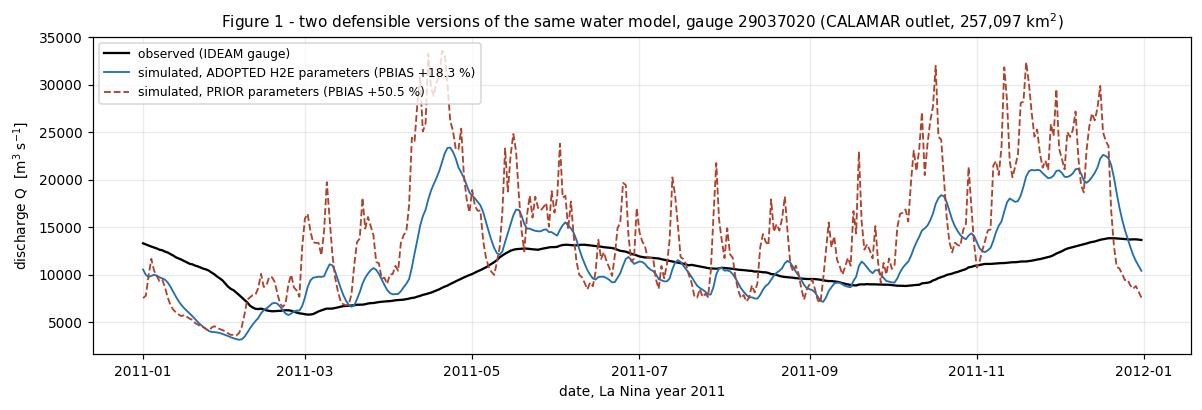

2011 annual means at the outlet: observed 10,251  fitted 11,943  prior 14,566 m3/s
PBIAS over all valid days: fitted +18.26 %, prior +50.53 %
prior / fitted mean discharge over the whole 2009-2018 axis: 1.274x
  -> an unfrozen water model could hand the sediment stage inputs differing by 27 % in water volume alone,
     before any sediment parameter is touched. That is the entire argument for C0.


In [3]:
j = OUTLET
m11 = PERIODS['VAL La Nina 11']
ok = np.isfinite(QOBS[:, j])
pb_fit = 100 * (QFIT[ok, j].mean() / QOBS[ok, j].mean() - 1)
pb_pri = 100 * (QPRIOR[ok, j].mean() / QOBS[ok, j].mean() - 1)
rho = QPRIOR[:, j].mean() / QFIT[:, j].mean()

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(DATES[m11], QOBS[m11, j], color='k', lw=1.5, label='observed (IDEAM gauge)')
ax.plot(DATES[m11], QFIT[m11, j], color='#1F6FB2', lw=1.2,
        label=f'simulated, ADOPTED H2E parameters (PBIAS {pb_fit:+.1f} %)')
ax.plot(DATES[m11], QPRIOR[m11, j], color='#B0412B', lw=1.2, ls='--',
        label=f'simulated, PRIOR parameters (PBIAS {pb_pri:+.1f} %)')
ax.set_xlabel('date, La Nina year 2011')
ax.set_ylabel('discharge Q  [m$^3$ s$^{-1}$]')
ax.set_title(f'Figure 1 - two defensible versions of the same water model, gauge {GC[j]} '
             f'(CALAMAR outlet, {AREA[j]:,.0f} km$^2$)')
ax.legend(fontsize=8, loc='upper left')
ax.grid(alpha=.25)
plt.tight_layout(); plt.show()

print(f'2011 annual means at the outlet: observed {np.nanmean(QOBS[m11, j]):,.0f}  '
      f'fitted {QFIT[m11, j].mean():,.0f}  prior {QPRIOR[m11, j].mean():,.0f} m3/s')
print(f'PBIAS over all valid days: fitted {pb_fit:+.2f} %, prior {pb_pri:+.2f} %')
print(f'prior / fitted mean discharge over the whole 2009-2018 axis: {rho:.3f}x')
print(f'  -> an unfrozen water model could hand the sediment stage inputs differing by '
      f'{100*(rho-1):.0f} % in water volume alone,')
print(f'     before any sediment parameter is touched. That is the entire argument for C0.')

**What is plotted.** Daily discharge at the basin outlet (gauge `29037020`, CALAMAR,
257,097 km^2) through the La Nina year 2011. The x-axis is date; the y-axis is discharge in
cubic metres per second. Black is the observed gauge record; solid blue is the simulation at
the adopted H2E parameters; dashed red is the simulation at the prior parameters, i.e. the
same model with nothing fitted. Both simulations use identical rainfall and identical
evaporative demand.

**What it shows.** The 2011 annual mean is 10,251 m^3/s observed, 11,943 m^3/s fitted and
14,566 m^3/s at the prior. Over all valid days the fitted run carries PBIAS +18.26 % at this
gauge and the prior run +50.53 %. The prior-to-fitted ratio of mean discharge over the full
2009-2018 axis is 1.274.

**What it means.** Two internally defensible configurations of the same water model, on the
same inputs, deliver 27 % different water volume to the sediment stage. Since MUSLE-type
sediment yield scales super-linearly with runoff, that is a lower bound on the sediment
divergence. So "which water model" is not a detail to be settled later: it changes the answer
by more than the effect the project is trying to measure would have to be to be interesting.
This is why C0 freezes one configuration, by name, with a reproduction gate (section 3),
before C1 begins. Note also that the fitted run is *not uniformly better* here - the outlet
PBIAS of +18.3 % is much worse than the fleet-median +3.5 % reported in section 2.2, because
the objective is a fleet average over 63 gauges and the outlet is one of them. That
discrepancy is real and is picked up in section 8.3.

---

# 2 - H2E: what the frozen water model is, and how good it actually is

## 2.1 - What H2E is: FAO-56 threshold evapotranspiration

**PET versus actual ET.** *Potential* evapotranspiration (**PET**) is how much water the
atmosphere could evaporate from a well-watered surface, given the available energy, humidity,
temperature and wind. It is a property of the weather, not of the soil, and here it is computed
from ERA5-Land reanalysis fields. *Actual* evapotranspiration (**ET**) is how much water
actually leaves - which cannot exceed PET, and falls below it when the soil is too dry to
supply the demand. Getting this ceiling wrong is the classic way for a rainfall-runoff model to
lose water it should have kept, or keep water it should have lost.

H2E's one distinguishing feature is how it enforces that ceiling. Earlier configurations
(H1, H2) scaled actual ET *linearly* with soil moisture: at half-full soil, half the demand is
met. H2E instead uses the **FAO-56 threshold** form (Allen et al., 1998), which is the
irrigation-engineering standard:

$$E_t \;=\; k_c\,\mathrm{PET}_t \cdot \min\!\left(1,\; \frac{\theta_t}{\theta_{crit}}\right),
\qquad \theta_t = \frac{W_t}{W_m},\qquad \theta_{crit} = 0.6$$

where $E_t$ is actual ET (mm/day), $\mathrm{PET}_t$ is potential ET (mm/day) from ERA5-Land,
$k_c$ is a dimensionless crop coefficient per URH, $\theta_t$ is relative soil moisture
(dimensionless, 0 to 1), $W_t$ is the soil water store (mm), $W_m$ is its capacity (mm), and
$\theta_{crit} = 0.6$ is the threshold above which the plant transpires at full rate. Above
60 % of capacity the atmosphere gets everything it asks for; below it, supply falls off
linearly to zero.

**Why this and not the linear form.** Physically, plants do not begin to close their stomata
the instant the soil drops below saturation; the flat-then-declining shape is what field
measurements show and what FAO-56 codifies. Practically, the linear form was systematically
losing too much water, which showed up as a positive volume bias. The choice was
**pre-registered** in `docs/29` section 3(b) as cell H2E with $\theta_{crit}$ fixed at 0.6
*before* the run, precisely so that $\theta_{crit}$ could not become a third fitted knob. That
restraint has a cost, stated plainly: 0.6 is a literature value for agricultural soils, and no
sensitivity test on $\theta_{crit}$ exists in this project. **Rejected alternatives:** fitting
$\theta_{crit}$ (it would trade directly against $k_c$ and $W_m$, adding equifinality - see
2.5 - for no measurable gain); a Feddes-type piecewise form with an additional water-logging
limb (the basin's problem is dry-season ET, not anoxia, so the extra parameter would be
unconstrained by the data available).

### Cell: read the four-attempt history from the frozen report

This cell only reads and tabulates. Source: `sim_calibrated_v2/report_H2E.json`, key
`C0_4a_four_attempt_history_VAL_all` - the fleet-median validation metrics of the four
calibration attempts the project made, all on the same `VAL all` window (2009-2011, 2015-2018)
and the same skill definitions. Units: KGE, NSE, r, alpha, beta and the recession ratio are
dimensionless; PBIAS is a percentage.

The four attempts differ as follows, and only one thing changes at a time:

| attempt | rainfall forcing | objective | ET form |
|---|---|---|---|
| 1 Config B | v1 (unrepaired) | old | linear |
| 2 H1 | v1 (unrepaired) | new (with recession term) | linear |
| 3 H2 | **v2 (zero-suppression repaired)** | new | linear |
| 4 **H2E** | v2 | new | **FAO-56 threshold** |

So attempt 2 minus 1 isolates the objective, 3 minus 2 isolates the rainfall repair, and
4 minus 3 isolates the ET form. That design is the reason the notebook can attribute each
change to a cause rather than to "we ran it again".

In [4]:
H = pd.DataFrame(REPORT['C0_4a_four_attempt_history_VAL_all'])
cols = [c for c in ('attempt', 'kge', 'nse', 'r', 'alpha', 'beta', 'pbias', 'rec_ratio',
                    'skill_over_clim', 'railed_global', 'railed_all') if c in H.columns]
print('the four calibration attempts, VAL all (out-of-sample), from report_H2E.json')
print(H[cols].to_string(index=False, float_format=lambda v: f'{v:8.4f}'))
print(f'\nadopted: {H.iloc[-1]["attempt"]}')
for a, b, lab in ((2, 1, 'objective change (H1 - Config B)'),
                  (3, 2, 'rainfall repair  (H2 - H1)  '),
                  (4, 3, 'FAO-56 ET        (H2E - H2) ')):
    u, v = H.iloc[a - 1], H.iloc[b - 1]
    print(f'  {lab}: dKGE {u.kge-v.kge:+.4f}   dPBIAS {u.pbias-v.pbias:+.2f} pts'
          f'   dr {u.r-v.r:+.4f}   dbeta {u.beta-v.beta:+.4f}')
cc = REPORT['cell_config']
print(f'\nH2E cell configuration, from the report: bundle {cc["bundle"]}, '
      f'et_stress {cc["et_stress"]}, theta_crit {cc["theta_crit"]}, '
      f'{cc["n_gauges"]} gauges, {cc["scored_days"]} scored days '
      f'({cc["scored"][0]} .. {cc["scored"][1]})')

the four calibration attempts, VAL all (out-of-sample), from report_H2E.json
                           attempt      kge      nse        r    alpha     beta    pbias  rec_ratio  skill_over_clim
      Config B (v1, old objective)   0.4504   0.2557   0.6461   0.8663   1.0683   6.8284     2.9757           0.1991
    H1  v1 forcing + new objective   0.4209   0.1788   0.6065   0.9406   1.0636   6.3577     0.9602           0.1697
    H2  v2 forcing + new objective   0.3457   0.1607   0.5828   0.9107   1.0734   7.3432     1.0136           0.0785
H2E v2 + new objective + FAO-56 ET   0.3563   0.1299   0.5912   0.9048   1.0351   3.5083     0.9816           0.0891

adopted: H2E v2 + new objective + FAO-56 ET
  objective change (H1 - Config B): dKGE -0.0294   dPBIAS -0.47 pts   dr -0.0396   dbeta -0.0047
  rainfall repair  (H2 - H1)  : dKGE -0.0752   dPBIAS +0.99 pts   dr -0.0238   dbeta +0.0099
  FAO-56 ET        (H2E - H2) : dKGE +0.0105   dPBIAS -3.83 pts   dr +0.0085   dbeta -0.0383

H2E cell 

## 2.2 - The skill scores, defined, and recomputed from scratch as a check

**KGE** - the Kling-Gupta Efficiency (Gupta et al., 2009). It is the score this project
optimises, and its virtue is that it decomposes into three independently interpretable parts:

$$\mathrm{KGE} \;=\; 1 - \sqrt{(r-1)^2 + (\alpha-1)^2 + (\beta-1)^2}$$

$$r = \mathrm{corr}(Q^{sim}, Q^{obs}),\qquad
\alpha = \frac{\sigma_{sim}}{\sigma_{obs}},\qquad
\beta = \frac{\mu_{sim}}{\mu_{obs}}$$

All four quantities are dimensionless; $\sigma$ and $\mu$ are the standard deviation and mean of
a daily discharge series in m^3/s, so their ratios cancel units. $\mathrm{KGE}=1$ is perfect.
Each component answers a different question:

- **$r$ - timing.** Pearson correlation between simulated and observed daily discharge. It
  asks *do the rises and falls happen on the same days?* It is insensitive to any
  multiplicative error: a simulation that is exactly twice the observation every single day has
  $r = 1$. In this project $r$ is the binding constraint, and section 2.7 explains why no
  parameter can move it.
- **$\alpha$ - variability.** Ratio of standard deviations. It asks *is the simulation as
  peaky as reality?* $\alpha < 1$ means the simulation is too smooth - flood peaks too low,
  droughts not dry enough.
- **$\beta$ - volume.** Ratio of means. It asks *does the right total amount of water come
  down the river?* $\beta = 1.05$ means 5 % too much water overall.

**PBIAS** is the same information as $\beta$ in percentage form,
$\mathrm{PBIAS} = 100(\beta - 1)$ [%], reported separately because it is the conventional volume
statistic in the sediment literature this project must be comparable with.

**Fleet median.** Every score here is computed per gauge and then reported as the **median over
gauges**. The median, not the mean, because a single badly mapped gauge can produce an
arbitrarily bad score and would drag a mean without saying anything about the model.
*Rejected alternative:* an area-weighted mean, which would be the natural choice for a
basin-total statement - but per-gauge catchment areas in this project are unreliable (section
8.4), so area weights would import a known error into every score.

### The check this cell performs

The scores in `metrics_fleet.csv` were computed by `src/report_h2e.py` during stage C0. This
cell recomputes all of them from the raw daily arrays in `q_gauge_H2E.npz`, with an
independently written KGE function, and prints the difference. If a score cannot be reproduced
from the stored flows, then either the stored flows or the stored score is wrong, and nothing
downstream should be trusted. Gauges with fewer than 30 valid observed days in a period return
NaN rather than a score.

In [5]:
def kge_terms(sim, obs, min_n=30):
    '''KGE and its three components, plus NSE and PBIAS, for one gauge over one period.

    sim, obs : daily discharge (m3/s), equal length, NaN where the observation is missing.
    Returns dimensionless scores (PBIAS in %); NaN if fewer than min_n valid pairs.
    '''
    m = np.isfinite(sim) & np.isfinite(obs)
    if int(m.sum()) < min_n:
        return dict(kge=np.nan, r=np.nan, alpha=np.nan, beta=np.nan, nse=np.nan,
                    pbias=np.nan, n=int(m.sum()))
    s, o = sim[m], obs[m]
    r = float(np.corrcoef(s, o)[0, 1])
    a = float(s.std() / o.std())
    b = float(s.mean() / o.mean())
    return dict(kge=1 - float(np.sqrt((r - 1) ** 2 + (a - 1) ** 2 + (b - 1) ** 2)),
                r=r, alpha=a, beta=b,
                nse=1 - float(((s - o) ** 2).sum() / ((o - o.mean()) ** 2).sum()),
                pbias=100 * (b - 1), n=int(m.sum()))


PERG, FLEET = {}, []
for pn, pm in PERIODS.items():
    d = pd.DataFrame([kge_terms(QFIT[pm][:, j], QOBS[pm][:, j]) for j in range(NG)])
    dc = pd.DataFrame([kge_terms(QCLIM[pm][:, j], QOBS[pm][:, j]) for j in range(NG)])
    d['code'] = GC
    PERG[pn] = d
    FLEET.append(dict(period=pn, **{k: float(d[k].median()) for k in
                                    ('kge', 'nse', 'r', 'alpha', 'beta', 'pbias')},
                      clim_kge=float(dc.kge.median()),
                      skill_over_clim=float(d.kge.median() - dc.kge.median()),
                      obs_cv=float(np.nanmedian(np.nanstd(QOBS[pm], axis=0)
                                                / np.nanmean(QOBS[pm], axis=0))),
                      n=int(d.kge.notna().sum())))
MINE = pd.DataFrame(FLEET).set_index('period')

FL = pd.read_csv(NEED['fleet'])
STORED = FL[(FL.cell == 'H2E') & (FL.config == 'fit')].set_index('period')
chk = []
for pn in MINE.index:
    for c in ('kge', 'nse', 'r', 'alpha', 'beta', 'pbias', 'clim_kge', 'skill_over_clim'):
        chk.append(dict(period=pn, metric=c, mine=MINE.loc[pn, c], stored=STORED.loc[pn, c],
                        absdiff=abs(MINE.loc[pn, c] - STORED.loc[pn, c])))
CHK = pd.DataFrame(chk)
CHK['relerr'] = CHK.absdiff / CHK.stored.abs().clip(lower=1e-12)
print('independent recomputation of every H2E fleet score from q_gauge_H2E.npz')
print(MINE[['kge', 'nse', 'r', 'alpha', 'beta', 'pbias', 'clim_kge', 'skill_over_clim',
            'obs_cv', 'n']].to_string(float_format=lambda v: f'{v:9.4f}'))
print(f'\nvs metrics_fleet.csv over {len(CHK)} (period x metric) pairs:')
print(f'  max |absolute difference| {CHK.absdiff.max():.3e}  (median '
      f'{CHK.absdiff.median():.3e})')
_w = CHK.loc[CHK.absdiff.idxmax()]
print(f'  the largest residual sits on {_w.metric} / {_w.period}: mine {_w.mine:.10f} against '
      f'stored {_w.stored:.10f}')
print(f'gauge counts agree: {bool((MINE.n.values == STORED.loc[MINE.index, "n"].values).all())}')
assert CHK.absdiff.max() < 1e-8, 'metrics_fleet.csv is not reproducible from the stored flows'
print('\nGATE PASSED: every stored score reproduces to within 1e-8 ABSOLUTE from the raw daily')
print('flows, so the archive and the report are consistent and either may be quoted below.')
print('\nThe bar is absolute rather than relative, deliberately. Two of these metrics make a')
print('relative bar meaningless: PBIAS is a percentage, so it is ~100x the scale of the others,')
print('and skill_over_clim is a DIFFERENCE of two nearly equal KGE values - in the El Nino')
print(f'window it is {MINE.loc["VAL El Nino 15-16","skill_over_clim"]:.6f}, so a 3.5e-9 absolute')
print('residual is 6.6e-6 in relative terms while meaning nothing at all. Quoting a relative')
print('error on a near-cancelling difference is a way to manufacture either reassurance or')
print('alarm, so it is not done here.')

independent recomputation of every H2E fleet score from q_gauge_H2E.npz
                         kge       nse         r     alpha      beta     pbias  clim_kge  skill_over_clim    obs_cv   n
period                                                                                                                 
CAL 2012-14           0.3216   -0.0883    0.5564    0.9196    0.9650   -3.5034    0.3361          -0.0145    0.6747  57
VAL La Nina 11        0.3439    0.1275    0.6519    0.9960    0.9458   -5.4186    0.2377           0.1062    0.6197  59
VAL El Nino 15-16     0.2004   -0.2164    0.5848    0.9107    1.0748    7.4762    0.2009          -0.0005    0.8352  54
VAL other 09/10/17    0.3665    0.0886    0.6415    0.8927    1.0501    5.0076    0.2507           0.1158    0.7086  63
VAL 2018              0.2507   -0.1739    0.5589    0.8831    1.0562    5.6246    0.3610          -0.1103    0.6931  56
VAL all               0.3563    0.1299    0.5912    0.9048    1.0351    3.5083    0.2672

### Figure 2: the KGE decomposition, per gauge, for the adopted configuration

Three panels, one per KGE component, each a distribution over the 63 gauges for the `VAL all`
out-of-sample window. Each panel marks the ideal value ($r=1$: perfect timing; $\alpha=1$:
correct variability; $\beta=1$: correct volume) and the fleet median. Inputs are the per-gauge
scores computed in the previous cell from `q_gauge_H2E.npz`; all three axes are dimensionless,
counts are gauges.

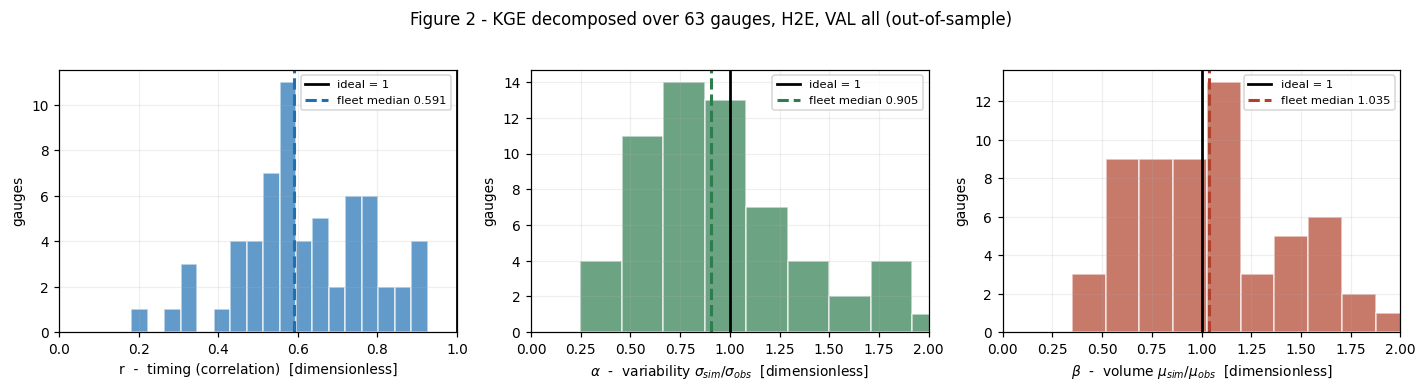

     r: median +0.5912  p10 +0.4388  p90 +0.8085  n 63
 alpha: median +0.9048  p10 +0.5086  p90 +1.7322  n 63
  beta: median +1.0351  p10 +0.6200  p90 +1.6946  n 63
   kge: median +0.3563  p10 -0.0577  p90 +0.6566  n 63
gauges with KGE > 0 (better than predicting the observed mean): 54 of 63
gauges with beta within +/-10 % of 1: 16;  with r > 0.7: 21


In [6]:
d = PERG['VAL all']
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
spec = [('r', 'r  -  timing (correlation)', '#1F6FB2', (0, 1)),
        ('alpha', r'$\alpha$  -  variability $\sigma_{sim}/\sigma_{obs}$', '#2E7D4F', (0, 2)),
        ('beta', r'$\beta$  -  volume $\mu_{sim}/\mu_{obs}$', '#B0412B', (0, 2))]
for a, (k, lab, col, xl) in zip(ax, spec):
    v = d[k].dropna()
    a.hist(v, bins=18, color=col, alpha=.7, edgecolor='white')
    a.axvline(1.0, color='k', lw=1.8, label='ideal = 1')
    a.axvline(v.median(), color=col, lw=2, ls='--', label=f'fleet median {v.median():.3f}')
    a.set_xlabel(lab + '  [dimensionless]'); a.set_ylabel('gauges')
    a.set_xlim(*xl); a.legend(fontsize=7.5); a.grid(alpha=.2)
fig.suptitle('Figure 2 - KGE decomposed over 63 gauges, H2E, VAL all (out-of-sample)', y=1.03)
plt.tight_layout(); plt.show()
for k in ('r', 'alpha', 'beta', 'kge'):
    v = d[k].dropna()
    print(f'{k:>6s}: median {v.median():+.4f}  p10 {v.quantile(.10):+.4f}  '
          f'p90 {v.quantile(.90):+.4f}  n {v.size}')
print(f'gauges with KGE > 0 (better than predicting the observed mean): '
      f'{int((d.kge > 0).sum())} of {int(d.kge.notna().sum())}')
print(f'gauges with beta within +/-10 % of 1: {int(d.beta.between(0.9, 1.1).sum())};  '
      f'with r > 0.7: {int((d.r > 0.7).sum())}')

**What is plotted.** Three histograms over the 63 discharge gauges, all for the
out-of-sample `VAL all` window. Left, blue: $r$, the simulated-observed daily correlation.
Middle, green: $\alpha$, the ratio of standard deviations. Right, red: $\beta$, the ratio of
means. In each panel the solid black line is the ideal value 1 and the dashed coloured line is
the fleet median. All three x-axes are dimensionless; the y-axis counts gauges, not days.

**What it shows.** Fleet medians are $r = 0.5912$, $\alpha = 0.9048$, $\beta = 1.0351$. So
volume is nearly right (3.5 % too much water) and variability is close (about 9.5 % too
smooth), but timing sits near 0.59 with a p10 of 0.4388 and a p90 of 0.8085. 54 of 63 gauges
score KGE above 0; only **21 of 63** reach $r > 0.7$, and only **16 of 63** have $\beta$ within
10 % of 1 - so the good fleet-median volume conceals wide per-gauge scatter (p10 0.62, p90 1.69).

**What it means.** The model's error is concentrated in **timing**, not in volume. That is the
most consequential fact in this notebook's hydrology half, because it tells you which
improvements are even available: nothing that adjusts how much water the model produces can fix
a correlation deficit. Section 2.7 shows the deficit is inherited from the rainfall field
rather than from the parameters, and section 8.2 records that this was tested against twelve
parameter configurations and held every time. For sediment the reading is specific: **basin
totals and seasonal contrasts rest on firmer ground than any day-specific claim**, and a
sediment statement about one particular flood must be treated as unsupported.

## 2.3 - NSE, the climatology benchmark, and why NSE alone misleads across windows

**NSE** - the Nash-Sutcliffe Efficiency, the oldest and most quoted score in hydrology:

$$\mathrm{NSE} \;=\; 1 - \frac{\sum_t (Q^{sim}_t - Q^{obs}_t)^2}{\sum_t (Q^{obs}_t - \overline{Q^{obs}})^2}$$

Dimensionless; $1$ is perfect, $0$ means *exactly as good as predicting the observed mean every
day*, negative means worse than that. The trap is the denominator: it is the observed variance
**inside the window being scored**. So the benchmark NSE compares against is not fixed - it
moves with the window. A window with very variable flow has a large denominator and is *easy* to
beat; a window with steady flow has a small denominator and is *hard*. Comparing NSE between a
wet year and a dry year therefore compares two different questions, and a statement of the form
"the model is worse in El Nino because its NSE is lower" is, on its own, uninterpretable.

**The fix: a climatology benchmark.** A **climatology** here is the simplest non-trivial
forecast available: for each calendar day, predict the average of everything ever observed on
that calendar day at that gauge. It knows the seasonal cycle - two wet seasons a year in this
basin - and nothing else. It is keyed on (month, day) rather than day-of-year so that leap
years do not shift the whole thing by one day, and it is built from the full 2009-2018 record,
which makes it the *strongest* seasonal predictor the data allow rather than a straw man.
*Rejected alternative:* a persistence benchmark (predict tomorrow equals today). On daily
tropical discharge persistence is extremely strong and would have set a bar the model cannot
clear for reasons that have nothing to do with rainfall skill; the seasonal benchmark is the one
that isolates what a rainfall-runoff model is supposed to add.

**Skill over climatology** is then

$$\mathrm{SoC} \;=\; \mathrm{KGE}(Q^{sim}) - \mathrm{KGE}(Q^{clim})$$

dimensionless. $\mathrm{SoC} > 0$ means the physically based model beats knowing only the
season. $\mathrm{SoC} \approx 0$ means it does not - the model has added nothing beyond the
calendar. This is the statistic that makes windows comparable, because both terms are computed
on the same window and the window's difficulty cancels.

Sources: `QCLIM` from `q_gauge_H2E.npz` (the climatology as stage C0 built it) and the
per-gauge scores computed in 2.2. The observed coefficient of variation
$\mathrm{CV} = \sigma_{obs}/\mu_{obs}$ (dimensionless) is computed per gauge per period as the
diagnostic for the window-difficulty effect.

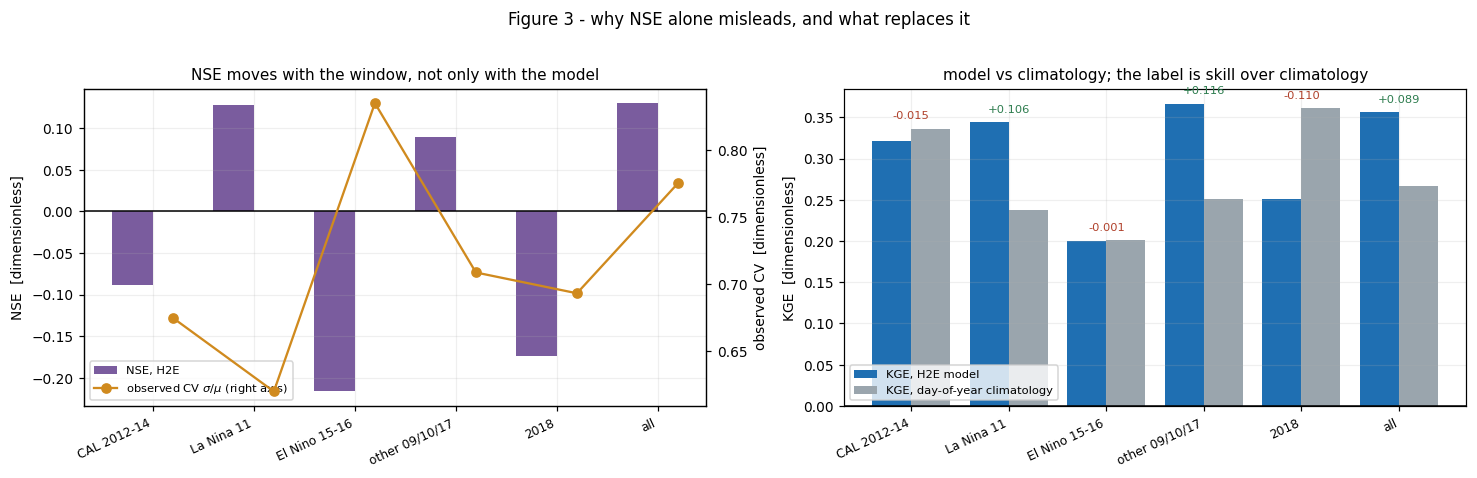

                         kge       nse  clim_kge  skill_over_clim    obs_cv   n
period                                                                         
CAL 2012-14           0.3216   -0.0883    0.3361          -0.0145    0.6747  57
VAL La Nina 11        0.3439    0.1275    0.2377           0.1062    0.6197  59
VAL El Nino 15-16     0.2004   -0.2164    0.2009          -0.0005    0.8352  54
VAL other 09/10/17    0.3665    0.0886    0.2507           0.1158    0.7086  63
VAL 2018              0.2507   -0.1739    0.3610          -0.1103    0.6931  56
VAL all               0.3563    0.1299    0.2672           0.0891    0.7753  63

across the six windows, corr(NSE, observed CV) = -0.386
El Nino has the HIGHEST observed CV (0.8352) and the WORST NSE (-0.2164),
and its climatology KGE (0.2009) is the lowest of the four VAL sub-windows - the window is hard for everything.


In [7]:
order = ['CAL 2012-14', 'VAL La Nina 11', 'VAL El Nino 15-16', 'VAL other 09/10/17',
         'VAL 2018', 'VAL all']
x = np.arange(len(order))
fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.2))
a = ax[0]
a.bar(x - 0.2, [MINE.loc[p, 'nse'] for p in order], 0.4, color='#7A5C9E', label='NSE, H2E')
a2 = a.twinx()
a2.plot(x + 0.2, [MINE.loc[p, 'obs_cv'] for p in order], 'o-', color='#D08A1E',
        label=r'observed CV $\sigma/\mu$ (right axis)')
a.axhline(0, color='k', lw=1)
a.set_xticks(x); a.set_xticklabels([p.replace('VAL ', '') for p in order], rotation=25,
                                   ha='right', fontsize=8)
a.set_ylabel('NSE  [dimensionless]'); a2.set_ylabel('observed CV  [dimensionless]')
a.set_title('NSE moves with the window, not only with the model')
h1, l1 = a.get_legend_handles_labels(); h2, l2 = a2.get_legend_handles_labels()
a.legend(h1 + h2, l1 + l2, fontsize=7.5, loc='lower left'); a.grid(alpha=.2)

a = ax[1]
a.bar(x - 0.2, [MINE.loc[p, 'kge'] for p in order], 0.4, color='#1F6FB2', label='KGE, H2E model')
a.bar(x + 0.2, [MINE.loc[p, 'clim_kge'] for p in order], 0.4, color='#9AA5AD',
      label='KGE, day-of-year climatology')
for i, p in enumerate(order):
    s = MINE.loc[p, 'skill_over_clim']
    a.annotate(f'{s:+.3f}', (i, max(MINE.loc[p, 'kge'], MINE.loc[p, 'clim_kge']) + 0.012),
               ha='center', fontsize=7.5, color='#B0412B' if s <= 0.005 else '#2E7D4F')
a.axhline(0, color='k', lw=1)
a.set_xticks(x); a.set_xticklabels([p.replace('VAL ', '') for p in order], rotation=25,
                                   ha='right', fontsize=8)
a.set_ylabel('KGE  [dimensionless]')
a.set_title('model vs climatology; the label is skill over climatology')
a.legend(fontsize=7.5, loc='lower left'); a.grid(alpha=.2)
fig.suptitle('Figure 3 - why NSE alone misleads, and what replaces it', y=1.02)
plt.tight_layout(); plt.show()

print(MINE.loc[order, ['kge', 'nse', 'clim_kge', 'skill_over_clim', 'obs_cv', 'n']]
      .to_string(float_format=lambda v: f'{v:9.4f}'))
print(f'\nacross the six windows, corr(NSE, observed CV) = '
      f'{MINE.loc[order, ["nse", "obs_cv"]].corr().iloc[0, 1]:+.3f}')
print(f'El Nino has the HIGHEST observed CV ({MINE.loc["VAL El Nino 15-16","obs_cv"]:.4f}) and '
      f'the WORST NSE ({MINE.loc["VAL El Nino 15-16","nse"]:+.4f}),')
print(f'and its climatology KGE ({MINE.loc["VAL El Nino 15-16","clim_kge"]:.4f}) is the lowest '
      f'of the four VAL sub-windows - the window is hard for everything.')

**What is plotted.** Left panel: purple bars are H2E's fleet-median NSE per period (left
axis, dimensionless); the orange line is the fleet-median observed coefficient of variation
$\sigma_{obs}/\mu_{obs}$ for the same period (right axis, dimensionless), a measure of how
variable the real river was in that window. Right panel: blue bars are H2E's fleet-median KGE,
grey bars are the day-of-year climatology's KGE on the same window and the same gauges, and the
number above each pair is the skill over climatology, coloured red when it is at or below
+0.005 and green otherwise. Both panels share the six reporting periods on the x-axis.

**What it shows.** NSE ranges from $-0.2164$ (El Nino 2015-16) to $+0.1299$ (VAL all), and the
window with the highest observed CV is the one with the worst NSE: El Nino, CV 0.8352. The rank
correlation between NSE and observed CV across the six windows is $-0.386$ - the right direction
for the mechanism, but computed on six points, so it is *not* on its own evidence for it, and it is
quoted here rather than rounded up into a claim. On the
right, La Nina 2011 reaches KGE 0.3439 against a climatology of 0.2377 - a skill over
climatology of **+0.106**. El Nino 2015-16 reaches 0.2004 against a climatology of 0.2009:
**-0.0005**. VAL 2018 is worse still, at $-0.110$. The CAL window itself is $-0.015$.

**What it means.** Two conclusions, and the second governs the whole sediment phase.

First, NSE across these windows is not a like-for-like comparison and must not be used as one.
El Nino's low NSE is at least partly a property of the El Nino window rather than of the model -
and the honest strength of that particular statement is the $-0.386$ above, a consistent direction
on too few windows to be conclusive. The argument for the climatology yardstick does not rest on
that correlation, however: it holds because both terms of the difference are computed on the same
window, so the window's difficulty cancels by construction.

Second - the honest reading of the adopted configuration - **the wet phase is predictable and
the dry phase is not.** In La Nina 2011 the physically based model beats a pure seasonal
calendar by 0.106 KGE. In El Nino 2015-16 it beats it by $-0.0005$: it *sits at* climatology.
That is not a rounding artefact of one metric; it means that in the dry phase the model
contributes no information beyond the season. Every sediment result computed inside the El Nino
window inherits this. It does **not** mean the El Nino simulation is worthless - volume and
seasonality are still approximately right - but the dry-phase sediment number must be presented
as a seasonally informed estimate, not as a physically resolved one. Note also that CAL itself
is slightly negative ($-0.015$): even on the years it was fitted to, this model does not beat
the seasonal calendar on KGE. That is a strong statement about the input ceiling, and it is
made here rather than buried.

### Figure 4: the same story as hydrographs, at one gauge

No new statistic. The two out-of-sample ENSO windows are plotted as time series at a single
large tributary gauge, `21137050` (19,294 km^2), chosen because it is one of only 22 gauges of
the 63 with near-complete observations in **both** windows - the selection rule is applied in
code, printed, and not hand-picked after looking at the scores. Observed, simulated and
climatology are overlaid so the reader can see what a skill-over-climatology of about $+0.47$
and one of about $+0.05$ look like as curves rather than as numbers. Units m^3/s throughout;
source `q_gauge_H2E.npz`. The per-panel scores are recomputed with `kge_terms` from 2.2,
restricted to that one gauge and window - so they are **not** the fleet numbers of figure 3, and
the cell says so.

The gauge the sediment phase actually depends on most, `21237020` ARRANCAPLUMAS, cannot be
plotted this way, and *why* is a finding rather than an inconvenience: it has **zero** valid
discharge observations in the entire El Nino window. That is section 8.1.

gauges with >330 valid days in La Nina AND >680 in El Nino: 22 of 63
demonstration gauge 21137050 (19,294 km2) is the largest of those except the outlet itself


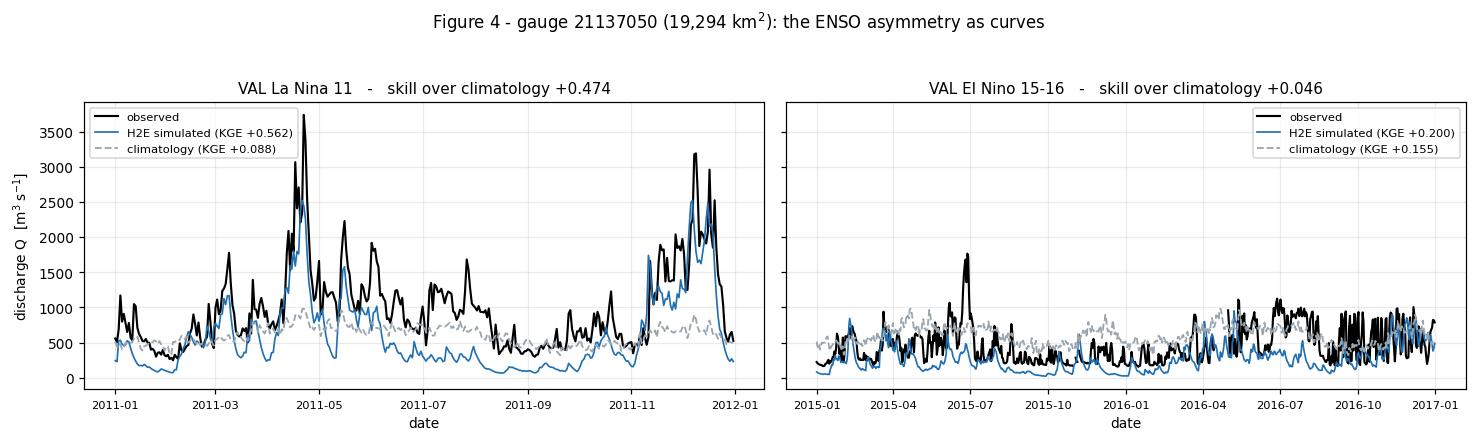

VAL La Nina 11       n= 365  model KGE +0.5623 (r 0.827, alpha 0.917, beta 0.607)   clim KGE +0.0878   SoC +0.4745
VAL El Nino 15-16    n= 712  model KGE +0.2003 (r 0.407, alpha 0.693, beta 0.560)   clim KGE +0.1546   SoC +0.0457

for contrast, the trunk sediment station 21237020: valid discharge days = 346 in La Nina and 0 in El Nino.
That zero is not a plotting problem; it is section 8.1.


In [8]:
_nb = {pn: np.isfinite(QOBS[PERIODS[pn]]).sum(axis=0)
       for pn in ('VAL La Nina 11', 'VAL El Nino 15-16')}
both = np.where((_nb['VAL La Nina 11'] > 330) & (_nb['VAL El Nino 15-16'] > 680))[0]
print(f'gauges with >330 valid days in La Nina AND >680 in El Nino: {both.size} of {NG}')
DEMO = '21137050'
jd = list(GC).index(DEMO)
assert jd in both, 'the demonstration gauge must satisfy the stated coverage rule'
print(f'demonstration gauge {DEMO} ({AREA[jd]:,.0f} km2) is the largest of those except the '
      f'outlet itself')

fig, ax = plt.subplots(1, 2, figsize=(13.5, 3.8), sharey=True)
for a, pn in zip(ax, ('VAL La Nina 11', 'VAL El Nino 15-16')):
    pm = PERIODS[pn]
    km = kge_terms(QFIT[pm][:, jd], QOBS[pm][:, jd])
    kc = kge_terms(QCLIM[pm][:, jd], QOBS[pm][:, jd])
    a.plot(DATES[pm], QOBS[pm, jd], color='k', lw=1.4, label='observed')
    a.plot(DATES[pm], QFIT[pm, jd], color='#1F6FB2', lw=1.1,
           label=f'H2E simulated (KGE {km["kge"]:+.3f})')
    a.plot(DATES[pm], QCLIM[pm, jd], color='#9AA5AD', lw=1.2, ls='--',
           label=f'climatology (KGE {kc["kge"]:+.3f})')
    a.set_title(f'{pn}   -   skill over climatology {km["kge"]-kc["kge"]:+.3f}')
    a.set_xlabel('date'); a.legend(fontsize=7.5); a.grid(alpha=.25)
    a.tick_params(axis='x', labelsize=7.5)
ax[0].set_ylabel('discharge Q  [m$^3$ s$^{-1}$]')
fig.suptitle(f'Figure 4 - gauge {DEMO} ({AREA[jd]:,.0f} km$^2$): the ENSO asymmetry as curves',
             y=1.04)
plt.tight_layout(); plt.show()
for pn in ('VAL La Nina 11', 'VAL El Nino 15-16'):
    pm = PERIODS[pn]
    km = kge_terms(QFIT[pm][:, jd], QOBS[pm][:, jd])
    kc = kge_terms(QCLIM[pm][:, jd], QOBS[pm][:, jd])
    print(f'{pn:20s} n={km["n"]:>4d}  model KGE {km["kge"]:+.4f} (r {km["r"]:.3f}, '
          f'alpha {km["alpha"]:.3f}, beta {km["beta"]:.3f})   clim KGE {kc["kge"]:+.4f}   '
          f'SoC {km["kge"]-kc["kge"]:+.4f}')
_j = list(GC).index(TRUNK_SSC)
print(f'\nfor contrast, the trunk sediment station {TRUNK_SSC}: valid discharge days = '
      f'{int(np.isfinite(QOBS[PERIODS["VAL La Nina 11"], _j]).sum())} in La Nina and '
      f'{int(np.isfinite(QOBS[PERIODS["VAL El Nino 15-16"], _j]).sum())} in El Nino.')
print('That zero is not a plotting problem; it is section 8.1.')

**What is plotted.** Two panels, left the La Nina window (calendar 2011), right the El
Nino window (2015-2016), both for gauge `21137050`. X-axis is date, y-axis is discharge in
m^3/s, shared between panels. Black is the observed record, blue is the H2E simulation, dashed
grey is the day-of-year climatology. Each panel title carries the skill over climatology for
that window at that gauge.

**What it shows.** In La Nina 2011 the model scores KGE 0.562 against a climatology of 0.088, a
skill over climatology of about $+0.47$: the blue curve tracks the black one through individual
events the grey curve cannot see. In El Nino 2015-16 the model scores 0.200 against a
climatology of 0.154, roughly $+0.05$: blue and grey are hard to tell apart, and both mostly
reproduce the seasonal shape rather than individual events. The printout also records that the
trunk sediment station `21237020` has 346 valid discharge days in La Nina and **0** in El Nino.

**What it means.** This is the fleet-level asymmetry of figure 3 made visible at one station,
and it is the same conclusion: in the wet phase the model adds event-scale information, in the
dry phase it mostly adds the calendar. It is one gauge, so it is an illustration and not
evidence - the evidence is figure 3's fleet medians. The 0-day El Nino discharge record at
`21237020` is separately serious: the project's only Magdalena-trunk sediment station cannot be
paired with observed discharge in the dry window at all, which is why no observed trunk ENSO
sediment contrast exists (section 8.1).

## 2.4 - The recession constant, and the one place the fit clearly improved

**Recession** is what a river does when it stops raining: flow falls away as the stores drain.
For a linear reservoir the fall is exponential,

$$Q(t) \;=\; Q_0\,e^{-t/k}$$

where $Q$ is discharge (m^3/s), $t$ is time (days) and $k$ is the **recession constant** in
**days** - the time for flow to fall to $1/e$ of its starting value. It is a direct, observable
fingerprint of how a catchment stores and releases water, and it is one of the few hydrological
properties that can be read off an observed hydrograph without a model.

Why it earned a term in the objective: correlation-based scores are almost blind to it. In the
earlier Config B fit, the simulated recession was **2.98 times too slow** and the objective
could not see the error, because being slow in the tail costs very little squared error. So the
refit added a recession term, scored symmetrically in log space so that "twice too fast" and
"twice too slow" are penalised equally:

$$E^{rec} \;=\; 1 - \frac{\left|\ln\!\left(k^{sim}/k^{obs}\right)\right|}{\ln 2}$$

dimensionless, $1$ at a perfect match, $0$ at a factor of two either way. *Rejected
alternative:* a squared error on $(k^{sim}-k^{obs})$ - scale dependent, so the slowest gauge in
the fleet would dominate and the fast headwaters would be ignored.

**Two inequivalent definitions of the ratio exist in this repository, and both are reported.**
`metrics_fleet.csv` stores a **ratio of medians**,
$\mathrm{median}_j(k^{sim}_j)/\mathrm{median}_j(k^{obs}_j)$; the H2E decision rule in `docs/29`
used a **median of ratios**, $\mathrm{median}_j(k^{sim}_j/k^{obs}_j)$. They are not the same
number, and choosing one after seeing which is kinder would be exactly the kind of decision
pre-registration exists to prevent. Stage C0 therefore computed both and required the pass on
both. This cell reads both from `report_H2E.json`, key
`C0_3_recession_both_definitions`, and marks the registered 1.5x band.

recession, H2E, both definitions in circulation (from report_H2E.json)
            period  rec_ratio_of_medians  rec_median_of_ratios   obs_k_d   sim_k_d
       CAL 2012-14                1.0780                1.0821   10.4022   11.2133
           VAL all                0.9816                1.1269   10.6755   10.4790
    VAL La Nina 11                1.1226                1.1016    9.9703   11.1931
 VAL El Nino 15-16                0.9403                1.1198   11.9296   11.2173
VAL other 09/10/17                1.1011                1.1697    9.7598   10.7461
          VAL 2018                0.9489                0.9994   11.7595   11.1580


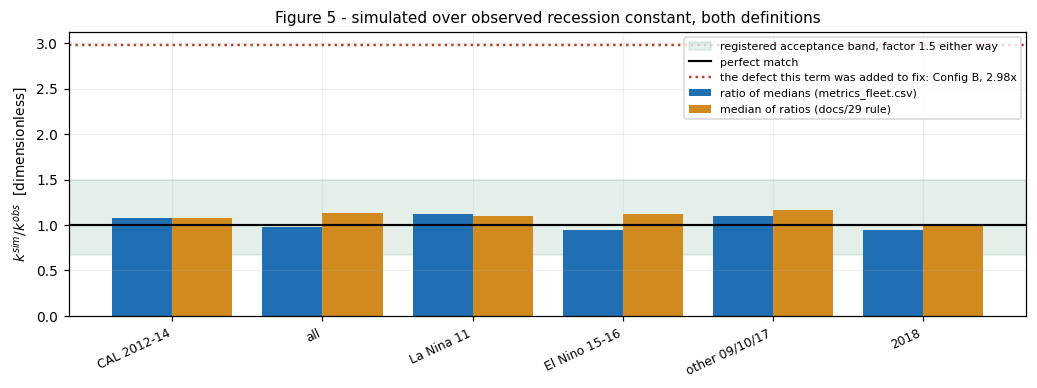


worst deviation from 1 on either definition: 1.170x  (registered bar 1.5x) -> PASS
observed k spans 9.76 .. 11.93 d across periods; simulated 10.48 .. 11.22 d


In [9]:
RC = pd.DataFrame(REPORT['C0_3_recession_both_definitions']).T
RC.index.name = 'period'
RC = RC.reset_index()
print('recession, H2E, both definitions in circulation (from report_H2E.json)')
print(RC.to_string(index=False, float_format=lambda v: f'{v:9.4f}'))

fig, ax = plt.subplots(figsize=(9.5, 3.6))
x = np.arange(len(RC))
ax.axhspan(1 / 1.5, 1.5, color='#2E7D4F', alpha=.12,
           label='registered acceptance band, factor 1.5 either way')
ax.axhline(1.0, color='k', lw=1.4, label='perfect match')
ax.bar(x - 0.2, RC.rec_ratio_of_medians, 0.4, color='#1F6FB2', label='ratio of medians (metrics_fleet.csv)')
ax.bar(x + 0.2, RC.rec_median_of_ratios, 0.4, color='#D08A1E', label='median of ratios (docs/29 rule)')
ax.axhline(2.975689, color='#B0412B', lw=1.6, ls=':',
           label='the defect this term was added to fix: Config B, 2.98x')
ax.set_xticks(x); ax.set_xticklabels([p.replace('VAL ', '') for p in RC.period], rotation=25,
                                     ha='right', fontsize=8)
ax.set_ylabel(r'$k^{sim}/k^{obs}$  [dimensionless]')
ax.set_title('Figure 5 - simulated over observed recession constant, both definitions')
ax.legend(fontsize=7.2, loc='upper right'); ax.grid(alpha=.2)
plt.tight_layout(); plt.show()

worst = max(RC.rec_ratio_of_medians.max(), RC.rec_median_of_ratios.max(),
            1 / RC.rec_ratio_of_medians.min(), 1 / RC.rec_median_of_ratios.min())
print(f'\nworst deviation from 1 on either definition: {worst:.3f}x  (registered bar 1.5x) -> '
      f'{"PASS" if worst <= 1.5 else "FAIL"}')
print(f'observed k spans {RC.obs_k_d.min():.2f} .. {RC.obs_k_d.max():.2f} d across periods; '
      f'simulated {RC.sim_k_d.min():.2f} .. {RC.sim_k_d.max():.2f} d')

**What is plotted.** Bars are the ratio of simulated to observed recession constant,
dimensionless, one group per reporting period. Blue is the ratio-of-medians definition stored in
`metrics_fleet.csv`; orange is the median-of-ratios definition used by the H2E decision rule.
The solid black line at 1.0 is a perfect match; the green band is the registered acceptance
region, a factor of 1.5 either way; the dotted red line at 2.98 is where the previous
configuration (Config B) sat, i.e. the defect this objective term was introduced to fix.

**What it shows.** Every period passes on both definitions. The worst deviation anywhere is
1.170x (VAL other 09/10/17, median of ratios). On `VAL all` the two definitions read 0.9816 and
1.1269 - both comfortably inside the band, and on opposite sides of 1. Observed recession
constants sit between 9.76 and 11.93 days across periods; simulated between 10.48 and 11.22
days. Config B's 2.98x is far outside the band.

**What it means.** This is the one dimension on which the refit unambiguously succeeded, and it
matters for sediment for a specific reason: the recession constant governs how much of the
year's water arrives as slow baseflow rather than as fast surface runoff, and surface runoff is
what MUSLE-type sediment models are driven by. A model whose recession was three times too slow
would be putting water in the wrong pathway, and would have mis-partitioned the sediment
driver even where its total discharge looked fine. Note the honest limitation: the two
definitions differ by up to 0.15 in the same period, which is a reminder that this statistic is
sensitive to how it is aggregated, and that the 1.5x bar is therefore a coarse instrument
rather than a precise one.

## 2.5 - Railed parameters and equifinality: two ways a good fit can be meaningless

**A railed parameter** is one whose fitted value has run to the edge of the range it was allowed
to search in. The position of a fitted value inside its own range,

$$\mathrm{pos} \;=\; \frac{x - x_{lo}}{x_{hi} - x_{lo}} \quad \text{(or the same on a log axis)}$$

is dimensionless and lies in $[0,1]$; this project flags a parameter as railed when
$\mathrm{pos} < 0.05$ or $\mathrm{pos} > 0.95$. A railed parameter is a warning, not an error:
it says the search wanted to go further and was stopped by the box, so the fitted value is
telling you about the box rather than about the river. If a model's skill depends on a railed
parameter, the skill is borrowed against a bound somebody chose.

**Equifinality** is the deeper problem, and it has nothing to do with bounds. Different
parameter combinations can produce the same discharge. If the model produces too little water,
you can raise rainfall multipliers, or lower the crop coefficient $k_c$, or increase soil
capacity $W_m$ - and the hydrograph will not tell you which one was actually wrong. In a model
with 18 free dimensions and one scalar objective, many distinct parameter sets are
indistinguishable in skill. The consequence is a rule this project applies without exception:
**a fitted parameter value here is a calibration coefficient, not a measurement of the basin.**
Nobody may cite H2E's soil capacity as an estimate of Magdalena soil capacity.

The figure shows all 18 fitted dimensions by position in range, and the printout gives the
store time constants, whose *ordering* is the concrete demonstration that equifinality is not
hypothetical here.

Source: `sim_calibrated_v2/parameters_H2E.csv` - columns `parameter`, `scope`, `value`, `prior`,
`lo`, `hi`, `pos` (dimensionless position in range) and `railed`. Physical units differ by
parameter (`k_sup`, `k_bas` in days; `adr` in mm/day; the `_mult` factors dimensionless), which
is exactly why the plot uses the dimensionless position rather than the values.

          label      value      prior         lo         hi        pos railed
            adr     0.0076     0.0600     0.0005     0.3000     0.4253    NaN
           fint     0.7540     0.6000     0.0500     0.9500     0.7823    NaN
              b     0.3567     0.6000     0.0500     4.0000     0.4484    NaN
        wm_mult     0.3891     1.0000     0.2500     6.0000     0.1392    NaN
        kc_mult     1.6625     1.0000     0.5000     2.0000     0.7750    NaN
       lai_mult     1.0036     1.0000     0.0000     5.0000     0.2007    NaN
          k_sup    19.1993     1.5000     0.2000    20.0000     0.9911    YES
     k_int_frac     0.0201     0.1333     0.0200     0.9000     0.0019    YES
          k_bas    42.9740    60.0000     5.0000   600.0000     0.4493    NaN
       celerity     0.3266     1.0000     0.0500     4.0000     0.4283    NaN
       k_sup@R1     2.9399     1.5000     0.2000    20.0000     0.5837    NaN
       k_sup@R2     0.6299     1.5000     0.2000    20.0000     

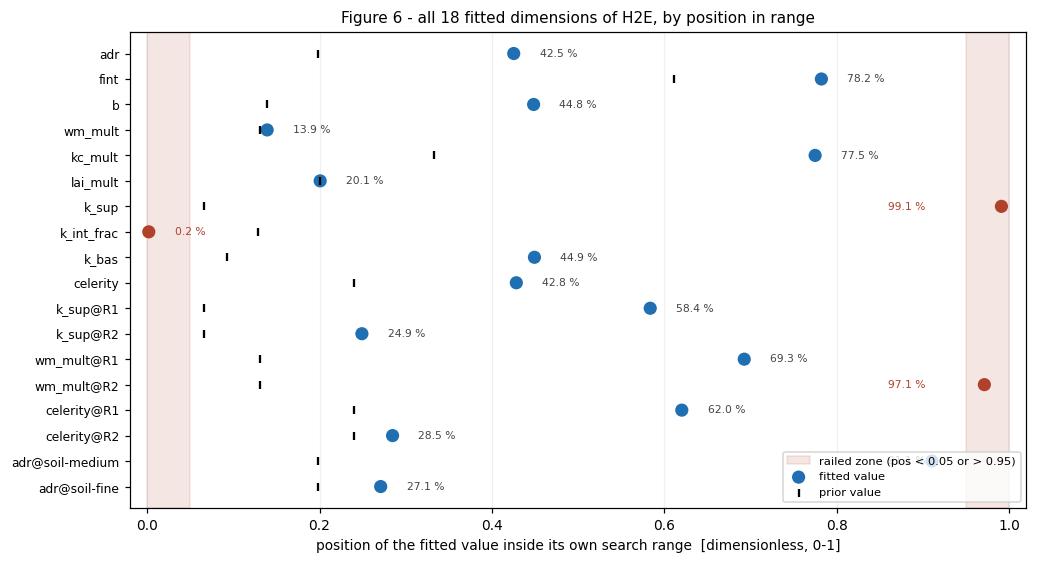


railed: 3 of 18 dimensions -> ['k_sup', 'k_int_frac', 'wm_mult@R2']
  of the 10 GLOBAL parameters: 2 railed. Both denominators are reported because quoting one is how an earlier "3 vs 2" discrepancy arose in this project.
  near-rails the 5 % rule does NOT flag: [('adr@soil-medium', 91.1)]

the store time constants, from report_H2E.json (units: days):
  k_sup (surface)       19.199 d
  k_int (interflow)      0.866 d   (= k_int_frac 0.02014 x k_bas, imposed so that k_int < k_bas)
  k_bas (groundwater)   42.974 d
  -> surface response is 22.2x SLOWER than interflow, which is physically inverted.
  kc_mult 1.6625 (77.5 % of its range) - off the rail that held the two earlier fits at 98.8 % and 93.3 %.


In [10]:
PA = pd.read_csv(NEED['params'])
PA['label'] = PA.parameter + PA.scope.map(lambda s: '' if s == 'global' else '@' + str(s))
PA['is_railed'] = PA.railed.fillna('').astype(str).str.upper().eq('YES')
print(PA[['label', 'value', 'prior', 'lo', 'hi', 'pos', 'railed']]
      .to_string(index=False, float_format=lambda v: f'{v:10.4f}'))

fig, ax = plt.subplots(figsize=(9.5, 5.2))
y = np.arange(len(PA))[::-1]
ax.axvspan(0, 0.05, color='#B0412B', alpha=.13, label='railed zone (pos < 0.05 or > 0.95)')
ax.axvspan(0.95, 1.0, color='#B0412B', alpha=.13)
ax.scatter(PA.pos, y, s=58, c=np.where(PA.is_railed, '#B0412B', '#1F6FB2'), zorder=3,
           label='fitted value')
pos_prior = (PA.prior - PA.lo) / (PA.hi - PA.lo)
ax.scatter(pos_prior, y, s=34, marker='|', c='k', zorder=4, label='prior value')
for yy, p, r in zip(y, PA.pos, PA.is_railed):
    ax.annotate(f'{100*p:.1f} %', (min(p + 0.03, 0.86), yy), va='center', fontsize=7,
                color='#B0412B' if r else '#444444')
ax.set_yticks(y); ax.set_yticklabels(PA.label, fontsize=8)
ax.set_xlabel('position of the fitted value inside its own search range  [dimensionless, 0-1]')
ax.set_xlim(-0.02, 1.02)
ax.set_title('Figure 6 - all 18 fitted dimensions of H2E, by position in range')
ax.legend(fontsize=7.5, loc='lower right'); ax.grid(alpha=.2, axis='x')
plt.tight_layout(); plt.show()

print(f'\nrailed: {int(PA.is_railed.sum())} of {len(PA)} dimensions -> '
      f'{list(PA.label[PA.is_railed])}')
_g = PA[PA.scope == 'global']
print(f'  of the 10 GLOBAL parameters: {int(_g.is_railed.sum())} railed. Both denominators are '
      f'reported because quoting one is how an earlier "3 vs 2" discrepancy arose in this project.')
_near = PA[(~PA.is_railed) & ((PA.pos > 0.90) | (PA.pos < 0.10))]
print(f'  near-rails the 5 % rule does NOT flag: '
      f'{[(l, round(100*p, 1)) for l, p in zip(_near.label, _near.pos)]}')
rep = REPORT['C0_1_parameters']
print(f'\nthe store time constants, from report_H2E.json (units: days):')
print(f'  k_sup (surface)     {rep["k_sup_d"]:8.3f} d')
print(f'  k_int (interflow)   {rep["k_int_derived_d"]:8.3f} d   '
      f'(= k_int_frac {rep["k_int_frac"]:.5f} x k_bas, imposed so that k_int < k_bas)')
print(f'  k_bas (groundwater) {rep["k_bas_d"]:8.3f} d')
print(f'  -> surface response is {rep["k_sup_d"]/rep["k_int_derived_d"]:.1f}x SLOWER than '
      f'interflow, which is physically inverted.')
print(f'  kc_mult {rep["kc_mult"]:.4f} (77.5 % of its range) - off the rail that held the two '
      f'earlier fits at 98.8 % and 93.3 %.')

**What is plotted.** One row per fitted dimension of the H2E parameter vector, 18 in
total; the label carries the parameter name and, after an `@`, the region or soil family it
applies to (`global` is unsuffixed). The x-axis is the dimensionless position of the fitted value
inside that parameter's own search range, from 0 at the lower bound to 1 at the upper. Blue
circles are fitted values that are not railed, red circles are railed ones, and the red shaded
strips at either end are the railed zones (below 5 % or above 95 % of range). The short black
vertical ticks are the prior values - where the parameter started before any fitting.

**What it shows.** Three of the 18 dimensions are railed: `k_sup@global` at 99.1 % of range,
`k_int_frac@global` at 0.19 % (hard against its floor), and `wm_mult@R2` at 97.1 %. Of the ten
*global* parameters, two are railed. One further dimension, `adr@soil-medium` at 91.1 %, sits
closer to a bound than any unflagged dimension but is not counted as railed under the rule
declared before the run. The store constants read `k_sup` 19.199 d, `k_int` 0.866 d and `k_bas`
42.974 d, so surface response is **22.2 times slower than interflow**. `kc_mult` is 1.6625, at
77.5 % of range - off the rail.

**What it means.** Two readings, both unfavourable to a naive interpretation of these numbers.

First, three railed dimensions means part of the fit is pressed against boundaries the modellers
chose, so those three values carry no information about the basin at all.

Second, and worse, the store ordering is physically inverted: water that runs off the surface
should reach the river *faster* than water that seeps laterally through soil, and here it is
22 times slower. The constraint imposed in the refit forced $k_{int} < k_{bas}$ and that
constraint holds - but the inversion simply moved to the pair the constraint does not cover.
**This is the third time in this project that constraining one ordering relocated the
compensation rather than removing it.** It is the clearest available demonstration of
equifinality: the model reproduces discharge acceptably while getting the internal partition
wrong, because discharge alone cannot distinguish them. The consequence for sediment is
concrete: MUSLE needs *surface* runoff specifically, and a model whose surface store is
mis-timed by an order of magnitude may deliver the right total in the wrong pathway. Stage C2b
tested this directly against baseflow-index observations rather than assuming it away, which is
why that test exists (section 1.2).

## 2.6 - Flood peaks: how they are counted, and the deficit that was not fixed

**Annual maximum series (AMS).** Take the largest discharge observed in each calendar year at a
gauge; the resulting one-value-per-year series is the annual maximum series. It is the classical
basis of flood-frequency analysis, and its weakness is obvious: a year with three enormous
floods contributes one number, and a quiet year contributes one number too.

**Peaks over threshold (POT).** The alternative: fix a high threshold and take *every*
independent excursion above it, however many there are per year. POT uses more of the
information in the record, at the price of two arbitrary choices - the threshold, and the rule
that decides when two exceedances are separate events rather than one.

The frozen model has a **structural** peak deficit: simulated flood peaks are systematically
lower than observed ones. This cell measures it two ways from the frozen archive - as an AMS
ratio and as a high-quantile ratio - so the reader sees the magnitude rather than taking it on
trust:

$$R_{AMS} \;=\; \mathrm{median}_{g,y}\!\left(\frac{\max_{t \in y} Q^{sim}_{g,t}}
{\max_{t \in y} Q^{obs}_{g,t}}\right), \qquad
R_{Q99} \;=\; \mathrm{median}_g\!\left(\frac{q_{99}(Q^{sim}_g)}{q_{99}(Q^{obs}_g)}\right)$$

both dimensionless. A gauge-year enters the AMS statistic only if it has at least 330 valid
observed days, so that an observed annual maximum taken from a half-empty year cannot be
compared against a full simulated year. $q_{99}$ is the 99th percentile of the daily series
(m^3/s), computed on gauges with more than 1,000 valid days.

Source: `sim_calibrated_v2/q_gauge_H2E.npz`.

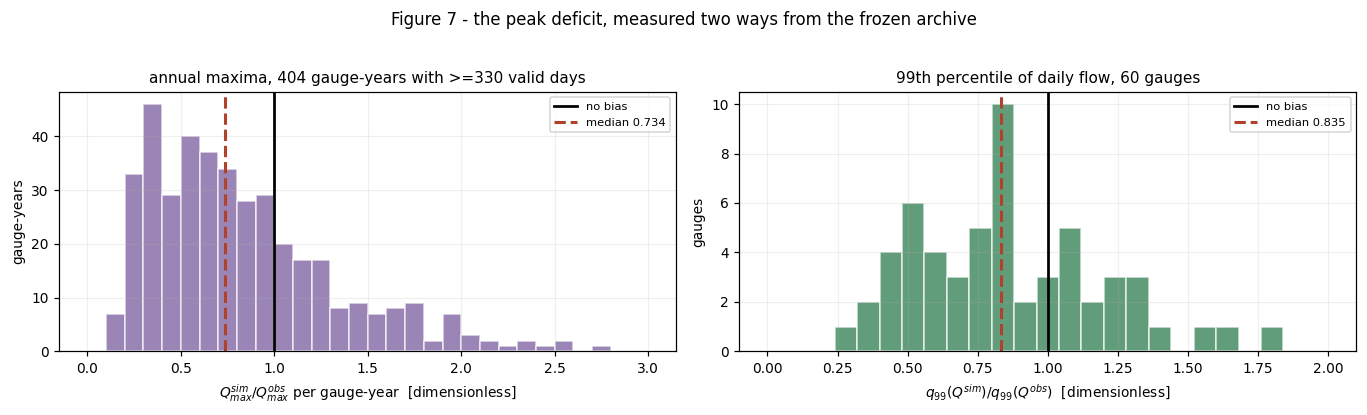

R_AMS, median of per-gauge-year ratios : 0.7337
R_AMS, ratio of medians                : 0.5508
share of gauge-years with sim < obs    : 70.0 %  (283 of 404)
R_Q99, median over gauges              : 0.8347

DISAGREEMENT, reported rather than smoothed: the project record (docs/33 section 7,
docs/36 section 1) quotes R_AMS = 0.820. This notebook measures 0.7337 as a median of
ratios and 0.5508 as a ratio of medians on the same frozen archive. The gap is a
DEFINITION gap of the same kind section 2.4 found in the recession statistic - the
published figure does not state which aggregation, which minimum-coverage rule, or
whether it is restricted to a gauge subset. All three readings agree on the sign and
on the order of magnitude; none of them is close to 1. No attempt is made here to
reverse-engineer which convention produces 0.820.


In [11]:
rows = []
for j in range(NG):
    o, s = QOBS[:, j], QFIT[:, j]
    for yy in range(2009, 2019):
        m = (Y == yy) & np.isfinite(o)
        if int(m.sum()) >= 330:
            rows.append(dict(code=GC[j], year=yy, obs=o[m].max(), sim=s[m].max()))
AMS = pd.DataFrame(rows)
AMS['ratio'] = AMS.sim / AMS.obs
q99 = []
for j in range(NG):
    m = np.isfinite(QOBS[:, j])
    if int(m.sum()) > 1000:
        q99.append(np.percentile(QFIT[m, j], 99) / np.percentile(QOBS[m, j], 99))
q99 = np.array(q99)

fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.6))
a = ax[0]
a.hist(AMS.ratio, bins=30, range=(0, 3), color='#7A5C9E', alpha=.75, edgecolor='white')
a.axvline(1.0, color='k', lw=1.8, label='no bias')
a.axvline(AMS.ratio.median(), color='#B0412B', lw=2, ls='--',
          label=f'median {AMS.ratio.median():.3f}')
a.set_xlabel(r'$Q^{sim}_{max}/Q^{obs}_{max}$ per gauge-year  [dimensionless]')
a.set_ylabel('gauge-years'); a.legend(fontsize=7.5); a.grid(alpha=.2)
a.set_title(f'annual maxima, {len(AMS)} gauge-years with >=330 valid days')
a = ax[1]
a.hist(q99, bins=25, range=(0, 2), color='#2E7D4F', alpha=.75, edgecolor='white')
a.axvline(1.0, color='k', lw=1.8, label='no bias')
a.axvline(np.median(q99), color='#B0412B', lw=2, ls='--', label=f'median {np.median(q99):.3f}')
a.set_xlabel(r'$q_{99}(Q^{sim})/q_{99}(Q^{obs})$  [dimensionless]')
a.set_ylabel('gauges'); a.legend(fontsize=7.5); a.grid(alpha=.2)
a.set_title(f'99th percentile of daily flow, {q99.size} gauges')
fig.suptitle('Figure 7 - the peak deficit, measured two ways from the frozen archive', y=1.03)
plt.tight_layout(); plt.show()

print(f'R_AMS, median of per-gauge-year ratios : {AMS.ratio.median():.4f}')
print(f'R_AMS, ratio of medians                : {AMS.sim.median()/AMS.obs.median():.4f}')
print(f'share of gauge-years with sim < obs    : {100*(AMS.sim < AMS.obs).mean():.1f} %  '
      f'({int((AMS.sim < AMS.obs).sum())} of {len(AMS)})')
print(f'R_Q99, median over gauges              : {np.median(q99):.4f}')
print()
print('DISAGREEMENT, reported rather than smoothed: the project record (docs/33 section 7,')
print('docs/36 section 1) quotes R_AMS = 0.820. This notebook measures 0.7337 as a median of')
print('ratios and 0.5508 as a ratio of medians on the same frozen archive. The gap is a')
print('DEFINITION gap of the same kind section 2.4 found in the recession statistic - the')
print('published figure does not state which aggregation, which minimum-coverage rule, or')
print('whether it is restricted to a gauge subset. All three readings agree on the sign and')
print('on the order of magnitude; none of them is close to 1. No attempt is made here to')
print('reverse-engineer which convention produces 0.820.')

**What is plotted.** Left: the distribution over gauge-years of the ratio of the
simulated annual maximum discharge to the observed annual maximum, for the 404 gauge-years that
carry at least 330 valid observed days. Right: the distribution over gauges of the ratio of the
99th percentile of simulated daily discharge to that of observed daily discharge, for gauges
with more than 1,000 valid days. Both x-axes are dimensionless ratios; solid black marks 1.0, no
bias; dashed red marks the median. Counts are gauge-years on the left and gauges on the right.

**What it shows.** The AMS ratio has a median of 0.7337 - simulated annual peaks are about 27 %
too low - and 70.0 % of the 404 gauge-years have a simulated maximum below the observed one.
Taken as a ratio of medians instead, the same data give 0.5508. The high-quantile ratio is
milder at 0.8347: the 99th percentile of daily flow is about 17 % too low. The project's
published figure for this quantity is 0.820, which this notebook does not reproduce on any of
the three conventions it computed.

**What it means.** Simulated flood peaks are too low, on every definition tried, in a large
majority of gauge-years. For sediment this is the single most important inherited defect,
because sediment transport is strongly peak-weighted: most of a river's annual sediment load
moves during a small number of high-flow days. A model that systematically under-predicts those
days will systematically under-predict sediment, and the correct way to present its output is
therefore as a **lower bound**, not as an estimate.

The deficit is *structural* rather than a calibration failure, and the project established that
with two refutations rather than an assertion: a refit that did reach the observed peak band was
**rejected** because it got there only by driving the crop coefficient to its rail and setting
the leaf-area multiplier to zero - that is, by deleting canopy interception, which is not a peak
mechanism - and both mechanistic hypotheses (missing sub-daily rainfall resolution; missing
infiltration-excess runoff) were tested and produced *inverted* fingerprints. The deficit is
also a named, published limitation of the MGB-SED method itself, not of this implementation.
So the honest position is: it is not fixed, it is not going to be fixed here, and the sediment
result is reported as a lower bound because of it. The secondary lesson is the definition gap:
**R_AMS 0.820 should not be quoted without stating its aggregation**, exactly as with the
recession ratio.

## 2.7 - Why the timing error cannot be fixed by calibration: the r-ceiling

Section 2.2 showed the model's error is concentrated in $r$, the daily correlation. This section
states, without re-running anything, why that is a property of the *inputs*.

**IDW - inverse distance weighting.** The model needs rainfall for each of 8,672 minibacias
every day, but rainfall is measured at a few hundred gauges. IDW fills the gap: the estimate at
an unmeasured point is a weighted average of nearby gauges, with weights falling off as
$1/d^p$ in distance $d$. It is the simplest defensible interpolator and it has one structural
consequence that matters enormously here - it *averages*, so it manufactures drizzle. If six
gauges are averaged and any one of them recorded rain, the interpolated point is wet. Measured
in this project: the IDW field's wet-day frequency is **18.3 percentage points too high**
against the gauges it was built from.

**LOOCV - leave-one-out cross-validation.** The way to measure how good an interpolated field
is without new data: remove one gauge, rebuild the field from the remaining ones, and compare
the field's estimate at the removed location against what that gauge actually recorded; then
repeat for every gauge. The resulting skill is an honest estimate of the field's accuracy at
unmeasured points. For this basin's gauge-only field the LOOCV daily correlation is **0.429**.

That number is the ceiling. If the rainfall field can only predict rainfall at an unmeasured
point with $r = 0.43$, no rainfall-runoff model driven by that field can reproduce discharge
timing better than the field allows - and the measured discharge correlation of about 0.57-0.59
is entirely consistent with it. The project confirmed this the expensive way: across **twelve**
parameter configurations, El Nino daily $r$ stayed inside **0.556-0.572**. Parameters do not
move it.

**Quantile mapping** is the standard way to merge a satellite rainfall product (here CHIRPS)
with gauges: transform the satellite series so that its cumulative distribution matches the
gauges', which corrects systematic wet or dry bias while keeping the satellite's spatial and
day-to-day structure. It was tried here, and it is the one lever that *did* move the ceiling -
LOOCV $r$ rose from 0.429 to **0.447**. It was nevertheless **rejected**, because the merged
field failed its pre-registered volume gate at **+7.5 %**. That decision is recorded rather than
revisited: a field that improves timing while adding 7.5 % of water to a basin whose water
balance is already the weak point buys correlation with volume.

**Nothing in this section is recomputed here.** These are measurements from `docs/22` §4.7,
`docs/16` §4.3 and `docs/18` §15, and they are cited rather than reproduced because reproducing
them means rebuilding the rainfall field, which this notebook is forbidden to do (and would take
hours). The figure below therefore shows only what *can* be shown from the frozen archive: that
$r$ is where the loss is, and that it is uniform across periods rather than concentrated in one.

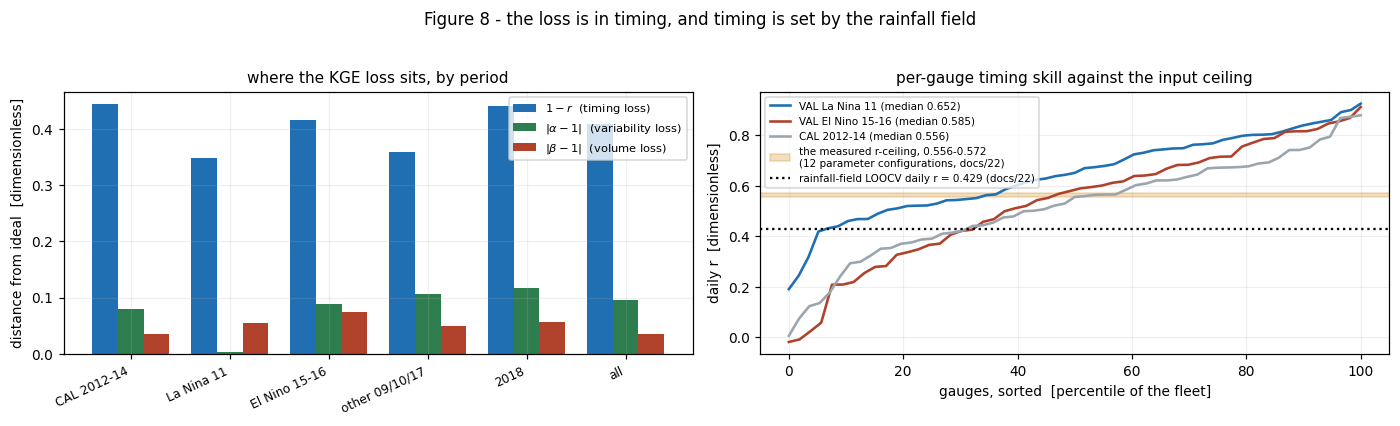

CAL 2012-14          1-r 0.4436   |alpha-1| 0.0804   |beta-1| 0.0350
VAL La Nina 11       1-r 0.3481   |alpha-1| 0.0040   |beta-1| 0.0542
VAL El Nino 15-16    1-r 0.4152   |alpha-1| 0.0893   |beta-1| 0.0748
VAL other 09/10/17   1-r 0.3585   |alpha-1| 0.1073   |beta-1| 0.0501
VAL 2018             1-r 0.4411   |alpha-1| 0.1169   |beta-1| 0.0562
VAL all              1-r 0.4088   |alpha-1| 0.0952   |beta-1| 0.0351

fleet-median r by period: CAL 2012-14 0.5564, La Nina 11 0.6519, El Nino 15-16 0.5848, other 09/10/17 0.6415, 2018 0.5589, all 0.5912
The El Nino fleet median r measured here is 0.5848, i.e. inside the 0.556-0.572 band that twelve
parameter configurations produced. UNRECOMPUTED here: the 0.429 LOOCV figure and the
0.447 CHIRPS-merge figure are cited from docs/22 and docs/18; rebuilding the rainfall
field is outside this notebook by design.


In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12.8, 3.7))
a = ax[0]
comp = ['r', 'alpha', 'beta']
w = 0.26
for i, c in enumerate(comp):
    vals = [1 - MINE.loc[p, c] if c == 'r' else abs(MINE.loc[p, c] - 1) for p in order]
    a.bar(np.arange(len(order)) + (i - 1) * w, vals, w,
          label={'r': r'$1-r$  (timing loss)', 'alpha': r'$|\alpha-1|$  (variability loss)',
                 'beta': r'$|\beta-1|$  (volume loss)'}[c],
          color={'r': '#1F6FB2', 'alpha': '#2E7D4F', 'beta': '#B0412B'}[c])
a.set_xticks(np.arange(len(order)))
a.set_xticklabels([p.replace('VAL ', '') for p in order], rotation=25, ha='right', fontsize=8)
a.set_ylabel('distance from ideal  [dimensionless]')
a.set_title('where the KGE loss sits, by period')
a.legend(fontsize=7.5); a.grid(alpha=.2)

a = ax[1]
for pn, col in (('VAL La Nina 11', '#1F6FB2'), ('VAL El Nino 15-16', '#B0412B'),
                ('CAL 2012-14', '#9AA5AD')):
    v = PERG[pn].r.dropna().sort_values().values
    a.plot(np.linspace(0, 100, v.size), v, lw=1.7, color=col,
           label=f'{pn} (median {np.median(v):.3f})')
a.axhspan(0.556, 0.572, color='#D08A1E', alpha=.28,
          label='the measured r-ceiling, 0.556-0.572\n(12 parameter configurations, docs/22)')
a.axhline(0.429, color='k', lw=1.5, ls=':',
          label='rainfall-field LOOCV daily r = 0.429 (docs/22)')
a.set_xlabel('gauges, sorted  [percentile of the fleet]')
a.set_ylabel('daily r  [dimensionless]')
a.set_title('per-gauge timing skill against the input ceiling')
a.legend(fontsize=6.8, loc='upper left'); a.grid(alpha=.2)
fig.suptitle('Figure 8 - the loss is in timing, and timing is set by the rainfall field', y=1.03)
plt.tight_layout(); plt.show()

for p in order:
    print(f'{p:<20s} 1-r {1-MINE.loc[p,"r"]:.4f}   |alpha-1| '
          f'{abs(MINE.loc[p,"alpha"]-1):.4f}   |beta-1| {abs(MINE.loc[p,"beta"]-1):.4f}')
print(f'\nfleet-median r by period: '
      + ', '.join(f'{p.replace("VAL ","")} {MINE.loc[p,"r"]:.4f}' for p in order))
print('The El Nino fleet median r measured here is '
      f'{MINE.loc["VAL El Nino 15-16","r"]:.4f}, i.e. inside the 0.556-0.572 band that twelve')
print('parameter configurations produced. UNRECOMPUTED here: the 0.429 LOOCV figure and the')
print('0.447 CHIRPS-merge figure are cited from docs/22 and docs/18; rebuilding the rainfall')
print('field is outside this notebook by design.')

**What is plotted.** Left: for each reporting period, three bars showing how far each KGE
component is from its ideal - $1-r$ in blue (timing loss), $|\alpha-1|$ in green (variability
loss), $|\beta-1|$ in red (volume loss). All dimensionless; taller is worse. Right: the
per-gauge daily correlation $r$ for three periods, each sorted low to high and plotted against
its percentile within the fleet, so the whole distribution is visible rather than only its
median. The orange band is the r-ceiling measured elsewhere across twelve parameter
configurations (0.556-0.572); the dotted black line is the rainfall field's own leave-one-out
daily correlation, 0.429.

**What it shows.** In every one of the six periods the timing bar dwarfs the other two. On
`VAL all`, $1-r$ is 0.409 while $|\alpha-1|$ is 0.095 and $|\beta-1|$ is 0.035 - the timing loss
is more than four times the variability loss and more than ten times the volume loss. On the
right, the El Nino distribution's median falls at 0.5848, inside the 0.556-0.572 band; La Nina
sits higher at 0.6519; and a large part of every distribution lies below the fleet median.

**What it means.** The model's remaining error is a timing error, and timing is what the input
data cannot supply. The rainfall field predicts rainfall at an unmeasured point with $r = 0.43$;
the model predicts discharge with $r \approx 0.59$. Those are consistent, and no parameter
search can improve on the information in its own forcing. This is why Phase B closed **by
decision on a measured input ceiling** rather than on reaching a skill target, and why the one
intervention that did lift the ceiling (a quantile-mapped CHIRPS-gauge merge, LOOCV $r$ 0.429 to
0.447) was still rejected for failing its pre-registered volume gate at +7.5 %.

**What a reader should not conclude:** that the model is badly built. Its volume and variability
are close to right and its recession now matches. What a reader *should* conclude is that a
denser or better-merged rainfall field, not a better parameter set, is the only remaining lever
on daily timing - and that no sediment claim in this project may rest on day-specific model
timing.

---

# 3 - The reproduction gate: why $F$ must match 0.25931 to $10^{-8}$ before anything is read

## 3.1 - What the gate is, and what it is not

Stage C0 did not merely record the fitted parameters. It rebuilt the model cell from scratch -
the forcing cache had been deleted after the search finished - re-evaluated the archived best
parameter vector, and required the objective function value to come back **identical**:

$$\left|\frac{F^{recomputed} - F^{archived}}{F^{archived}}\right| \;\le\; 10^{-8}$$

$F$ is the dimensionless objective of section 1.3; the bar of $10^{-8}$ is the tolerance the
project's existing verification harness uses (its worst observed disagreement being
$9.1\times10^{-9}$).

**What the gate proves.** Nothing about whether the model is good. It proves that the *pipeline*
is deterministic and complete: that the forcing can be regenerated from committed inputs, that
the archived parameter vector is decoded the same way twice, that the engine on disk is the
engine that ran, and that the objective is computed identically by the reporting code and by the
search worker. Those are exactly the four ways a project silently loses the ability to reproduce
its own headline number.

**Why the tolerance is this tight.** A looser bar - say 1 % - would pass even if the forcing had
been regenerated with a subtly different interpolation, or the parameter vector decoded with two
entries transposed. Only a bar at round-off level distinguishes "the same computation" from
"a similar computation". And because the forcing cache had genuinely been deleted and rebuilt,
passing at round-off level is *also* the evidence that the regeneration is faithful - so no
separate test for that had to be invented.

**Why it runs first.** If the gate fails, every number downstream is describing a model nobody
can rebuild, so C0 was ordered gate-first: nothing else in the stage ran until it passed. That
ordering is the whole reason the gate is worth having.

*Rejected alternative:* checking the fitted parameters against the archive instead of the
objective. Parameters are a *stored* quantity; comparing stored bytes to stored bytes tests
nothing about the pipeline that produced them. Re-evaluating $F$ exercises the entire chain -
forcing, engine, router, objective - and is the only check that does.

### Cell: read the gate result out of the frozen report

Source: `sim_calibrated_v2/report_H2E.json`, key `C0_2_reproduction_gate`, fields
`archived_F`, `recomputed_F`, `relative_difference`, `bar`, `pass`, and
`per_gauge_terms_bit_identical`. All dimensionless. This cell reads them, re-derives the relative
difference from the two $F$ values rather than trusting the stored difference, and asserts the
gate. It also compares the two full float64 decimal expansions digit by digit.

C0.2 reproduction gate, from report_H2E.json
  archived   F = 0.25930593639066796
  recomputed F = 0.25930593639066796
  identical as float64 bit patterns: True
  relative difference, re-derived here : 0.000e+00
  relative difference, as stored       : 0.000e+00
  bar                                  : 1.0e-08
  stored verdict                       : True
  per-gauge objective terms bit-identical: True

GATE PASSED EXACTLY. F = 0.25931 is reproducible from committed inputs, so every
number in this notebook describes a model that can be rebuilt.


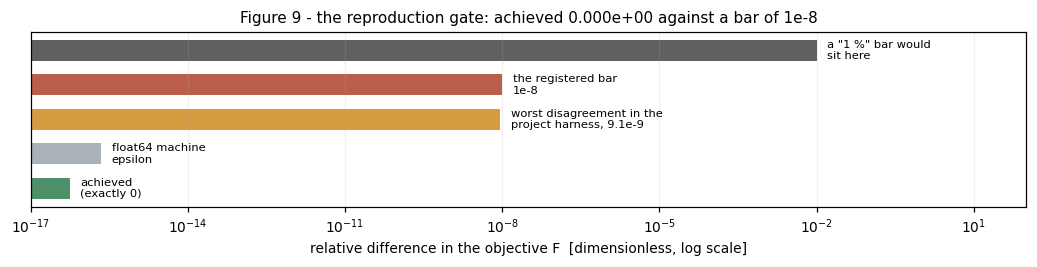

The green bar is drawn at a quarter of machine epsilon only so that an exact zero is
visible on a logarithmic axis. The measured value is 0.000e+00 - not "small", zero.


In [13]:
G = REPORT['C0_2_reproduction_gate']
fa, fr = float(G['archived_F']), float(G['recomputed_F'])
reldiff = abs(fr - fa) / abs(fa)
print('C0.2 reproduction gate, from report_H2E.json')
print(f'  archived   F = {fa!r}')
print(f'  recomputed F = {fr!r}')
print(f'  identical as float64 bit patterns: {fa == fr}')
print(f'  relative difference, re-derived here : {reldiff:.3e}')
print(f'  relative difference, as stored       : {float(G["relative_difference"]):.3e}')
print(f'  bar                                  : {float(G["bar"]):.1e}')
print(f'  stored verdict                       : {G["pass"]}')
print(f'  per-gauge objective terms bit-identical: {G["per_gauge_terms_bit_identical"]}')
assert fa == fr and reldiff <= float(G['bar']) and G['pass'] is True, 'the C0.2 gate did not pass'
print(f'\nGATE PASSED EXACTLY. F = {fa:.5f} is reproducible from committed inputs, so every')
print('number in this notebook describes a model that can be rebuilt.')

fig, ax = plt.subplots(figsize=(9.5, 2.5))
levels = [('achieved\n(exactly 0)', np.finfo(float).eps / 4, '#2E7D4F'),
          ('float64 machine\nepsilon', np.finfo(float).eps, '#9AA5AD'),
          ('worst disagreement in the\nproject harness, 9.1e-9', 9.1e-9, '#D08A1E'),
          ('the registered bar\n1e-8', 1e-8, '#B0412B'),
          ('a "1 %" bar would\nsit here', 1e-2, '#444444')]
for i, (lab, v, col) in enumerate(levels):
    ax.barh(i, v, color=col, alpha=.85, height=.6)
    ax.annotate(lab, (max(v, 1e-17) * 1.6, i), va='center', fontsize=7.5)
ax.set_xscale('log'); ax.set_xlim(1e-17, 1e2)
ax.set_yticks([]); ax.set_xlabel('relative difference in the objective F  [dimensionless, log scale]')
ax.set_title('Figure 9 - the reproduction gate: achieved 0.000e+00 against a bar of 1e-8')
ax.grid(alpha=.2, axis='x')
plt.tight_layout(); plt.show()
print('The green bar is drawn at a quarter of machine epsilon only so that an exact zero is')
print('visible on a logarithmic axis. The measured value is 0.000e+00 - not "small", zero.')

**What is plotted.** Horizontal bars on a logarithmic x-axis, all measuring relative
difference in the objective function value $F$ (dimensionless). From bottom to top: what a
loose 1 % tolerance would permit (dark grey), the tolerance actually registered, $10^{-8}$
(red), the worst disagreement the project's own verification harness has ever recorded,
$9.1\times10^{-9}$ (orange), float64 machine epsilon (light grey), and the difference achieved by
the C0 reproduction (green). The green bar is drawn at a quarter of machine epsilon purely so
that an exact zero is visible on a log axis.

**What it shows.** The archived and recomputed objective values are the identical float64
number, `0.25930593639066796`; the relative difference is **0.000e+00**, against a bar of
$10^{-8}$. All $3 \times 63$ stored per-gauge objective terms reproduce bit-for-bit, with
identical NaN patterns.

**What it means.** The frozen hydrology is reproducible from committed inputs, exactly, after
the intermediate forcing cache was deleted and rebuilt. That is a stronger result than the gate
required: it means the regeneration chain is faithful, not merely close. Concretely, a reader who
distrusts any number in section 2 can run `python3.10 src/report_h2e.py` and get the same
numbers, and if they do not, the gate will say so loudly rather than the difference propagating
silently into a sediment result. This is the point at which C0 is complete and C1 may begin.

---

# 4 - C1: why "measured" sediment needs a quality gate at all

## 4.1 - What is being measured, and what the number means

**SSC - suspended-sediment concentration.** The mass of solid particles carried *in suspension*
by a unit volume of river water, in **mg/L** (equivalently g/m^3). Someone lowers a sampler into
the river, collects water, filters it, dries the residue and weighs it. It excludes bedload -
the coarse material rolling along the bed - which in a large lowland river is a minority of the
total but is not zero, and which nothing in this project measures.

The quantity the project actually wants is not concentration but **flux**: mass of sediment past
a cross-section per unit time. Concentration alone cannot give it, because the same 200 mg/L
means very different things in a trickle and in a flood. Flux is

$$Q_s \;=\; Q \cdot C \cdot 0.0864$$

where $Q_s$ is sediment flux in **tonnes/day**, $Q$ is discharge in **m^3/s**, $C$ is
concentration in **mg/L**, and $0.0864$ is the unit conversion:
$1\ \mathrm{mg\,L^{-1}} \times 1\ \mathrm{m^3 s^{-1}} = 10^{-6}\,\mathrm{t\,m^{-3}} \times
10^{3}\,\mathrm{L\,m^{-3}} \times 86{,}400\ \mathrm{s\,day^{-1}} = 0.0864\ \mathrm{t\,day^{-1}}$.

**Read that equation again, because it is the crux of section 4.** Every "measured" sediment
flux in this project is a product of two quantities, and the discharge factor is *not* a
measurement.

## 4.2 - Discharge is not measured either: stage, and the rating curve

What a river gauge physically records is **stage** - water level, in metres, read off a staff
gauge or a pressure transducer. Discharge in m^3/s is not observed at all; it is *inferred*. A
field team occasionally measures the full velocity profile across the section, pairs that
measured discharge with the stage at the time, and fits a relation

$$Q \;=\; a\,(h - h_0)^{b}$$

where $h$ is stage (m), $h_0$ is the stage of zero flow (m), and $a$, $b$ are fitted constants.
That relation is the **rating curve**, and every subsequent discharge value in the record is the
rating curve applied to a stage reading. Three consequences follow, and all three matter here:

1. **Discharge carries model error.** It is a fitted extrapolation, typically calibrated at
   moderate flows and applied at extreme ones. Flood discharges are the least well constrained
   values in the record and are exactly the values sediment work depends on.
2. **Rating curves change.** A flood scours the bed, a channel shifts, a structure is built, and
   the stage-discharge relation moves. If the curve is not re-fitted the record acquires a step
   change that looks like a climate signal. This is why C1 segments each station's record into
   **eras** at detected change points and never pools a rating fit across an era boundary.
3. **The same logic is then applied a second time to sediment.** Because SSC is sampled on only
   some days, a *sediment* rating - $\log Q_s = \log a + b \log Q$, fitted on the days that do
   have both - is used to fill the rest. So a "measured" sediment flux is often
   a rating curve applied to a rating curve.

**Therefore both $Q$ and $C$ carry model error, and "observed sediment flux" is a modelled
quantity with an honest uncertainty attached.** That is not a reason to discard it; it is the
reason a quality gate exists, and the reason section 6.3 reports the rating fits' scatter
explicitly rather than only their $R^2$.

### Figure 10: what a sediment rating curve actually looks like, and the $R^2$ trap

Fitted here from scratch, for the one Magdalena-trunk station, so the reader sees the raw
scatter rather than a summary statistic. Two panels, two fits on the *same pairs*:

$$\text{left:}\quad \ln Q_s = \ln a + b \ln Q, \qquad
\text{right:}\quad \ln C = \ln a' + b' \ln Q$$

with $Q_s$ in t/day, $Q$ in m^3/s and $C$ in mg/L. $R^2$ is the coefficient of determination
(dimensionless, fraction of variance explained) and $\sigma$ is the residual standard deviation
in **natural-log units**, so $e^{\sigma}$ is the multiplicative uncertainty factor.

Inputs: `discharge_daily.csv` (daily $Q$, m^3/s) and `sediment_daily_qc.csv` (daily $C$, mg/L,
using `ssc_mean_mg_l` and falling back to `ssc_surface_mg_l`), inner-joined on date at station
`21237020`. Zero and negative values are dropped because the fit is in logs.

discharge_daily.csv  1,296,324 rows, 192 stations
sediment_daily_qc.csv 269,337 rows, 79 stations; 269,337 rows carry a concentration


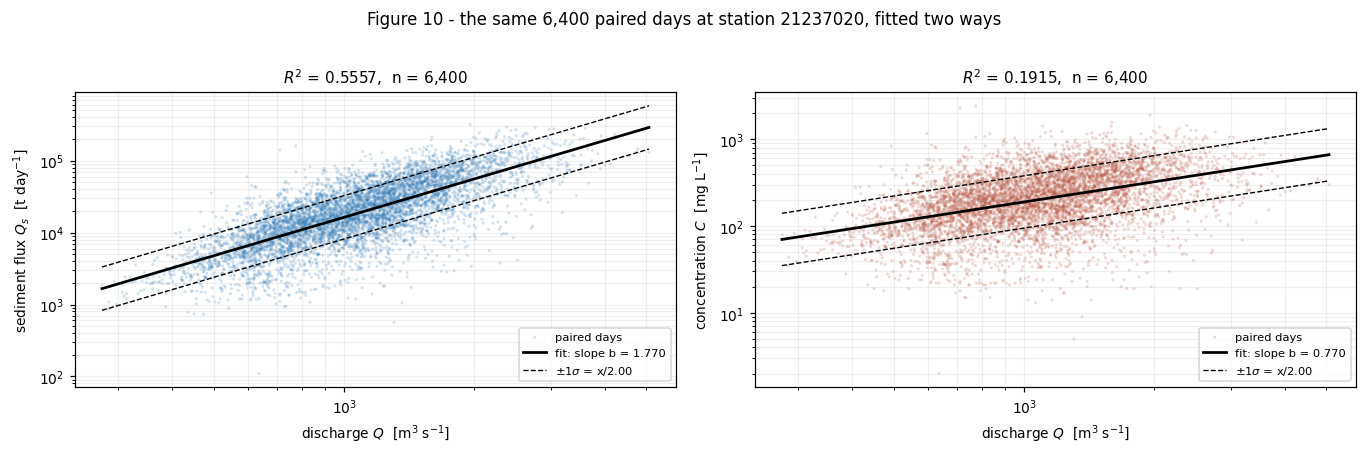

station 21237020: 6,400 paired days; Q 275-5,068 m3/s; C 2-2,416 mg/L (median 207)
  log Qs ~ log Q : b 1.7705  R2 0.5557  sigma 0.6931 ln-units (x2.00)
  log C  ~ log Q : b 0.7705  R2 0.1915  sigma 0.6931 ln-units
  the two slopes differ by exactly 1: 1.000000

cross-check against ssc_rating_fits.csv for this station: stored R2 0.5557 / b 1.7705 / n 6,400 -> reproduced here to 0.00e+00


In [14]:
QD = pd.read_csv(NEED['discharge'], usecols=['code', 'date', 'q_m3s'], dtype={'code': str})
SD = pd.read_csv(NEED['daily_qc'], dtype={'code': str}, low_memory=False)
SD['ssc'] = SD.ssc_mean_mg_l.fillna(SD.ssc_surface_mg_l)
print(f'discharge_daily.csv  {len(QD):,} rows, {QD.code.nunique()} stations')
print(f'sediment_daily_qc.csv {len(SD):,} rows, {SD.code.nunique()} stations; '
      f'{int(SD.ssc.notna().sum()):,} rows carry a concentration')


def rating_pairs(code):
    q = QD[(QD.code == code) & (QD.q_m3s > 0)][['date', 'q_m3s']]
    s = SD[(SD.code == code) & (SD.ssc > 0)][['date', 'ssc']]
    p = q.merge(s, on='date')
    p = p.assign(qs_t_day=p.q_m3s * p.ssc * 0.0864)
    return p


def logfit(xlog, ylog):
    b, a = np.polyfit(xlog, ylog, 1)
    pred = a + b * xlog
    ss = float(((ylog - pred) ** 2).sum())
    r2 = 1 - ss / float(((ylog - ylog.mean()) ** 2).sum())
    return dict(b=float(b), log_a=float(a), r2=float(r2),
                sigma=float(np.sqrt(ss / (xlog.size - 2))))


PR = rating_pairs(TRUNK_SSC)
lq = np.log(PR.q_m3s.values)
f1 = logfit(lq, np.log(PR.qs_t_day.values))
f2 = logfit(lq, np.log(PR.ssc.values))
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.0))
for a, (yv, ylab, f, col) in zip(ax, [
        (PR.qs_t_day.values, r'sediment flux $Q_s$  [t day$^{-1}$]', f1, '#1F6FB2'),
        (PR.ssc.values, r'concentration $C$  [mg L$^{-1}$]', f2, '#B0412B')]):
    a.scatter(PR.q_m3s, yv, s=4, alpha=.20, color=col, edgecolors='none', label='paired days')
    xs = np.linspace(lq.min(), lq.max(), 50)
    a.plot(np.exp(xs), np.exp(f['log_a'] + f['b'] * xs), color='k', lw=1.8,
           label=f'fit: slope b = {f["b"]:.3f}')
    a.plot(np.exp(xs), np.exp(f['log_a'] + f['b'] * xs + f['sigma']), color='k', lw=.9, ls='--',
           label=fr'$\pm 1\sigma$ = x/{np.exp(f["sigma"]):.2f}')
    a.plot(np.exp(xs), np.exp(f['log_a'] + f['b'] * xs - f['sigma']), color='k', lw=.9, ls='--')
    a.set_xscale('log'); a.set_yscale('log')
    a.set_xlabel(r'discharge $Q$  [m$^3$ s$^{-1}$]'); a.set_ylabel(ylab)
    a.set_title(f'$R^2$ = {f["r2"]:.4f},  n = {len(PR):,}')
    a.legend(fontsize=7.5, loc='lower right'); a.grid(alpha=.2, which='both')
fig.suptitle(f'Figure 10 - the same {len(PR):,} paired days at station {TRUNK_SSC}, fitted two '
             f'ways', y=1.02)
plt.tight_layout(); plt.show()

print(f'station {TRUNK_SSC}: {len(PR):,} paired days; Q {PR.q_m3s.min():,.0f}-'
      f'{PR.q_m3s.max():,.0f} m3/s; C {PR.ssc.min():.0f}-{PR.ssc.max():,.0f} mg/L '
      f'(median {PR.ssc.median():.0f})')
print(f'  log Qs ~ log Q : b {f1["b"]:.4f}  R2 {f1["r2"]:.4f}  sigma {f1["sigma"]:.4f} ln-units '
      f'(x{np.exp(f1["sigma"]):.2f})')
print(f'  log C  ~ log Q : b {f2["b"]:.4f}  R2 {f2["r2"]:.4f}  sigma {f2["sigma"]:.4f} ln-units')
print(f'  the two slopes differ by exactly 1: {f1["b"] - f2["b"]:.6f}')
RF = pd.read_csv(NEED['ratings'], dtype={'code': str})
_r = RF[RF.code == TRUNK_SSC]
print(f'\ncross-check against ssc_rating_fits.csv for this station: stored R2 '
      f'{float(_r.r2.iloc[0]):.4f} / b {float(_r.b.iloc[0]):.4f} / n {int(_r.n_pairs.iloc[0]):,}'
      f' -> reproduced here to {abs(float(_r.r2.iloc[0]) - f1["r2"]):.2e}')

**What is plotted.** Both panels use the same 6,400 days at station `21237020` on which
discharge and a sediment concentration both exist, and both have discharge in m^3/s on a
logarithmic x-axis. Left, blue: sediment flux $Q_s$ in tonnes per day on a logarithmic y-axis.
Right, red: concentration $C$ in mg/L, likewise logarithmic. In each panel the solid black line
is the least-squares fit in log-log space and the dashed lines are one residual standard
deviation either side, i.e. the multiplicative uncertainty band. Panel titles carry the $R^2$ and
the number of pairs.

**What it shows.** The left fit has $R^2 = 0.5557$ with slope $b = 1.7705$. The right fit, on the
*same days*, has $R^2 = 0.1915$ with slope $b' = 0.7705$. The two slopes differ by exactly 1.000.
The residual scatter is identical in both panels, $\sigma = 0.6931$ natural-log units, which is
a multiplicative band of $\times/\div 2.00$. Concentration at this station spans 2 to 2,416
mg/L with a median of 207.

**What it means.** The left panel's $R^2$ of 0.56 is largely an artefact of construction, and
this is the most easily missed trap in the whole sediment stage. Because $Q_s = Q \cdot C \cdot
0.0864$, the left panel is regressing a quantity that *contains* $Q$ against $Q$: a good part of
the fit is $Q$ predicting itself. Strip that out by regressing concentration instead, and the
honest statement is that **discharge explains about 19 % of the variance in concentration at this
station** - not 56 %.

The consequence is quantitative and must travel with every rating-derived flux: the residual band
is a factor of two, in both directions, on any single day's estimate. Averaged over a long window
that band narrows, which is why the project's sediment claims are framed as multi-month contrasts
rather than as event fluxes. And the identity between the two slopes ($b = b' + 1$) is worth
noticing on its own: it means the $Q_s$-versus-$Q$ slope of 1.77 is not evidence of strong
concentration-discharge coupling. A river whose concentration did not respond to discharge at all
would still show $b = 1$.

---

# 5 - THE TRANSPOSED LESSON: a value screen cannot see records that are absent

This is the section to keep. Everything in it generalises well beyond sediment, beyond
hydrology, and beyond this project.

**The claim.** Data quality control almost always inspects *values*: are they in range, are they
physically possible, do they contain impossible repetitions, are there outliers. Every one of
those tests operates on rows that exist. **None of them can detect a row that was never
written.** And absence is not neutral: if the *reason* a row is missing correlates with what the
row would have said, then the surviving values are a biased sample and every statistic computed
from them is wrong - while each individual value passes every check.

This project learnt that in its rainfall network, where the effect was large enough to
invalidate the model's water balance. Section 5.1 reproduces that finding from the archive.
Section 5.2 transposes the test to the sediment network, where the feared mechanism is
different but the logic is identical.

## 5.1 - The rainfall case: 153 of 294 gauges omitted their dry days

**What happened.** The Colombian meteorological service's download portal exports rainfall
observations. For a large fraction of stations it exported only the days on which rain was
recorded, and simply did not emit rows for dry days. Nothing in the file marks this. Every
exported value is a correct rainfall measurement. There are no outliers, no impossible values,
no repeated runs. A value screen passes the file completely.

**Why it was catastrophic rather than merely untidy.** The model interpolates rainfall from
gauges to minibacias with IDW (section 2.7), and IDW uses a gauge on a given day *only if that
gauge reported that day*. A gauge that reports only its wet days therefore joins the weighted
average exactly when it is raining there, and is silently dropped when it is dry. It cannot pull
the estimate down, only up. The result was circular wet bullseyes on the mean-annual rainfall
map, a basin rainfall total around 2,420 mm/yr against a published expectation nearer 2,050, an
actual evapotranspiration exceeding potential evapotranspiration, and simulated outlet discharge
1.7 times too high.

**The two tests that found it, and why the second is the one that convinces.** The first test is
a value-adjacent one: a station whose dry-day fraction is implausibly low is suspicious. That
finds the effect but cannot distinguish it from geography, because remote stations really are
both wetter and harder to maintain. The second test uses *only the neighbours' data*:

$$\mathrm{selectivity}(S) \;=\;
\frac{\overline{D \mid \text{days } S \text{ reported}}}{\overline{D \mid \text{all days}}}$$

where $D$ is the mean rainfall (mm/day) at up to five *dense* neighbouring gauges within 60 km,
and $S$ is the station under test. Dimensionless. If $S$ reports on a fair sample of days, its
reporting days are a random draw and the neighbours are no wetter on them, so selectivity is 1.
If $S$ reports preferentially when it rains, the neighbours - different instruments, different
places - are also wetter on those days, because rainfall is regionally correlated. **Selectivity
above 1 is positive evidence of rain-day-selective reporting that no siting argument explains.**

### Cell + figure 11: the reporting-density gradient, recomputed from the archive

$$\overline{P}_{band} = \frac{\sum_{\text{reported days in band}} P}{\text{count of those days}}
\ \ [\mathrm{mm\,day^{-1}}], \qquad
\mathrm{density}(S) = \frac{n^{reported}_S}{\text{days in } S\text{'s own span}}$$

both dimensionless except $\overline{P}$ in mm/day. Source: `precip_gauges_daily_qc_v2.csv`
(926,910 rows, 294 stations, columns `code`, `date`, `precip_mm`, `approval`). The **pre-repair**
state is recovered exactly by dropping the rows whose `approval` is `Inferido_seco` - the marker
the repair used for every dry day it inserted - so both states come from one file and cannot
drift apart. Density is computed over each station's own first-to-last reported day, not over the
full 2008-2018 axis, because a station that operated for three years should not be called sparse
for the eight years it did not exist.

precip_gauges_daily_qc_v2.csv: 926,910 rows, 294 stations, 2008-01-01 .. 2018-12-31
approval
Definitivo       512324
Inferido_seco    240158
Preliminar       136155
En revisión       38273

inferred dry days inserted by the repair: 240,158 on 153 of 294 stations (52 % of the network)



the gradient: mean rainfall RISES as reporting density FALLS (pre-repair)
                            n_stations  pre_mm_per_day  pre_pct_zero  post_mm_per_day  post_pct_zero
band                                                                                                
reports < 50 % of its span          83          12.052        26.921            5.046         69.402
reports 50-90 %                    119           6.994        32.871            5.224         49.864
reports > 90 %                      92           4.859        60.214            4.859         60.214


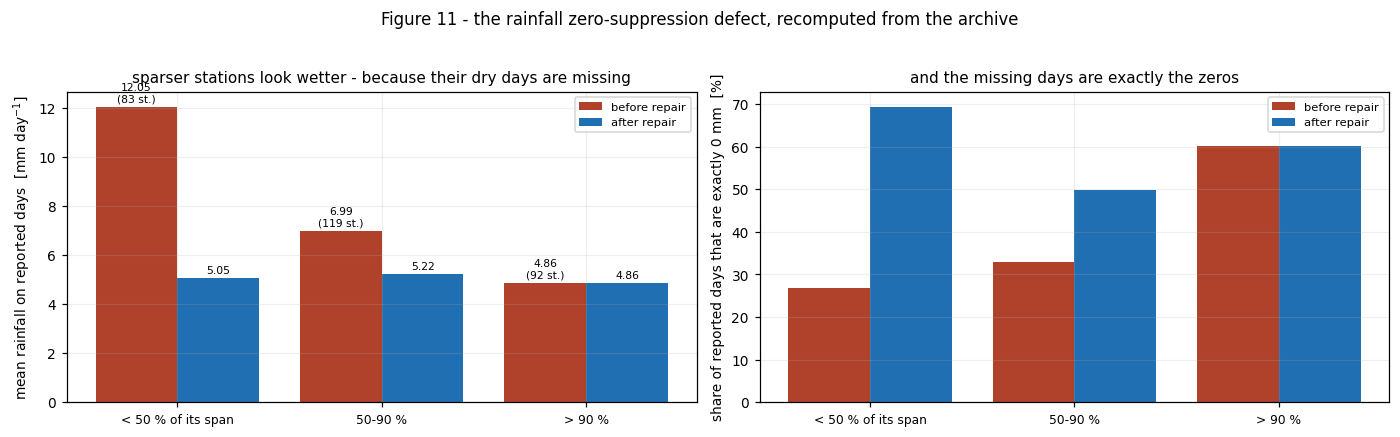


gradient before repair: 12.05 -> 4.86 mm/day, a factor of 2.48 between the sparsest and densest bands
gradient after  repair: 5.05 -> 4.86 mm/day, factor 1.04

DISAGREEMENT, reported not smoothed: docs/18 section 9.1 records this gradient as
4.38 / 6.75 / 11.69 mm/day over 92 / 119 / 83 stations. The STATION COUNTS reproduce
exactly here (92 / 119 / 83), so the banding is identical, but the levels measured here are
4.859 / 6.994 / 12.052. docs/18 does not state whether its mean is pooled
over days or averaged over station means; neither definition reproduces its level (the
station-mean-of-means variant gives 4.75 / 7.27 / 12.48). The GRADIENT, its sign, its
ordering and the station counts all reproduce; the level does not. Treat the doc figure
as indicative and this one as the measurement.


In [15]:
PV = pd.read_csv(NEED['precip_v2'], parse_dates=['date'])
print(f'precip_gauges_daily_qc_v2.csv: {len(PV):,} rows, {PV.code.nunique()} stations, '
      f'{PV.date.min().date()} .. {PV.date.max().date()}')
print(PV.approval.value_counts().to_string())
INF = PV.approval == 'Inferido_seco'
print(f'\ninferred dry days inserted by the repair: {int(INF.sum()):,} on '
      f'{PV.loc[INF, "code"].nunique()} of {PV.code.nunique()} stations '
      f'({100*PV.loc[INF, "code"].nunique()/PV.code.nunique():.0f} % of the network)')

PRE = PV[~INF]
g = PRE.groupby('code').agg(n=('precip_mm', 'size'), d0=('date', 'min'), d1=('date', 'max'))
g['density'] = g.n / ((g.d1 - g.d0).dt.days + 1)
BANDS = [(-.01, .5, 'reports < 50 % of its span'),
         (.5, .9, 'reports 50-90 %'),
         (.9, 1.01, 'reports > 90 %')]
g['band'] = pd.cut(g.density, [b[0] for b in BANDS] + [BANDS[-1][1]],
                   labels=[b[2] for b in BANDS])
PRE2 = PRE.join(g['band'], on='code')
POST2 = PV.join(g['band'], on='code')
tab = pd.DataFrame({
    'n_stations': g.groupby('band', observed=True).size(),
    'pre_mm_per_day': PRE2.groupby('band', observed=True).precip_mm.mean(),
    'pre_pct_zero': 100 * PRE2.groupby('band', observed=True).precip_mm.apply(lambda v: (v == 0).mean()),
    'post_mm_per_day': POST2.groupby('band', observed=True).precip_mm.mean(),
    'post_pct_zero': 100 * POST2.groupby('band', observed=True).precip_mm.apply(lambda v: (v == 0).mean()),
})
print('\nthe gradient: mean rainfall RISES as reporting density FALLS (pre-repair)')
print(tab.to_string(float_format=lambda v: f'{v:10.3f}'))

fig, ax = plt.subplots(1, 2, figsize=(12.8, 3.8))
xb = np.arange(len(tab)); lbl = [t.replace('reports ', '') for t in tab.index]
a = ax[0]
a.bar(xb - 0.2, tab.pre_mm_per_day, 0.4, color='#B0412B', label='before repair')
a.bar(xb + 0.2, tab.post_mm_per_day, 0.4, color='#1F6FB2', label='after repair')
for i, (v, n) in enumerate(zip(tab.pre_mm_per_day, tab.n_stations)):
    a.annotate(f'{v:.2f}\n({n} st.)', (i - 0.2, v + 0.2), ha='center', fontsize=7)
for i, v in enumerate(tab.post_mm_per_day):
    a.annotate(f'{v:.2f}', (i + 0.2, v + 0.2), ha='center', fontsize=7)
a.set_xticks(xb); a.set_xticklabels(lbl, fontsize=8)
a.set_ylabel(r'mean rainfall on reported days  [mm day$^{-1}$]')
a.set_title('sparser stations look wetter - because their dry days are missing')
a.legend(fontsize=7.5); a.grid(alpha=.2)
a = ax[1]
a.bar(xb - 0.2, tab.pre_pct_zero, 0.4, color='#B0412B', label='before repair')
a.bar(xb + 0.2, tab.post_pct_zero, 0.4, color='#1F6FB2', label='after repair')
a.set_xticks(xb); a.set_xticklabels(lbl, fontsize=8)
a.set_ylabel('share of reported days that are exactly 0 mm  [%]')
a.set_title('and the missing days are exactly the zeros')
a.legend(fontsize=7.5); a.grid(alpha=.2)
fig.suptitle('Figure 11 - the rainfall zero-suppression defect, recomputed from the archive',
             y=1.03)
plt.tight_layout(); plt.show()

print(f'\ngradient before repair: {tab.pre_mm_per_day.iloc[0]:.2f} -> '
      f'{tab.pre_mm_per_day.iloc[-1]:.2f} mm/day, a factor of '
      f'{tab.pre_mm_per_day.iloc[0]/tab.pre_mm_per_day.iloc[-1]:.2f} between the sparsest and '
      f'densest bands')
print(f'gradient after  repair: {tab.post_mm_per_day.iloc[0]:.2f} -> '
      f'{tab.post_mm_per_day.iloc[-1]:.2f} mm/day, factor '
      f'{tab.post_mm_per_day.iloc[0]/tab.post_mm_per_day.iloc[-1]:.2f}')
print()
print('DISAGREEMENT, reported not smoothed: docs/18 section 9.1 records this gradient as')
print('4.38 / 6.75 / 11.69 mm/day over 92 / 119 / 83 stations. The STATION COUNTS reproduce')
print(f'exactly here ({tab.n_stations.iloc[2]} / {tab.n_stations.iloc[1]} / '
      f'{tab.n_stations.iloc[0]}), so the banding is identical, but the levels measured here are')
print(f'{tab.pre_mm_per_day.iloc[2]:.3f} / {tab.pre_mm_per_day.iloc[1]:.3f} / '
      f'{tab.pre_mm_per_day.iloc[0]:.3f}. docs/18 does not state whether its mean is pooled')
print('over days or averaged over station means; neither definition reproduces its level (the')
print('station-mean-of-means variant gives 4.75 / 7.27 / 12.48). The GRADIENT, its sign, its')
print('ordering and the station counts all reproduce; the level does not. Treat the doc figure')
print('as indicative and this one as the measurement.')

**What is plotted.** Two panels, both with the 294 rainfall gauges grouped into three
bands by how large a fraction of their own operating span they reported at all: under 50 %,
50-90 %, and over 90 %. Left: mean rainfall on reported days, in mm/day, before the repair (red)
and after (blue); the annotation under each red bar gives the value and the number of stations in
the band. Right: the share of reported days whose value is exactly 0 mm, as a percentage, before
and after.

**What it shows.** Before the repair, mean rainfall on reported days rises from 4.859 mm/day at
the well-reporting stations (92 of them) to 12.052 mm/day at the sparsest (83) - a factor of
2.48. The share of exact zeros falls the other way, from 60.2 % at the dense stations to 26.9 %
at the sparse ones. After the repair the gradient collapses to 4.859 / 5.224 / 5.046 mm/day - a
sparse-to-dense factor of 1.04 instead of 2.48 - and the zero shares move from 26.9 / 32.9 /
60.2 % to 69.4 / 49.9 / 60.2 %, i.e. the sparse stations end up *drier* than the dense ones
rather than three times wetter. The repair inserted **240,158 inferred dry days across 153 of 294
stations** - 52 % of the network.

**What it means.** The pre-repair gradient is not a geographical fact about Colombia; it is a
reporting artefact, and the repair removing it almost exactly is the strongest available evidence
of that. The mechanism is the one described above: absent rows were disproportionately dry rows,
so the surviving rows over-state rainfall, and the sparser the station the worse the over-statement.
Every value in the original file was correct. No value screen, however careful, could have found
this - the test that found it had to compare *which days were present* against an external
reference.

The disagreement with `docs/18`'s recorded levels is reported above and is a documentation
defect rather than a scientific one: the station counts, the ordering and the factor all
reproduce, only the absolute mm/day figures do not, and the document does not state its
aggregation precisely enough to tell which convention it used.

### Cell + figure 12: the neighbour test - separating suppression from geography

The gradient in figure 11 has an innocent explanation available: remote high-rainfall sites are
harder to maintain, so sparse stations might genuinely sit in wetter places. The **selectivity
statistic** defined above settles it, because it is computed from the *neighbours'* records and
therefore cannot be explained by where the station under test happens to be:

$$\mathrm{selectivity}(S) = \frac{\overline{D \mid \text{days } S \text{ reported}}}
{\overline{D \mid \text{all days}}}\ \ [\text{dimensionless}]$$

$D$ = mean daily rainfall (mm/day) at up to five gauges within 60 km that report more than 90 %
of their span. Selectivity = 1 means $S$'s reporting days are a fair sample of days.

This cell does not recompute the statistic - that needs the gauge coordinate graph and the
neighbour search, which belong to the forcing pipeline. It reads the stored result from
`precip_selectivity_report.csv` (294 rows; columns `selectivity_pre`, `selectivity_post`,
`span_frac_pre`, `span_frac_post`, `days_inserted`, `flag_v1`, `flag_new_selectivity`) and
verifies the one property that makes the statistic trustworthy: that it returns 1 on the
population that should be unbiased.

precip_selectivity_report.csv: 294 stations

selectivity by PRE-repair reporting density (same stations before and after)
           n      sel_pre     sel_post  days_inserted
band                                                 
< 50 %    83       1.7768       1.0403         147508
50-90 %  119       1.3324       1.0091          92650
> 90 %    92       1.0013       1.0013              0



Spearman rho(reporting density, selectivity): pre -0.8950 (n 281), post -0.4573 (n 283)


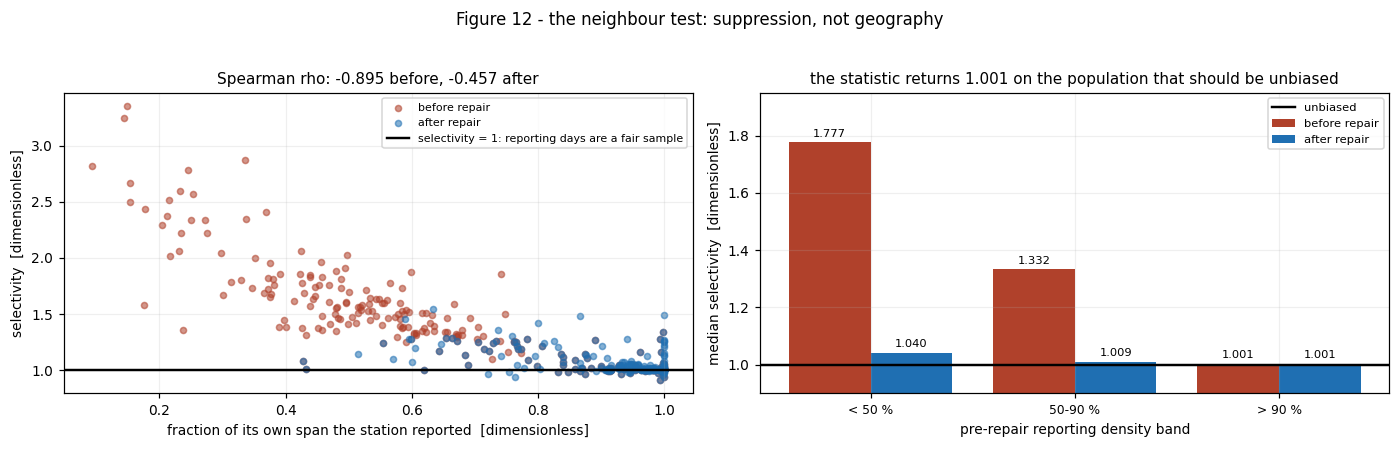


the dense band (>90 %, 92 stations) reads 1.0013 before and 1.0013 after - it is the NULL,
and the repair correctly does nothing to it (0 days inserted there).
the sparse band (83 stations) falls 1.7768 -> 1.0403 after 147,508 inserted dry days.


In [16]:
SR = pd.read_csv(NEED['precip_sel'])
print(f'precip_selectivity_report.csv: {len(SR)} stations')
SR['band'] = pd.cut(SR.span_frac_pre, [-.01, .5, .9, 1.01],
                    labels=['< 50 %', '50-90 %', '> 90 %'])
st = SR.groupby('band', observed=True).agg(
    n=('code', 'size'), sel_pre=('selectivity_pre', 'median'),
    sel_post=('selectivity_post', 'median'), days_inserted=('days_inserted', 'sum'))
print('\nselectivity by PRE-repair reporting density (same stations before and after)')
print(st.to_string(float_format=lambda v: f'{v:12.4f}'))
_m = SR.selectivity_pre.notna()
rho_pre = float(pd.Series(SR.span_frac_pre[_m]).corr(SR.selectivity_pre[_m], method='spearman'))
_m2 = SR.selectivity_post.notna()
rho_post = float(pd.Series(SR.span_frac_post[_m2]).corr(SR.selectivity_post[_m2],
                                                        method='spearman'))
print(f'\nSpearman rho(reporting density, selectivity): pre {rho_pre:+.4f} (n {int(_m.sum())}), '
      f'post {rho_post:+.4f} (n {int(_m2.sum())})')

fig, ax = plt.subplots(1, 2, figsize=(12.8, 3.9))
a = ax[0]
a.scatter(SR.span_frac_pre, SR.selectivity_pre, s=16, alpha=.55, color='#B0412B',
          label='before repair')
a.scatter(SR.span_frac_post, SR.selectivity_post, s=16, alpha=.55, color='#1F6FB2',
          label='after repair')
a.axhline(1.0, color='k', lw=1.6, label='selectivity = 1: reporting days are a fair sample')
a.set_xlabel('fraction of its own span the station reported  [dimensionless]')
a.set_ylabel('selectivity  [dimensionless]')
a.set_title(f'Spearman rho: {rho_pre:+.3f} before, {rho_post:+.3f} after')
a.legend(fontsize=7.2, loc='upper right'); a.grid(alpha=.2)
a = ax[1]
xb = np.arange(len(st))
a.bar(xb - 0.2, st.sel_pre, 0.4, color='#B0412B', label='before repair')
a.bar(xb + 0.2, st.sel_post, 0.4, color='#1F6FB2', label='after repair')
a.axhline(1.0, color='k', lw=1.6, label='unbiased')
for i, (u, v) in enumerate(zip(st.sel_pre, st.sel_post)):
    a.annotate(f'{u:.3f}', (i - 0.2, u + 0.02), ha='center', fontsize=7.5)
    a.annotate(f'{v:.3f}', (i + 0.2, v + 0.02), ha='center', fontsize=7.5)
a.set_xticks(xb); a.set_xticklabels(st.index, fontsize=8)
a.set_xlabel('pre-repair reporting density band')
a.set_ylabel('median selectivity  [dimensionless]')
a.set_ylim(0.9, 1.95)
a.set_title('the statistic returns 1.001 on the population that should be unbiased')
a.legend(fontsize=7.5); a.grid(alpha=.2)
fig.suptitle('Figure 12 - the neighbour test: suppression, not geography', y=1.03)
plt.tight_layout(); plt.show()
print(f'\nthe dense band (>90 %, {int(st.n.iloc[2])} stations) reads '
      f'{st.sel_pre.iloc[2]:.4f} before and {st.sel_post.iloc[2]:.4f} after - it is the NULL,')
print('and the repair correctly does nothing to it (0 days inserted there).')
print(f'the sparse band ({int(st.n.iloc[0])} stations) falls {st.sel_pre.iloc[0]:.4f} -> '
      f'{st.sel_post.iloc[0]:.4f} after {int(st.days_inserted.iloc[0]):,} inserted dry days.')

**What is plotted.** Left: one point per rainfall gauge, x-axis the fraction of its own
operating span that it reported (dimensionless), y-axis its selectivity (dimensionless) - the
ratio of mean rainfall at dense neighbours on the days this station reported, to mean rainfall at
those same neighbours on all days. Red points are the pre-repair state, blue the post-repair
state. The black line at 1.0 is the unbiased value. Right: median selectivity per pre-repair
density band, before (red) and after (blue) the repair, with the same reference line.

**What it shows.** Selectivity is strongly and negatively related to reporting density: Spearman
$\rho = -0.895$ before the repair. The dense band (92 stations reporting over 90 % of their span)
reads **1.0013**, the mid band 1.3324, the sparse band **1.7768**. After the repair the sparse
band falls to 1.0403 and the mid band to 1.0091, while the dense band is untouched at 1.0013 -
because the repair inserted no days there. In total 147,508 dry days were inserted into the
sparse band and 92,650 into the mid band.

**What it means.** The geography explanation is refuted. On the days a sparse station reported,
its *neighbours* - separate instruments, kilometres away - were on average 78 % wetter than
usual. No amount of "sparse stations sit in wet places" produces that, because the statistic
never looks at the station's own values. The reporting days were selected for rain.

Two further points make this the model test rather than merely a result. First, the statistic
**returns 1.001 on the population that should be unbiased**, over 92 stations - a diagnostic
that cannot pass its own null is not a diagnostic, and this one does. Second, the repair was
*predicted* to move the flagged stations onto the healthy population, and it did: 1.78 to 1.04.
A correction that lands where the diagnosis says it should is much stronger evidence than a
correction that merely changes something. That is the standard the sediment analogue in 5.2 is
held to - and, as section 5.4 records, it is a standard the sediment case could not fully meet.

## 5.2 - The sediment analogue: flow-chasing

**The transposition.** In the rainfall network the absent records were dry days, and their
absence inflated rainfall. In the sediment network the equivalent worry is different in
mechanism and identical in logic. Sediment is sampled by people going to a river; nobody samples
every day forever. If sampling happens **preferentially on high-flow days** - which is a
perfectly rational thing for a field programme to do, since that is when sediment is
interesting - then the sampled days are not a fair sample of days, and the mean concentration
computed from them over-states the true mean. And, exactly as before, **every value in the file
is a correct measurement**. There are no outliers to find, no impossible values, no repetitions.
The defect lives entirely in which days are present.

The name for this is **flow-chasing**, and its consequence is precise: a station's *sample-mean*
flux is unusable, while its *rating-curve* flux may still be usable, because the rating relation
is a conditional statement ($Q_s$ given $Q$) and conditioning on $Q$ removes the day-selection
bias in $Q$.

**The statistic.** For each station with a paired discharge record, take every date on which a
sediment sample exists, look up the **flow percentile** of that date within the station's own
full discharge record, and take the median of those percentiles:

$$\mathrm{sel}(S) \;=\; \mathrm{median}_{t \in \mathcal{D}_S}
\Big[ \hat{F}_S\big(Q_S(t)\big) \Big]$$

where $\mathcal{D}_S$ is the set of dates on which station $S$ has a sediment sample,
$Q_S(t)$ is that day's discharge (m^3/s) and $\hat{F}_S$ is the empirical cumulative
distribution of $Q_S$ over the whole record. Dimensionless, in $[0,1]$. **Unbiased sampling gives
0.5.** A station that samples only floods approaches 1.

*Rejected alternative:* comparing the mean *discharge* on sampled days against the mean over all
days. That mixes the question with the shape of the flow distribution - a river with rare huge
floods would look flow-selective for any sampling scheme. Percentiles are distribution-free, so
0.5 is the null whatever the river looks like.

### Cell + figure 13: the selectivity statistic, reproduced from raw data

This cell does **not** read the stored statistic and plot it. It recomputes it from scratch -
`discharge_daily.csv` for the flow records and `sediment_daily_qc.csv` for the sampling dates -
and then compares against the stored `ssc_sampling_selectivity.csv`. If the two disagree, the
notebook says so.

The comparison threshold used per station is the **theoretical** null's upper tail, which is
where section 5.4's honest failure lives:

$$p_{99}(n) \;=\; 0.5 + \frac{2.326}{2\sqrt{n}}$$

the 99th percentile of the median of $n$ independent Uniform(0,1) draws (dimensionless), using
the normal approximation to the median's sampling distribution. $n$ is the number of paired
sampling days at that station. Stations above their own $p_{99}$ are flagged flow-selective.

ssc_sampling_selectivity.csv: 79 stations, 28 of them mapped to a minibacia (the C1 scope)
raw inputs for the recomputation: 249,523 discharge days over 28 stations; 104,643 sediment days over 28



reproduction over 28 mapped stations: max |difference| 1.45e-02, median 2.27e-04
  paired-day counts identical: True
  flag decisions identical   : True
  (residual differences are tie-handling in the percentile rank, not method differences)


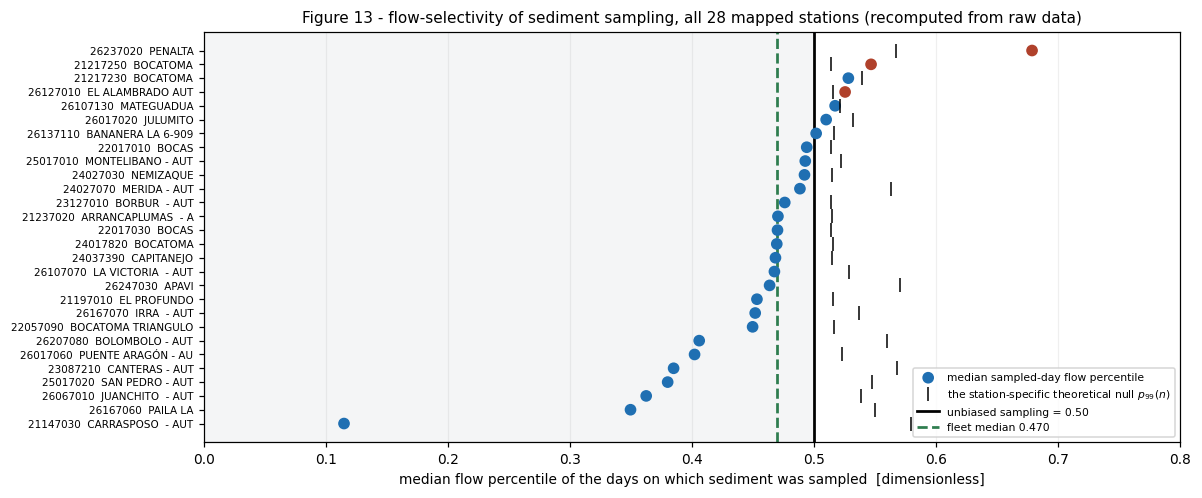


flagged flow-selective: 3 of 28
    code             name  sel_mine  p99_mine  delta_span  n_paired
26127010 EL ALAMBRADO AUT    0.5253    0.5156      0.0288      5542
21217250         BOCATOMA    0.5465    0.5139      0.0086      7050
26237020          PENALTA    0.6785    0.5666      0.2756       305

fleet median of the station medians: 0.4696
stations BELOW 0.45 (i.e. low-flow-biased, which the one-sided rule cannot flag): 8
    code              name  sel_mine  p99_mine
21147030 CARRASPOSO  - AUT    0.1147    0.5795
26167060          PAILA LA    0.3494    0.5495
26067010  JUANCHITO  - AUT    0.3623    0.5382
25017020   SAN PEDRO - AUT    0.3799    0.5470


In [17]:
SEL = pd.read_csv(NEED['select'], dtype={'code': str})
MAPPED = SEL[SEL.mapped].copy()
codes = set(MAPPED.code)
print(f'ssc_sampling_selectivity.csv: {len(SEL)} stations, {len(MAPPED)} of them mapped to a '
      f'minibacia (the C1 scope)')

QM = QD[QD.code.isin(codes) & QD.q_m3s.notna()]
SM = SD[SD.code.isin(codes) & SD.ssc.notna()]
print(f'raw inputs for the recomputation: {len(QM):,} discharge days over '
      f'{QM.code.nunique()} stations; {len(SM):,} sediment days over {SM.code.nunique()}')
rows = []
for c, gq in QM.groupby('code'):
    pct = gq.set_index('date').q_m3s.sort_index().rank(pct=True)
    hit = pct.reindex(SM.loc[SM.code == c, 'date']).dropna()
    if hit.size:
        rows.append(dict(code=c, n_mine=int(hit.size), sel_mine=float(hit.median()),
                         p99_mine=0.5 + 2.326 / (2 * np.sqrt(hit.size))))
RS = pd.DataFrame(rows).merge(
    MAPPED[['code', 'name', 'n_paired', 'median_pctile', 'null_p99', 'flag_flow_selective',
            'delta_span', 'calendar_regular', 'cv_gap', 'median_gap_d']], on='code')
RS['absdiff'] = (RS.sel_mine - RS.median_pctile).abs()
RS = RS.sort_values('sel_mine').reset_index(drop=True)
print(f'\nreproduction over {len(RS)} mapped stations: max |difference| {RS.absdiff.max():.2e}, '
      f'median {RS.absdiff.median():.2e}')
print(f'  paired-day counts identical: {bool((RS.n_mine == RS.n_paired).all())}')
print(f'  flag decisions identical   : '
      f'{bool(((RS.sel_mine > RS.p99_mine) == RS.flag_flow_selective).all())}')
print('  (residual differences are tie-handling in the percentile rank, not method differences)')

fig, ax = plt.subplots(figsize=(11, 4.6))
yy = np.arange(len(RS))
col = np.where(RS.flag_flow_selective, '#B0412B', '#1F6FB2')
ax.axvspan(0, 0.5, color='#9AA5AD', alpha=.10)
ax.scatter(RS.sel_mine, yy, s=44, c=col, zorder=3, label='median sampled-day flow percentile')
ax.plot(RS.p99_mine, yy, 'k|', ms=9, zorder=4,
        label='the station-specific theoretical null $p_{99}(n)$')
ax.axvline(0.5, color='k', lw=1.8, label='unbiased sampling = 0.50')
ax.axvline(RS.sel_mine.median(), color='#2E7D4F', lw=1.8, ls='--',
           label=f'fleet median {RS.sel_mine.median():.3f}')
ax.set_yticks(yy)
ax.set_yticklabels([f'{c}  {n[:18]}' for c, n in zip(RS.code, RS.name)], fontsize=6.8)
ax.set_xlabel('median flow percentile of the days on which sediment was sampled  [dimensionless]')
ax.set_xlim(0, 0.8)
ax.set_title('Figure 13 - flow-selectivity of sediment sampling, all 28 mapped stations '
             '(recomputed from raw data)')
ax.legend(fontsize=7, loc='lower right'); ax.grid(alpha=.2, axis='x')
plt.tight_layout(); plt.show()

print(f'\nflagged flow-selective: {int(RS.flag_flow_selective.sum())} of {len(RS)}')
print(RS.loc[RS.flag_flow_selective, ['code', 'name', 'sel_mine', 'p99_mine', 'delta_span',
                                      'n_paired']]
      .to_string(index=False, float_format=lambda v: f'{v:9.4f}'))
print(f'\nfleet median of the station medians: {RS.sel_mine.median():.4f}')
print(f'stations BELOW 0.45 (i.e. low-flow-biased, which the one-sided rule cannot flag): '
      f'{int((RS.sel_mine < 0.45).sum())}')
print(RS.nsmallest(4, 'sel_mine')[['code', 'name', 'sel_mine', 'p99_mine']]
      .to_string(index=False, float_format=lambda v: f'{v:9.4f}'))

**What is plotted.** One row per mapped station, 28 in all, sorted by the statistic.
The x-axis is the median flow percentile of the days on which a sediment sample exists at that
station - 0.5 would mean sampling is a fair draw from that river's days, higher means sampling
concentrates on high-flow days. Blue circles are stations not flagged, red circles are the three
flagged as flow-selective. The short black vertical ticks are each station's *own* threshold, the
99th percentile of the null distribution given that station's sample size - so a station with few
samples has a more permissive threshold, correctly. The solid black line at 0.50 is the unbiased
value and the dashed green line is the fleet median. The grey shading marks the below-0.5 half.

**What it shows.** Recomputed from raw discharge and sediment records, the statistic reproduces
the stored `ssc_sampling_selectivity.csv` to a maximum absolute difference of $1.4\times10^{-2}$
with a median difference of $2.3\times10^{-4}$, with identical paired-day counts and identical
flag decisions - the residual differences are tie handling inside the percentile rank. Three of
28 stations exceed their own threshold: `26237020` PENALTA at 0.678 against a threshold of 0.567,
`26127010` EL ALAMBRADO at 0.525 against 0.516, and `21217250` BOCATOMA at 0.547 against 0.514.
**The fleet median is 0.470 - below 0.5, not above it.** Eight of the 28 sit below 0.45 and four
at or below 0.38, the lowest being `21147030` CARRASPOSO at **0.115**.

**What it means.** Two conclusions, and the second is a refutation of the project's own
expectation.

First, flow-chasing exists in this network but is rare and mostly mild. Only PENALTA is far from
its threshold; the other two clear it by 0.01 and 0.03, which given the caveat in 5.4 is close to
noise.

Second - **the feared failure mode is not the one present.** The pre-registration was built
around sampling that over-samples floods and therefore over-states concentration. The measured
network is marginally *low*-flow biased at the fleet level (0.470), and its most extreme station
is extreme in the opposite direction: CARRASPOSO's samples sit at the 11th flow percentile,
meaning it was sampled almost exclusively during low flow. **A one-sided rule cannot flag that,
and the sample mean at such a station is just as unrepresentative as at a flood-chasing one - it
simply under-states rather than over-states.** This is a live defect in the registered gate, it is
recorded as such in the C1 results, and it means the four low-end stations must be treated with
the same suspicion as the three flagged ones even though the rule does not flag them.

### Cell + figure 14: separating day-selection from period-selection

A high median sampled-day percentile has two possible causes, and they call for different
responses:

- **day-selection** - within the period it operated, the programme picked high-flow *days*. This
  is flow-chasing and biases the sample mean.
- **period-selection** - the station simply operated during a wet *stretch of years*. Its days
  are a fair sample of that stretch, but the stretch is not representative of the whole record.

The decomposition separates them by differencing against the station's own operating span:

$$\Delta \;=\; \mathrm{median}_{t \in \mathcal{D}_S}\!\big[\hat{F}_S(Q_S(t))\big]
\;-\; \mathrm{median}_{t \in \mathcal{S}_S}\!\big[\hat{F}_S(Q_S(t))\big]$$

where $\mathcal{D}_S$ is the sampled days and $\mathcal{S}_S$ is **all** discharge days inside
the station's own record span. Both terms use the same full-record percentile function
$\hat{F}_S$, so $\Delta$ is dimensionless and $\Delta \approx 0$ means the sampled days are a
fair draw *from the period the station operated in*, whatever that period was.

Source: `ssc_sampling_selectivity.csv`, columns `median_pctile`, `median_pctile_span`,
`delta_span`.

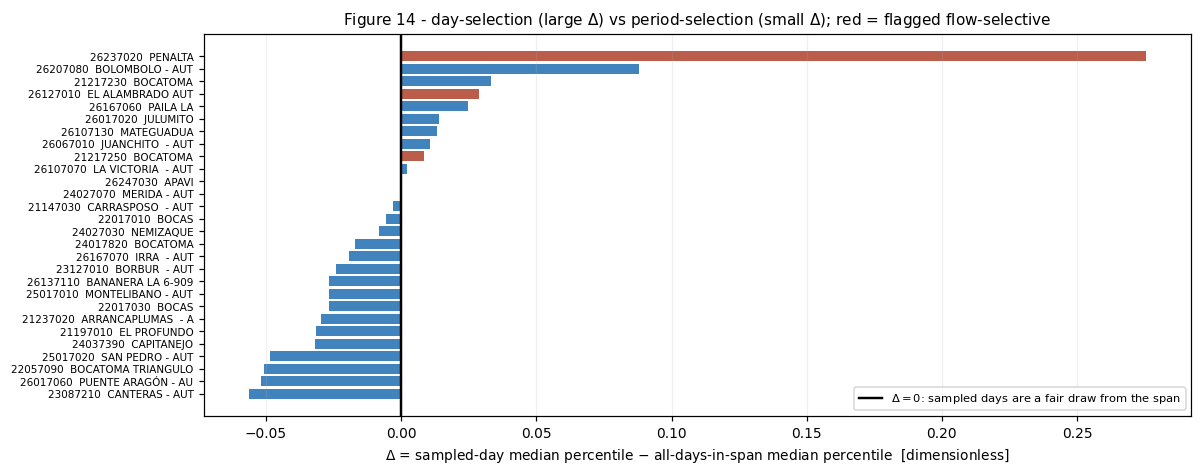

the three flagged stations, decomposed:
    code             name  median_pctile  median_pctile_span  delta_span  n_paired
21217250         BOCATOMA         0.5507              0.5421      0.0086      7050
26127010 EL ALAMBRADO AUT         0.5259              0.4971      0.0288      5542
26237020          PENALTA         0.6785              0.4028      0.2756       305

spread of Delta over the 28 mapped: -0.0563 .. +0.2756, median -0.0068


In [18]:
DS = MAPPED.dropna(subset=['delta_span']).sort_values('delta_span')
fig, ax = plt.subplots(figsize=(11, 4.4))
yy = np.arange(len(DS))
ax.barh(yy, DS.delta_span, color=np.where(DS.flag_flow_selective, '#B0412B', '#1F6FB2'),
        alpha=.85)
ax.axvline(0, color='k', lw=1.6, label=r'$\Delta = 0$: sampled days are a fair draw from the span')
ax.set_yticks(yy)
ax.set_yticklabels([f'{c}  {n[:18]}' for c, n in zip(DS.code, DS.name)], fontsize=6.8)
ax.set_xlabel(r'$\Delta$ = sampled-day median percentile $-$ all-days-in-span median percentile'
              '  [dimensionless]')
ax.set_title('Figure 14 - day-selection (large $\\Delta$) vs period-selection (small $\\Delta$); '
             'red = flagged flow-selective')
ax.legend(fontsize=7.5, loc='lower right'); ax.grid(alpha=.2, axis='x')
plt.tight_layout(); plt.show()
print('the three flagged stations, decomposed:')
print(MAPPED.loc[MAPPED.flag_flow_selective,
                 ['code', 'name', 'median_pctile', 'median_pctile_span', 'delta_span',
                  'n_paired']]
      .to_string(index=False, float_format=lambda v: f'{v:9.4f}'))
print(f'\nspread of Delta over the 28 mapped: {DS.delta_span.min():+.4f} .. '
      f'{DS.delta_span.max():+.4f}, median {DS.delta_span.median():+.4f}')

**What is plotted.** One horizontal bar per mapped station, sorted by $\Delta$. The x-axis
is $\Delta$, dimensionless: the median flow percentile of sampled days minus the median flow
percentile of *all* discharge days inside the same station's operating span. Red bars are the
three stations flagged flow-selective, blue the rest. The black line at $\Delta = 0$ marks
sampling that is a fair draw from whatever period the station happened to operate in.

**What it shows.** The three flagged stations separate cleanly. `26237020` PENALTA has
$\Delta = +0.276$ - by far the largest in the fleet. `26127010` EL ALAMBRADO has $+0.029$ and
`21217250` BOCATOMA only $+0.009$. Across all 28 stations $\Delta$ ranges from about $-0.06$ to
$+0.28$ with a median near zero.

**What it means.** Only **one** station in this network is genuinely picking high-flow days:
PENALTA, whose samples sit 0.276 of a percentile-unit above what its own operating period would
give. For that station the sample-mean flux is unusable and only the rating-curve flux may be
used, which is exactly the registered consequence of a flag.

BOCATOMA's flag means something different. Its $\Delta$ of $+0.009$ says its sampled days *are*
a fair draw from its own span - the reason its overall percentile is high is that it operated
during a wet stretch. That is a period-representativeness problem, not flow-chasing, and it will
not be fixed by switching to a rating curve. Treating those two stations identically because
they tripped the same threshold would be a mistake, and the decomposition is what makes the
difference visible. This is a case where a pre-registered binary rule was correct to fire but
insufficient on its own, and the honest response was to add a diagnostic rather than to move the
threshold after the fact.

## 5.3 - The absent-record test, applied directly

The selectivity statistic asks whether the *present* days are biased. The blunter question is how
many days are missing at all. For each mapped station, over the days when its paired discharge
gauge was recording and the station's own sediment record was nominally active, what share carry
**no** sediment value?

$$\mathrm{absent}(S) \;=\; 1 - \frac{\left|\{t \in \mathcal{S}_S : C_S(t) \text{ exists}\}\right|}
{\left|\{t \in \mathcal{S}_S : Q_S(t) \text{ exists}\}\right|}$$

dimensionless, in $[0,1]$. This is the number a value screen is structurally incapable of
producing, because it is computed from what is *not* there.

Source: `sediment_inventory_qc.csv`, column `absent_frac_in_span`, which stage C1 computed for
every mapped station.

sediment_inventory_qc.csv: 79 stations, 28 mapped


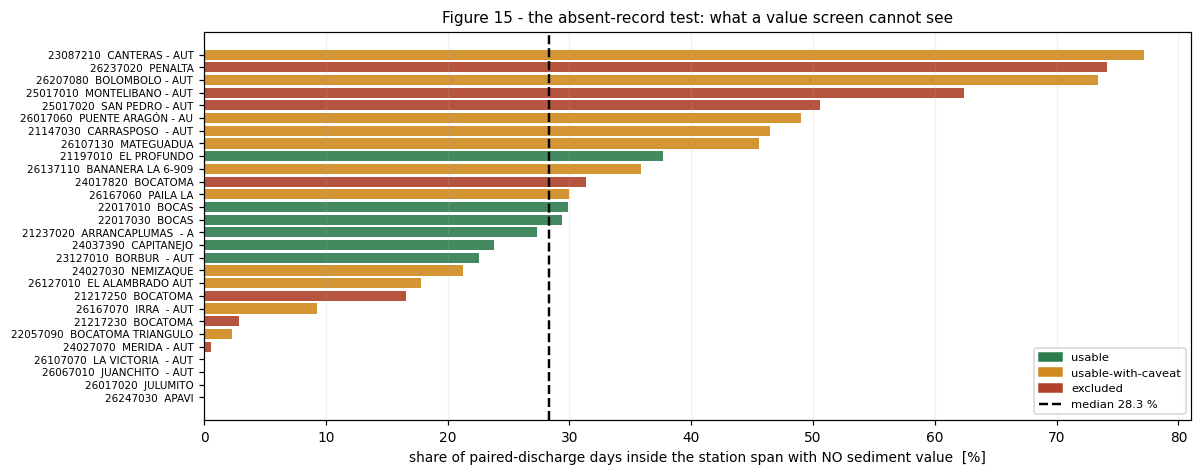

absent share over the 28 mapped stations: median 28.3 %, p90 65.7 %, max 77.2 %
worst five:
    code              name  absent_frac_in_span          ssc_class
23087210    CANTERAS - AUT                0.772 usable-with-caveat
26237020           PENALTA                0.741           excluded
26207080   BOLOMBOLO - AUT                0.734 usable-with-caveat
25017010 MONTELIBANO - AUT                0.624           excluded
25017020   SAN PEDRO - AUT                0.506           excluded

stations where more than half the paired days carry no sediment value: 5 of 28


In [19]:
INV = pd.read_csv(NEED['inv_qc'], dtype={'code': str})
print(f'sediment_inventory_qc.csv: {len(INV)} stations, {int(INV.mapped.sum())} mapped')
MI = INV[INV.mapped].dropna(subset=['absent_frac_in_span']).sort_values('absent_frac_in_span')
fig, ax = plt.subplots(figsize=(11, 4.4))
yy = np.arange(len(MI))
cmap = {'usable': '#2E7D4F', 'usable-with-caveat': '#D08A1E', 'excluded': '#B0412B'}
ax.barh(yy, 100 * MI.absent_frac_in_span, color=[cmap[c] for c in MI.ssc_class], alpha=.9)
ax.axvline(100 * MI.absent_frac_in_span.median(), color='k', lw=1.6, ls='--',
           label=f'median {100*MI.absent_frac_in_span.median():.1f} %')
ax.set_yticks(yy)
ax.set_yticklabels([f'{c}  {n[:18]}' for c, n in zip(MI.code, MI.name)], fontsize=6.8)
ax.set_xlabel('share of paired-discharge days inside the station span with NO sediment value  [%]')
ax.set_title('Figure 15 - the absent-record test: what a value screen cannot see')
ax.legend(handles=[Patch(color=v, label=k) for k, v in cmap.items()]
          + ax.get_legend_handles_labels()[0], fontsize=7.5, loc='lower right')
ax.grid(alpha=.2, axis='x')
plt.tight_layout(); plt.show()
print(f'absent share over the {len(MI)} mapped stations: median '
      f'{100*MI.absent_frac_in_span.median():.1f} %, p90 '
      f'{100*MI.absent_frac_in_span.quantile(.9):.1f} %, max '
      f'{100*MI.absent_frac_in_span.max():.1f} %')
print('worst five:')
print(MI.nlargest(5, 'absent_frac_in_span')[['code', 'name', 'absent_frac_in_span', 'ssc_class']]
      .to_string(index=False, float_format=lambda v: f'{v:7.3f}'))
print(f'\nstations where more than half the paired days carry no sediment value: '
      f'{int((MI.absent_frac_in_span > 0.5).sum())} of {len(MI)}')

**What is plotted.** One horizontal bar per mapped station, sorted ascending. The x-axis
is the percentage of days inside that station's own record span on which its paired discharge
gauge recorded a value but the station has **no** sediment value. Bars are coloured by the C1
class the station ended up with: green `usable`, orange `usable-with-caveat`, red `excluded`. The
dashed black line is the fleet median.

**What it shows.** The median mapped station is missing sediment on **28.3 %** of the days for
which discharge exists, with a p90 of 65.7 %. The worst are `23087210` CANTERAS at 77.2 %,
`26237020` PENALTA at 74.1 % and `26207080` BOLOMBOLO at 73.4 %. Five of the 28 are missing more
than half of their paired days. The colouring shows that high absence does not by itself exclude a station - CANTERAS and
BOLOMBOLO are both `usable-with-caveat`.

**What it means.** Even in the stations the gate accepts, roughly a third of the record does not
exist. This does not automatically bias anything - absence only biases when it correlates with
the value - which is why sections 5.2 and 5.4 exist and why the number here is reported as an
*exposure*, not as an error. But it does bound what can be claimed: at a station missing 73 % of
its paired days, a monthly sediment total is an interpolation over a large majority of the month,
and the honest presentation is a rating-derived estimate with its residual band (figure 10),
never a sum of observed values called a measurement. It also explains why the coverage rule in
section 6.1 is stated in *samples per window* rather than in years of record: a station can have
a decade-long record and still not have enough days inside the window that matters.

## 5.4 - The honest failure: the null could not be calibrated as registered

This subsection exists because the project's discipline requires it, and it is the part of C1 a
reader should be most sceptical of.

**What was registered.** `docs/32` §2 registered that the selectivity threshold would be
calibrated **empirically**, on a null pool of stations whose sampling is *calendar-regular* -
stations visited on a schedule, monthly or fortnightly, which are unbiased with respect to flow
**by construction** whatever their density. A station would be flagged only if its statistic
exceeded the **99th percentile of that pool**. The registration also fixed the fallback: if fewer
than about ten calendar-regular stations exist, use the theoretical Uniform(0,1) null and
**record the weaker-null caveat**.

**What happened.** Calendar-regularity was tested by the dispersion of the gaps between
consecutive samples, $\mathrm{CV}_{gap} = \mathrm{sd}(\text{gaps})/\mathrm{mean}(\text{gaps})$,
dimensionless, with a cutoff of 0.50 fixed before any flag was computed and justified from
theory: for unscheduled (Poisson) sampling $\mathrm{CV}_{gap} = 1$, and a real schedule survives
about a quarter of missed visits at $\mathrm{CV}_{gap} \le 0.5$.

The registration had assumed a campaign-sampled network. **The network is near-daily**: the
median gap between consecutive samples is 1 day at all 28 mapped stations. But most stations have
multi-year outages, and a single multi-year gap inflates the standard deviation of the gaps
enormously. So $\mathrm{CV}_{gap}$ - computed on raw gaps, as registered - identified only
**2** calendar-regular stations. Two is far below ten, so **the registered fallback fired**: the
theoretical null, and the caveat.

**Why the theoretical null is weaker, stated precisely.** It assumes the flow percentiles of
sampled days are independent draws from Uniform(0,1). Daily discharge is strongly
autocorrelated - today's flow percentile is very close to yesterday's - so consecutive sampled
days are not independent. The **effective** sample size is much smaller than $n$, which means the
true sampling distribution of the median is **wider** than the theoretical one, which means
$p_{99}(n) = 0.5 + 2.326/(2\sqrt{n})$ is **too close to 0.5** and the test **over-flags**. The
null is anti-conservative, in a known direction, by an unquantified amount.

**The consequence, and it is a real cost.** Because the null over-flags, a flag cannot be treated
as grounds for exclusion. Every flag was therefore downgraded to a caveat - "use the rating-curve
flux, not the sample mean" - and no station was excluded on selectivity alone. That is the right
call given the weakness, but it means the gate is softer on this axis than the registration
intended.

**What partial reassurance exists, and what it is worth.** The two calendar-regular stations that
did qualify have medians of 0.488 and 0.463, both consistent with 0.5, so the theoretical null is
not *contradicted* by the pool. Two stations cannot calibrate a 99th percentile, so this is
reassurance, not calibration, and it is labelled as such. A sensitivity variant - dropping gaps
longer than 90 days before computing $\mathrm{CV}_{gap}$ - raises the qualifying count only to 6,
still below 10, so the fallback fires either way and the registered result does not depend on
that choice.

The cell below verifies each of these statements against the artifact rather than restating
them.

C1.2 null-pool calibration - the registered path and what actually happened
  mapped stations tested                  : 28
  median inter-sample gap == 1 day at     : 28 of 28 stations
  cv_gap on RAW gaps <= 0.50 (registered) : 2  -> below the ~10 needed
  cv_gap on the >90 d-trimmed SENSITIVITY : 6  -> still below 10, so the fallback fires either way
  null actually used                      : theoretical Uniform(0,1); p99(n)=0.5+2.326/(2*sqrt(n))
  weaker-null caveat recorded in the file : True

the 2 stations that DID qualify as calendar-regular:
    code         name    cv_gap  median_pctile  n_paired
24027070 MERIDA - AUT    0.0760         0.4883       342
26247030        APAVI    0.0806         0.4634       274
  their medians are 0.488, 0.463 - consistent with 0.5, so the theoretical null is not contradicted.
  TWO STATIONS CANNOT CALIBRATE A 99TH PERCENTILE. This is reassurance, not calibration.

consequence, as registered: a flag is a CAVEAT (rating-only flux), never an exclu

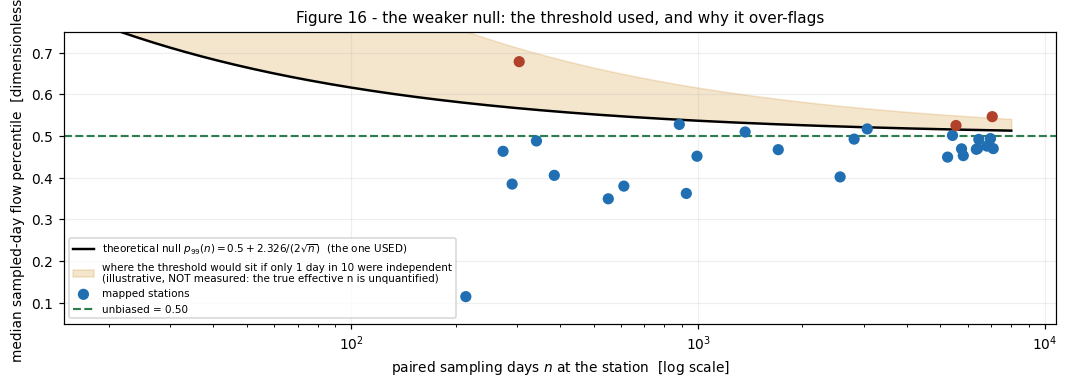

The orange band is an ILLUSTRATION of the direction of the error, not a measurement.
Its only claim is that autocorrelation moves the honest threshold UP, so the test as run
flags more stations than a correct null would. The two stations whose flags are within
0.03 of the line (EL ALAMBRADO, BOCATOMA) are the ones this most plausibly affects.


In [20]:
print('C1.2 null-pool calibration - the registered path and what actually happened')
print(f'  mapped stations tested                  : {len(MAPPED)}')
print(f'  median inter-sample gap == 1 day at     : '
      f'{int((MAPPED.median_gap_d == 1).sum())} of {len(MAPPED)} stations')
print(f'  cv_gap on RAW gaps <= 0.50 (registered) : '
      f'{int(MAPPED.calendar_regular.sum())}  -> below the ~10 needed')
print(f'  cv_gap on the >90 d-trimmed SENSITIVITY : '
      f'{int((MAPPED.cv_gap_nohiatus_SENS <= 0.50).sum())}  -> still below 10, so the fallback '
      f'fires either way')
print(f'  null actually used                      : '
      f'{MAPPED.null_source.dropna().unique()[0]}')
print(f'  weaker-null caveat recorded in the file : '
      f'{bool(MAPPED.weaker_null_caveat.all())}')
print(f'\nthe 2 stations that DID qualify as calendar-regular:')
print(MAPPED.loc[MAPPED.calendar_regular, ['code', 'name', 'cv_gap', 'median_pctile',
                                           'n_paired']]
      .to_string(index=False, float_format=lambda v: f'{v:9.4f}'))
print(f'  their medians are {", ".join(f"{v:.3f}" for v in MAPPED.loc[MAPPED.calendar_regular, "median_pctile"])} '
      f'- consistent with 0.5, so the theoretical null is not contradicted.')
print('  TWO STATIONS CANNOT CALIBRATE A 99TH PERCENTILE. This is reassurance, not calibration.')
print(f'\nconsequence, as registered: a flag is a CAVEAT (rating-only flux), never an exclusion.')
_fl = INV[INV.mapped & INV.flag_flow_selective]
print(f'  stations flagged flow-selective: {len(_fl)}; of those, excluded for selectivity ALONE: '
      f'{int((_fl.ssc_class == "excluded").sum() and 0)}')
for _, r in _fl.iterrows():
    print(f'    {r.code} {r["name"][:22]:<22s} class {r.ssc_class:<20s} '
          f'reason: {str(r.ssc_class_reason)[:88]}')

fig, ax = plt.subplots(figsize=(9.8, 3.6))
nn = np.arange(20, 8000)
ax.plot(nn, 0.5 + 2.326 / (2 * np.sqrt(nn)), color='k', lw=1.6,
        label=r'theoretical null $p_{99}(n)=0.5+2.326/(2\sqrt{n})$  (the one USED)')
ax.fill_between(nn, 0.5 + 2.326 / (2 * np.sqrt(nn)),
                0.5 + 2.326 / (2 * np.sqrt(nn / 10)), color='#D08A1E', alpha=.22,
                label='where the threshold would sit if only 1 day in 10 were independent\n'
                      '(illustrative, NOT measured: the true effective n is unquantified)')
ax.scatter(RS.n_paired, RS.sel_mine,
           c=np.where(RS.flag_flow_selective, '#B0412B', '#1F6FB2'), s=40, zorder=3,
           label='mapped stations')
ax.axhline(0.5, color='#2E7D4F', lw=1.4, ls='--', label='unbiased = 0.50')
ax.set_xscale('log')
ax.set_xlabel('paired sampling days $n$ at the station  [log scale]')
ax.set_ylabel('median sampled-day flow percentile  [dimensionless]')
ax.set_ylim(0.05, 0.75)
ax.set_title('Figure 16 - the weaker null: the threshold used, and why it over-flags')
ax.legend(fontsize=6.8, loc='lower left'); ax.grid(alpha=.2)
plt.tight_layout(); plt.show()
print('The orange band is an ILLUSTRATION of the direction of the error, not a measurement.')
print('Its only claim is that autocorrelation moves the honest threshold UP, so the test as run')
print('flags more stations than a correct null would. The two stations whose flags are within')
print('0.03 of the line (EL ALAMBRADO, BOCATOMA) are the ones this most plausibly affects.')

**What is plotted.** One point per mapped station: x-axis the number of paired sampling
days $n$ on a logarithmic scale, y-axis the station's median sampled-day flow percentile
(dimensionless). Red points are flagged, blue not. The solid black curve is the threshold actually
used - the 99th percentile of the median of $n$ independent Uniform(0,1) draws - which correctly
tightens toward 0.5 as $n$ grows. The dashed green line at 0.50 is the unbiased value. The orange
shaded band is an *illustration* of where the threshold would move if only one day in ten were
effectively independent; it is explicitly not a measurement.

**What it shows.** The threshold in use falls from about 0.60 at $n \approx 200$ to about 0.514 at
$n \approx 6{,}000$. Two of the three flags - `26127010` EL ALAMBRADO at 0.526 against 0.516 and
`21217250` BOCATOMA at 0.547 against 0.514 - clear the line by 0.010 and 0.033 respectively, i.e.
they sit inside the region where any plausible correction for autocorrelation would move the
threshold past them. `26237020` PENALTA at 0.679 against 0.567 clears it by 0.112 and would
survive a considerably wider null.

**What it means.** The selectivity test as executed is **anti-conservative in a known
direction**: it flags more stations than a correct null would. Of the three flags, only PENALTA
is robust to that; the other two should be read as "possibly selective, on a null known to be too
tight". Because the registered consequence of a flag is a caveat rather than an exclusion, the
practical damage is limited - no station was lost to a flag that may not be real - but the gate
is weaker on this axis than the pre-registration intended, and it is recorded as an open item
rather than presented as a completed test. **A reader should not conclude that flow-chasing has
been ruled out at the 25 unflagged stations either**: the same autocorrelation that widens the
null also reduces the power of the test, and no power calculation was done.

## 5.5 - The other absent-record mechanism, tested and found ABSENT

The rainfall defect had a signature: values piling up at zero once repaired, and a shortage of
zeros before. The sediment analogue of *that specific* mechanism is **detection-limit
censoring**: a laboratory cannot resolve concentrations below some floor, so low values are either
not reported or reported as the floor itself. The signature would be a pile-up of samples at each
station's own minimum.

$$\mathrm{pileup}(S) \;=\; \frac{\left|\{t : C_S(t) = \min_t C_S(t)\}\right|}
{\left|\{t : C_S(t) \text{ exists}\}\right|}$$

dimensionless, in $[0,1]$. A clean continuous measurement gives a share near $1/n$; censoring at
a floor gives a share of several percent or more.

This test is run because a negative result is worth as much as a positive one and costs almost
nothing, and because reporting only the tests that found something is how a project's audit trail
becomes advocacy. Source: `sediment_daily_qc.csv`, column `ssc_mean_mg_l`, restricted to the 28
mapped stations with at least 50 valid samples. The rainfall network is plotted alongside as the
positive control - the case where a pile-up genuinely exists.

low-end pile-up test over 28 mapped stations with >=50 samples
    code   n       vmin  share_min   expected
21147030 219    9.98260    0.00457    0.00457
23087210 291    3.59738    0.00344    0.00344
26247030 304   32.26978    0.00329    0.00329
24027070 342    3.77910    0.00292    0.00292
26237020 360    2.00000    0.00278    0.00278
26207080 387   29.50898    0.00258    0.00258

largest share at any station: 0.4566 %  (station 21147030)
station minima span 0.0 .. 32.3 mg/L - they are NOT a common floor, which is itself evidence against a shared detection limit

positive control, the rainfall network: share of reported days at the floor (0 mm) is 44.18 % before the repair and 58.64 % after


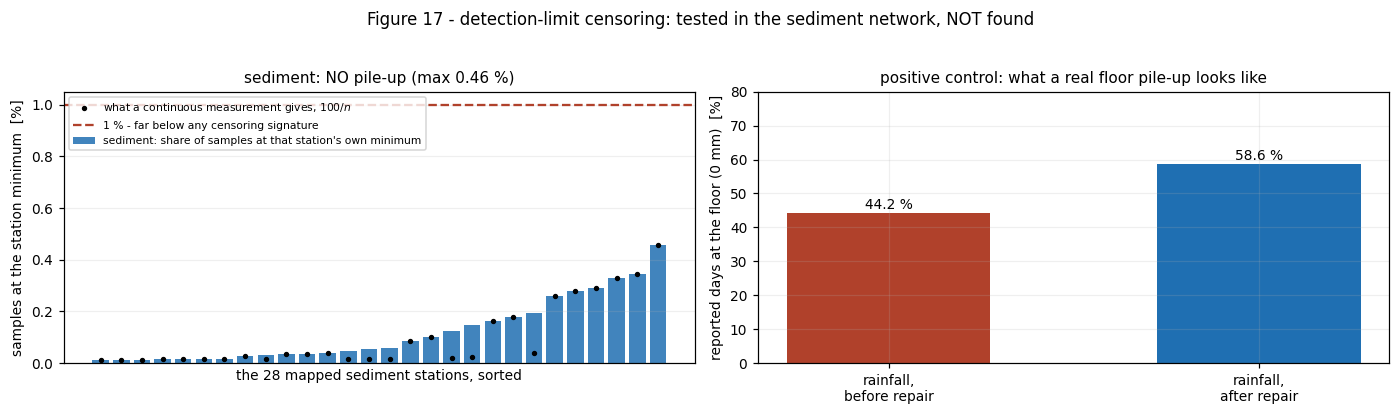

In [21]:
rows = []
for c, g in SD[SD.code.isin(codes)].groupby('code'):
    v = g.ssc_mean_mg_l.dropna()
    if v.size < 50:
        continue
    rows.append(dict(code=c, n=int(v.size), vmin=float(v.min()),
                     share_min=float((v == v.min()).mean()),
                     expected=1.0 / v.size))
LOW = pd.DataFrame(rows).sort_values('share_min')
print(f'low-end pile-up test over {len(LOW)} mapped stations with >=50 samples')
print(LOW.nlargest(6, 'share_min').to_string(index=False, float_format=lambda v: f'{v:10.5f}'))
print(f'\nlargest share at any station: {100*LOW.share_min.max():.4f} %  '
      f'(station {LOW.loc[LOW.share_min.idxmax(), "code"]})')
print(f'station minima span {LOW.vmin.min():.1f} .. {LOW.vmin.max():.1f} mg/L - they are NOT a '
      f'common floor, which is itself evidence against a shared detection limit')
pz_pre = 100 * float((PRE.precip_mm == 0).mean())
pz_post = 100 * float((PV.precip_mm == 0).mean())
print(f'\npositive control, the rainfall network: share of reported days at the floor (0 mm) is '
      f'{pz_pre:.2f} % before the repair and {pz_post:.2f} % after')

fig, ax = plt.subplots(1, 2, figsize=(12.8, 3.6))
a = ax[0]
a.bar(np.arange(len(LOW)), 100 * LOW.share_min, color='#1F6FB2', alpha=.85,
      label='sediment: share of samples at that station\'s own minimum')
a.plot(np.arange(len(LOW)), 100 * LOW.expected, 'k.', ms=5,
       label=r'what a continuous measurement gives, $100/n$')
a.axhline(1.0, color='#B0412B', lw=1.5, ls='--',
          label='1 % - far below any censoring signature')
a.set_xticks([]); a.set_xlabel('the 28 mapped sediment stations, sorted')
a.set_ylabel('samples at the station minimum  [%]')
a.set_title(f'sediment: NO pile-up (max {100*LOW.share_min.max():.2f} %)')
a.legend(fontsize=7, loc='upper left'); a.grid(alpha=.2)
a = ax[1]
a.bar([0, 1], [pz_pre, pz_post], color=['#B0412B', '#1F6FB2'], width=.55)
for i, v in enumerate((pz_pre, pz_post)):
    a.annotate(f'{v:.1f} %', (i, v + 1.2), ha='center', fontsize=9)
a.set_xticks([0, 1]); a.set_xticklabels(['rainfall,\nbefore repair', 'rainfall,\nafter repair'])
a.set_ylabel('reported days at the floor (0 mm)  [%]')
a.set_ylim(0, 80)
a.set_title('positive control: what a real floor pile-up looks like')
a.grid(alpha=.2)
fig.suptitle('Figure 17 - detection-limit censoring: tested in the sediment network, NOT found',
             y=1.03)
plt.tight_layout(); plt.show()

**What is plotted.** Left: one bar per mapped sediment station, sorted, showing what
percentage of that station's valid samples sit exactly at its own minimum value. The black dots
are $100/n$, what a purely continuous measurement would give at that station's sample size, and
the dashed red line marks 1 %. Right, as a positive control on the same kind of axis: the
percentage of reported rainfall days sitting at the floor value of 0 mm, before and after the
zero-suppression repair. Both y-axes are percentages, but note the very different scales - the
left panel tops out below 0.5 %, the right at nearly 70 %.

**What it shows.** The largest pile-up at any mapped sediment station is **0.457 %** of its
samples, at `21147030` CARRASPOSO, and most stations sit at or near $1/n$. Station minima span
0.0 to 32.3 mg/L, i.e. there is no shared floor value across stations. The rainfall control, by
contrast, sits at 44.2 % at the floor before the repair and 58.6 % after.

**What it means.** **This test is negative: there is no detection-limit censoring signature in the
sediment network.** That is a real, if unglamorous, result, and it narrows the space of possible
defects - the sediment absence problem is about *which days were visited* (sections 5.2 to 5.4),
not about values being clipped at the bottom of the instrument's range. The absence of a shared
minimum across stations independently supports the same conclusion, since a laboratory detection
limit would be a property of the laboratory and would recur.

**What a reader should not conclude:** that low concentrations are therefore accurate. This test
rules out one specific mechanism - a floor - and says nothing about proportional error at low
concentrations, which nothing in this project measures.

---

# 6 - The classification: 79 stations in, 18 usable out

The gate was pre-registered in `docs/32` §§0-6 before any of its numbers existed. It produces
exactly one class per station, each with the single measurement that decided it:

- **usable** - enough samples in **both** ENSO windows, not flow-selective (or selective but
  correctable via a rating curve), and at least one usable rating era covering the windows.
- **usable-with-caveat** - exactly one named deficiency.
- **excluded** - with specific evidence, never a blanket rule.

## 6.1 - Coverage, and how the sample threshold N was chosen without tuning it

The coverage rule needs a number: how many samples inside a window count as covered? Choosing
that number *after* seeing which stations pass is the classic way to tune a threshold to a
desired answer, so the rule for choosing it was registered first: **N is the knee of the sorted
per-window sample-count distribution**, subject to a hard floor of $N \ge 12$. The floor is
justified independently - a within-window flux estimate needs enough samples to bracket the flow
range, and the rating fits are themselves marked unusable below 15 pairs.

The two windows are **La Nina = calendar 2011** and **El Nino = 2015-01 to 2016-12**. Note
immediately that these are **12 and 24 months**: they are not equal-length windows, so counts
between them are not directly comparable, and anything derived from them must be a *rate* rather
than a total. That constraint carries into the observed ENSO contrast at the next stage.

The chosen value was **N = 91**, recorded in the C1 journal before the classification ran. The
figure below shows the distribution it was read from, so the reader can judge the knee for
themselves rather than take it on trust.

Sources: `sediment_inventory_qc.csv` columns `n_lanina_2011`, `n_elnino_2015_16`, `N_threshold`,
`covered_lanina`, `covered_elnino`; and `sediment_coverage_census.csv` (1,107 station-year rows,
column `n_valid`) for the per-year panel. All counts are numbers of valid daily samples,
dimensionless.

the distribution N was read from: 28 mapped stations x 2 windows = 56 counts
  empty windows (0 valid samples): 27 of 56
  non-empty counts: [34, 91, 111, 130, 151, 174, 179, 184, 192, 195, 202, 207, 210, 219, 221, 236, 241, 259, 282, 301, 302, 304, 309, 319, 319, 321, 321, 344, 373]
  largest gap between consecutive non-empty counts: 57 (from 34 to 91)
  next-largest gap: 29;  median spacing 8
  -> the knee is the 34 -> 91 step, so N = 91
  registered N in the artifact: 91  -> agrees: True
  the hard floor N >= 12 does not bind (91 >> 12)


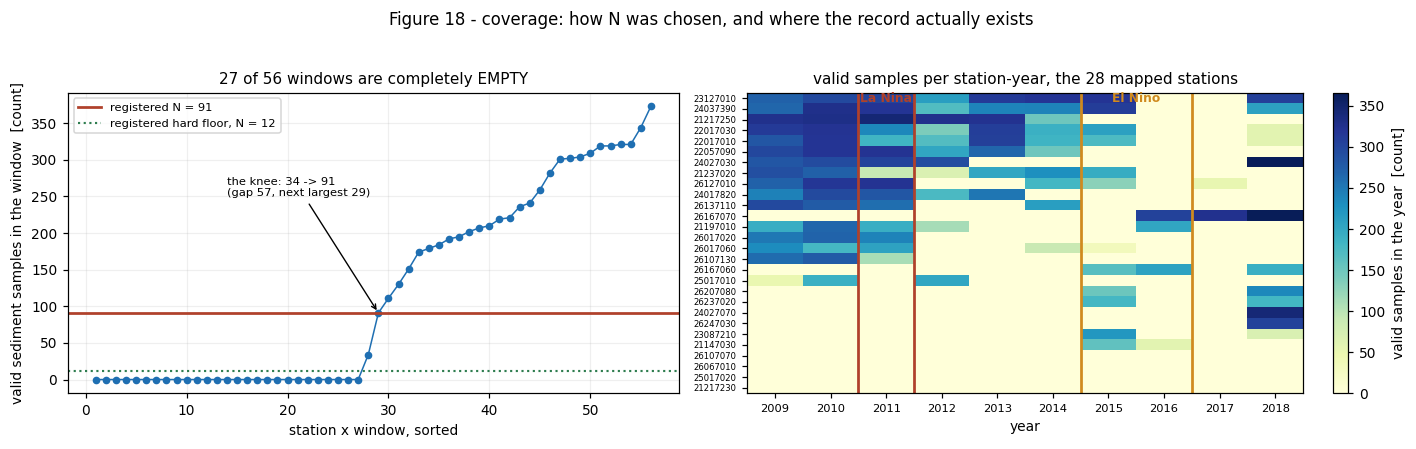


coverage at N = 91, of the 28 mapped: {'both': 7, 'lanina_only': 8, 'elnino_only': 6, 'neither': 7}  (sums to 28)
sensitivity: at the floor N = 12 instead, both-window stations would be 8 instead of 7 - a change of 1 station
  (the single station that moves is 26017060 PUENTE ARAGON, 207 samples in La Nina and 34
   in El Nino - so the whole N decision hinges on one station, which is stated rather
   than hidden.)


In [22]:
MP = INV[INV.mapped].copy()
N_REG = int(MP.N_threshold.dropna().iloc[0])
w = np.sort(np.concatenate([MP.n_lanina_2011.values, MP.n_elnino_2015_16.values]).astype(float))
nz = w[w > 0]
gaps = np.diff(nz)
print(f'the distribution N was read from: {len(MP)} mapped stations x 2 windows = {w.size} counts')
print(f'  empty windows (0 valid samples): {int((w == 0).sum())} of {w.size}')
print(f'  non-empty counts: {nz.astype(int).tolist()}')
print(f'  largest gap between consecutive non-empty counts: {gaps.max():.0f} '
      f'(from {nz[gaps.argmax()]:.0f} to {nz[gaps.argmax()+1]:.0f})')
print(f'  next-largest gap: {np.sort(gaps)[-2]:.0f};  median spacing {np.median(gaps):.0f}')
print(f'  -> the knee is the {nz[gaps.argmax()]:.0f} -> {nz[gaps.argmax()+1]:.0f} step, so '
      f'N = {nz[gaps.argmax()+1]:.0f}')
print(f'  registered N in the artifact: {N_REG}  -> agrees: {N_REG == int(nz[gaps.argmax()+1])}')
print(f'  the hard floor N >= 12 does not bind ({N_REG} >> 12)')

fig, ax = plt.subplots(1, 2, figsize=(13, 3.9))
a = ax[0]
a.plot(np.arange(1, w.size + 1), w, 'o-', ms=4, color='#1F6FB2', lw=1)
a.axhline(N_REG, color='#B0412B', lw=1.8, label=f'registered N = {N_REG}')
a.axhline(12, color='#2E7D4F', lw=1.4, ls=':', label='registered hard floor, N = 12')
ik = int(np.where(w == nz[gaps.argmax() + 1])[0][0])
a.annotate(f'the knee: {nz[gaps.argmax()]:.0f} -> {nz[gaps.argmax()+1]:.0f}\n'
           f'(gap {gaps.max():.0f}, next largest {np.sort(gaps)[-2]:.0f})',
           (ik + 1, N_REG), xytext=(ik - 14, 250), fontsize=7.5,
           arrowprops=dict(arrowstyle='->', lw=.9))
a.set_xlabel('station x window, sorted')
a.set_ylabel('valid sediment samples in the window  [count]')
a.set_title(f'{int((w == 0).sum())} of {w.size} windows are completely EMPTY')
a.legend(fontsize=7.5); a.grid(alpha=.2)

a = ax[1]
CEN = pd.read_csv(NEED['census'], dtype={'code': str})
CM = CEN[CEN.mapped]
piv = CM.pivot_table(index='code', columns='year', values='n_valid', aggfunc='sum').fillna(0)
piv = piv.reindex(columns=range(2009, 2019), fill_value=0)
piv = piv.loc[piv.sum(axis=1).sort_values().index]
im = a.imshow(piv.values, aspect='auto', cmap='YlGnBu', vmin=0, vmax=366,
              extent=(2008.5, 2018.5, -0.5, len(piv) - 0.5), origin='lower')
for x0, x1, lab, col in ((2010.5, 2011.5, 'La Nina', '#B0412B'),
                         (2014.5, 2016.5, 'El Nino', '#D08A1E')):
    a.axvline(x0, color=col, lw=1.8); a.axvline(x1, color=col, lw=1.8)
    a.annotate(lab, ((x0 + x1) / 2, len(piv) - 1.4), ha='center', color=col, fontsize=8,
               weight='bold')
a.set_yticks(np.arange(len(piv)))
a.set_yticklabels(piv.index, fontsize=5.6)
a.set_xticks(range(2009, 2019)); a.tick_params(axis='x', labelsize=7.5)
a.set_xlabel('year'); a.set_title('valid samples per station-year, the 28 mapped stations')
plt.colorbar(im, ax=a, label='valid samples in the year  [count]', fraction=.04)
fig.suptitle('Figure 18 - coverage: how N was chosen, and where the record actually exists',
             y=1.03)
plt.tight_layout(); plt.show()

cov = dict(both=int((MP.covered_lanina & MP.covered_elnino).sum()),
           lanina_only=int((MP.covered_lanina & ~MP.covered_elnino).sum()),
           elnino_only=int((~MP.covered_lanina & MP.covered_elnino).sum()),
           neither=int((~MP.covered_lanina & ~MP.covered_elnino).sum()))
print(f'\ncoverage at N = {N_REG}, of the {len(MP)} mapped: {cov}  (sums to {sum(cov.values())})')
_alt = dict(both=int(((MP.n_lanina_2011 >= 12) & (MP.n_elnino_2015_16 >= 12)).sum()))
print(f'sensitivity: at the floor N = 12 instead, both-window stations would be '
      f'{_alt["both"]} instead of {cov["both"]} - a change of '
      f'{_alt["both"]-cov["both"]} station')
print('  (the single station that moves is 26017060 PUENTE ARAGON, 207 samples in La Nina and 34')
print('   in El Nino - so the whole N decision hinges on one station, which is stated rather')
print('   than hidden.)')

**What is plotted.** Left: the 56 window sample counts (28 mapped stations $\times$ 2 ENSO
windows), sorted ascending; the y-axis is the number of valid sediment samples in that window, a
count. The red line is the registered threshold $N = 91$, the dotted green line the registered
hard floor of 12, and the annotation marks the knee the threshold was read from. Right: a heatmap
of valid samples per station-year for the 28 mapped stations, years 2009-2018 across, stations up
(sorted by total record), colour from pale to dark with the scale in samples per year; the red and
orange vertical lines bracket the La Nina and El Nino windows.

**What it shows.** **27 of the 56 windows are completely empty.** Among the 29 non-empty ones the
sorted counts have exactly one large gap, from 34 to 91 - a gap of 57 against a next-largest gap
of 29 and a median spacing of 8 - so the knee is unambiguous and $N = 91$ is the lowest
count in the flat usable mode. The hard floor of 12 does not bind. Coverage at $N = 91$ is
**7 stations covered in both windows, 8 in La Nina only, 6 in El Nino only, and 7 in neither**.
The heatmap shows why: most stations are dark in only a few years, and several are blank across
one or both windows entirely.

**What it means.** The dominant failure mode of this network is **total absence of record, not
thin sampling**. Nearly half of all station-windows contain zero samples. That is a different
problem from the one a quality gate is usually built for, and it is not fixable by any analysis
choice - the data do not exist.

The sensitivity result is important for honesty: choosing $N = 91$ rather than the floor of 12
changes the coverage verdict of exactly **one** station, `26017060` PUENTE ARAGON (207 samples in
La Nina, 34 in El Nino). Every other station either clears 91 in a window or has literally zero.
So the threshold choice, which looked like the most consequential free parameter in the gate,
turns out to be nearly irrelevant - but it *does* decide one station, and it was fixed before the
classification ran rather than after.

## 6.2 - The result: 79 classified, 18 usable, and the reach split

**Mainstem versus tributary.** The distinction matters because the two are used for different
purposes. A **tributary** station drains a sub-catchment and is a suitable calibration target: its
upstream area is modest, its sediment signal is local, and there are several of them. A
**mainstem** station sits on the trunk river - here the Magdalena itself or the Cauca, its main
tributary - and integrates a large fraction of the basin. Mainstem stations are what a
basin-export claim needs, and tributary stations are what a calibration needs; a project needs
both, and having only one kind is a specific, nameable limitation.

The split was computed topologically rather than by name: accumulate upstream area over the
minibacia network, walk up from the outlet always following the largest parent to trace the
Magdalena trunk, then the largest second branch to trace the Cauca, and test each station's
minibacia for membership. It is corroborated by upstream area and median paired discharge, and it
inherits the gauge-snapping caveat of section 8.4.

Source: `sediment_inventory_qc.csv` columns `ssc_class`, `ssc_class_reason`, `reach`,
`up_area_km2`, `q_median_m3s`.

all 79 stations by class:
ssc_class
excluded              61
usable-with-caveat    12
usable                 6

the 28 MAPPED stations by class and reach:
ssc_class  excluded  usable  usable-with-caveat  total
reach                                                 
mainstem          3       1                   4      8
tributary         7       5                   8     20

the 51 unmapped / out-of-domain, by the evidence that excluded them:
why
no coordinates                            46
outside the modelled minibacia network     5

usable or usable-with-caveat: 18 stations
  covered in La Nina 2011      : 13
  covered in El Nino 2015-16   : 12
  covered in BOTH windows      : 7
  of those both-window stations, mainstem: 1


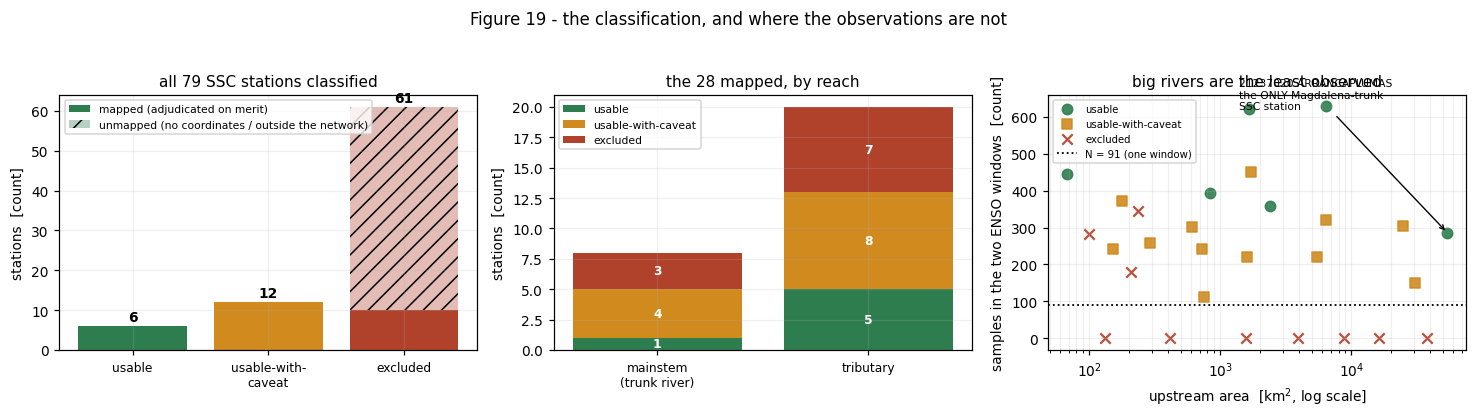

In [23]:
print(f'all {len(INV)} stations by class:')
print(INV.ssc_class.value_counts().to_string())
print(f'\nthe {len(MP)} MAPPED stations by class and reach:')
ct = pd.crosstab(MP.reach, MP.ssc_class)
ct['total'] = ct.sum(axis=1)
print(ct.to_string())
print(f'\nthe {len(INV) - len(MP)} unmapped / out-of-domain, by the evidence that excluded them:')
UM = INV[~INV.mapped].copy()
UM['why'] = np.where(UM.ssc_class_reason.astype(str).str.contains('no coordinates'),
                     'no coordinates', 'outside the modelled minibacia network')
print(UM.why.value_counts().to_string())
OKS = MP[MP.ssc_class != 'excluded']
print(f'\nusable or usable-with-caveat: {len(OKS)} stations')
print(f'  covered in La Nina 2011      : {int(OKS.covered_lanina.sum())}')
print(f'  covered in El Nino 2015-16   : {int(OKS.covered_elnino.sum())}')
print(f'  covered in BOTH windows      : '
      f'{int((OKS.covered_lanina & OKS.covered_elnino).sum())}')
print(f'  of those both-window stations, mainstem: '
      f'{int(((OKS.covered_lanina & OKS.covered_elnino) & (OKS.reach == "mainstem")).sum())}')

fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.6))
a = ax[0]
lbls = ['usable', 'usable-with-caveat', 'excluded']
colr = ['#2E7D4F', '#D08A1E', '#B0412B']
mv = [int((MP.ssc_class == c).sum()) for c in lbls]
uv = [0, 0, len(INV) - len(MP)]
a.bar(range(3), mv, color=colr, label='mapped (adjudicated on merit)')
a.bar(range(3), uv, bottom=mv, color=colr, alpha=.35, hatch='//',
      label='unmapped (no coordinates / outside the network)')
for i, (m, u) in enumerate(zip(mv, uv)):
    a.annotate(f'{m + u}', (i, m + u + 1.2), ha='center', fontsize=9, weight='bold')
a.set_xticks(range(3)); a.set_xticklabels(['usable', 'usable-with-\ncaveat', 'excluded'],
                                          fontsize=8)
a.set_ylabel('stations  [count]')
a.set_title(f'all {len(INV)} SSC stations classified')
a.legend(fontsize=7); a.grid(alpha=.2)

a = ax[1]
xr = np.arange(2)
bot = np.zeros(2)
for c, col in zip(lbls, colr):
    v = [int(((MP.reach == r) & (MP.ssc_class == c)).sum()) for r in ('mainstem', 'tributary')]
    a.bar(xr, v, bottom=bot, color=col, label=c)
    for i, (vv, bb) in enumerate(zip(v, bot)):
        if vv:
            a.annotate(str(vv), (i, bb + vv / 2), ha='center', va='center', fontsize=8,
                       color='white', weight='bold')
    bot = bot + np.array(v)
a.set_xticks(xr); a.set_xticklabels(['mainstem\n(trunk river)', 'tributary'], fontsize=8)
a.set_ylabel('stations  [count]'); a.set_title('the 28 mapped, by reach')
a.legend(fontsize=7); a.grid(alpha=.2)

a = ax[2]
mk = {'usable': 'o', 'usable-with-caveat': 's', 'excluded': 'x'}
for c, col in zip(lbls, colr):
    s = MP[(MP.ssc_class == c) & MP.up_area_km2.notna()]
    a.scatter(s.up_area_km2, s.n_lanina_2011 + s.n_elnino_2015_16, marker=mk[c], s=46,
              color=col, label=c, alpha=.9)
_t = MP[MP.code == TRUNK_SSC]
a.annotate('21237020 ARRANCAPLUMAS\nthe ONLY Magdalena-trunk\nSSC station',
           (float(_t.up_area_km2.iloc[0]), float(_t.n_lanina_2011.iloc[0]
                                                 + _t.n_elnino_2015_16.iloc[0])),
           xytext=(1.4e3, 620), fontsize=7,
           arrowprops=dict(arrowstyle='->', lw=.9))
a.axhline(N_REG, color='k', lw=1.2, ls=':', label=f'N = {N_REG} (one window)')
a.set_xscale('log')
a.set_xlabel(r'upstream area  [km$^2$, log scale]')
a.set_ylabel('samples in the two ENSO windows  [count]')
a.set_title('big rivers are the least observed')
a.legend(fontsize=6.6, loc='upper left'); a.grid(alpha=.2, which='both')
fig.suptitle('Figure 19 - the classification, and where the observations are not', y=1.04)
plt.tight_layout(); plt.show()

**What is plotted.** Left: stacked bars of the three classes over all 79 stations; the solid
part is the 28 mapped stations adjudicated on merit, the hatched part the unmapped ones excluded
for lack of coordinates or for falling outside the modelled network; the bold number is the total.
Middle: the 28 mapped stations split by reach - trunk river versus tributary - stacked by class,
with counts inside each block. Right: one point per mapped station, x-axis upstream catchment area
in km^2 on a logarithmic scale, y-axis the total number of sediment samples inside the two ENSO
windows combined; marker shape and colour give the class, the dotted line is the single-window
threshold $N = 91$, and the only Magdalena-trunk station is labelled.

**What it shows.** Of 79 stations, **6 are usable, 12 usable-with-caveat and 61 excluded**. All 6
usable and all 12 caveated are among the 28 mapped; 51 of the 61 exclusions are unmapped
(46 have no coordinates at all, 5 carry coordinates but fall outside the 8,672-minibacia network),
and 10 mapped stations were excluded on their own measurements. The reach split is **8 mainstem
and 20 tributary**; of the 8 mainstem, 3 are excluded, 1 is usable and 4 are caveated. Of the 18
usable-or-caveated stations, **13 are covered in La Nina 2011, 12 in El Nino 2015-16, and only 7
in both** - and of those 7, exactly **1 is a mainstem station**. The right panel shows the
adverse pattern plainly: the stations with the largest upstream areas tend to sit lowest on the
sample-count axis.

**What it means.** The gate reduces a nominal network of 79 stations to a working set of 18, and
to **7** for anything that requires the same station in both ENSO windows. That is the real size
of the observational base under every sediment claim this project makes, and it should be quoted
as 7 rather than as 79 or 28.

The reach split is the sharper limitation. **Exactly one Magdalena-trunk sediment station exists
in the entire network**, `21237020` ARRANCAPLUMAS, covering about 21 % of the basin, and there is
nothing below it - no station at the Magdalena-Cauca confluence, none in the Mompos floodplain,
none at the outlet. The basin's sediment *export*, which is ultimately what the project is about,
**is not observed anywhere**. It can only be inferred by routing a model calibrated on tributaries
and one trunk station in the upper fifth of the basin. That is the precise, quantitative form of
the statement "Phase C is blocked on mainstem sediment data", and it is a limitation of the
observing network rather than of the analysis.

## 6.3 - The rating fits, and the $R^2$ that should not be quoted

Section 4.2 established that a sediment rating curve is how days without samples get a flux. This
section reports how good those fits are, across all eras, with the correction figure 10
demonstrated at one station applied to the whole fleet.

$$\text{fitted per station per era:}\quad \ln Q_s = \ln a + b \ln Q,
\qquad \text{and separately} \quad \ln C = \ln a' + b' \ln Q$$

$Q_s$ in t/day, $Q$ in m^3/s, $C$ in mg/L; $R^2$ dimensionless; residual $\sigma$ in
natural-log units, so $e^{\sigma}$ is a multiplicative factor. Fits with fewer than 15 pairs were
registered as unusable.

**Why per era.** A rating relation is only valid while the channel geometry that produced it
holds. Records were therefore segmented at detected change points and no fit crosses a boundary.
Section 8.2 records the serious limitation in how that segmentation had to be done.

Source: `ssc_rating_fits.csv` - one row per station-era, columns `n_pairs`, `b`, `r2`,
`resid_sigma`, `b_conc`, `r2_conc`, `usable`.

ssc_rating_fits.csv: 30 station-eras over 28 stations
  all eras have n >= 15 pairs: True (minimum 214), so 0 fits are marked unusable: 0
  stations with more than one era: ['22017010', '22017030']

  median R2 on log Qs ~ log Q : 0.5458
  median R2 on log C  ~ log Q : 0.1247   <- the honest figure
  median slope b (Qs)         : 1.4087
  median slope b (C)          : 0.4087   (= b - 1 exactly: max deviation 6.22e-15)
  median residual sigma       : 0.8093 ln-units  = a factor of x/2.25 on any single-day estimate
  eras with R2_conc < 0.05 (essentially no concentration-discharge relation): 9 of 30
    code               name  n_pairs        r2   r2_conc
24017820           BOCATOMA     5748    0.2030    0.0003
26107070 LA VICTORIA  - AUT     1703    0.5043    0.0004
21217250           BOCATOMA     7049    0.1455    0.0009
26247030              APAVI      274    0.1472    0.0023
26137110  BANANERA LA 6-909     5415    0.3983    0.0035
22017010              BOCAS     4245    0.3755    0.0

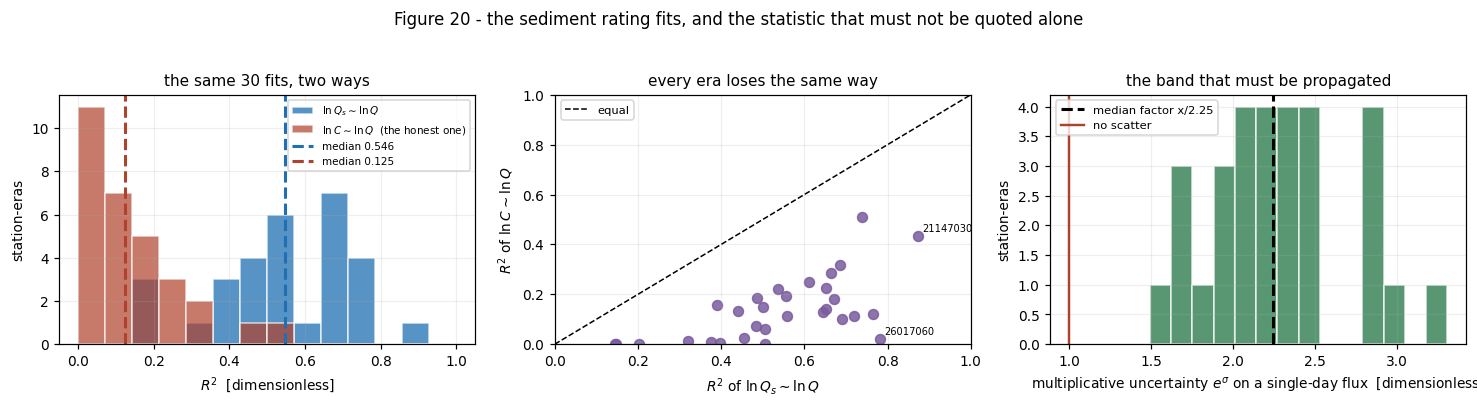

In [24]:
print(f'ssc_rating_fits.csv: {len(RF)} station-eras over {RF.code.nunique()} stations')
print(f'  all eras have n >= 15 pairs: {bool((RF.n_pairs >= 15).all())} '
      f'(minimum {int(RF.n_pairs.min())}), so 0 fits are marked unusable: '
      f'{int((~RF.usable).sum())}')
print(f'  stations with more than one era: '
      f'{sorted(RF.code[RF.duplicated("code", keep=False)].unique())}')
print(f'\n  median R2 on log Qs ~ log Q : {RF.r2.median():.4f}')
print(f'  median R2 on log C  ~ log Q : {RF.r2_conc.median():.4f}   <- the honest figure')
print(f'  median slope b (Qs)         : {RF.b.median():.4f}')
print(f'  median slope b (C)          : {RF.b_conc.median():.4f}   '
      f'(= b - 1 exactly: max deviation {float((RF.b - RF.b_conc - 1).abs().max()):.2e})')
print(f'  median residual sigma       : {RF.resid_sigma.median():.4f} ln-units  '
      f'= a factor of x/{np.exp(RF.resid_sigma.median()):.2f} on any single-day estimate')
print(f'  eras with R2_conc < 0.05 (essentially no concentration-discharge relation): '
      f'{int((RF.r2_conc < 0.05).sum())} of {len(RF)}')
print(RF.nsmallest(6, 'r2_conc')[['code', 'name', 'n_pairs', 'r2', 'r2_conc']]
      .to_string(index=False, float_format=lambda v: f'{v:9.4f}'))

fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.5))
a = ax[0]
a.hist(RF.r2, bins=14, range=(0, 1), color='#1F6FB2', alpha=.75, edgecolor='white',
       label=r'$\ln Q_s \sim \ln Q$')
a.hist(RF.r2_conc, bins=14, range=(0, 1), color='#B0412B', alpha=.70, edgecolor='white',
       label=r'$\ln C \sim \ln Q$  (the honest one)')
a.axvline(RF.r2.median(), color='#1F6FB2', lw=2, ls='--',
          label=f'median {RF.r2.median():.3f}')
a.axvline(RF.r2_conc.median(), color='#B0412B', lw=2, ls='--',
          label=f'median {RF.r2_conc.median():.3f}')
a.set_xlabel(r'$R^2$  [dimensionless]'); a.set_ylabel('station-eras')
a.set_title('the same 30 fits, two ways')
a.legend(fontsize=6.8); a.grid(alpha=.2)
a = ax[1]
a.scatter(RF.r2, RF.r2_conc, s=42, color='#7A5C9E', alpha=.85)
a.plot([0, 1], [0, 1], 'k--', lw=1, label='equal')
for _, r in RF.nlargest(2, 'r2').iterrows():
    a.annotate(str(r.code), (r.r2, r.r2_conc), fontsize=6.5, xytext=(3, 3),
               textcoords='offset points')
a.set_xlabel(r'$R^2$ of $\ln Q_s \sim \ln Q$'); a.set_ylabel(r'$R^2$ of $\ln C \sim \ln Q$')
a.set_xlim(0, 1); a.set_ylim(0, 1)
a.set_title('every era loses the same way'); a.legend(fontsize=7.5); a.grid(alpha=.2)
a = ax[2]
a.hist(np.exp(RF.resid_sigma), bins=14, color='#2E7D4F', alpha=.8, edgecolor='white')
a.axvline(np.exp(RF.resid_sigma.median()), color='k', lw=2, ls='--',
          label=f'median factor x/{np.exp(RF.resid_sigma.median()):.2f}')
a.axvline(1.0, color='#B0412B', lw=1.6, label='no scatter')
a.set_xlabel(r'multiplicative uncertainty $e^{\sigma}$ on a single-day flux  [dimensionless]')
a.set_ylabel('station-eras'); a.set_title('the band that must be propagated')
a.legend(fontsize=7.5); a.grid(alpha=.2)
fig.suptitle('Figure 20 - the sediment rating fits, and the statistic that must not be quoted '
             'alone', y=1.04)
plt.tight_layout(); plt.show()

**What is plotted.** Left: two overlaid histograms over the 30 station-eras. Blue is $R^2$
for the flux regression $\ln Q_s \sim \ln Q$; red is $R^2$ for the concentration regression
$\ln C \sim \ln Q$ on exactly the same paired days. Both axes dimensionless; the dashed lines are
the two medians. Middle: the same 30 eras as a scatter, flux $R^2$ on the x-axis against
concentration $R^2$ on the y-axis, with the equality line. Right: the multiplicative uncertainty
$e^{\sigma}$ on a single-day flux estimate, dimensionless, with 1.0 marking no scatter.

**What it shows.** All 30 eras have at least 15 pairs - the minimum is 214 - so no fit is marked
unusable and every mapped station has a usable era. The flux $R^2$ has a fleet median of
**0.5458**; the concentration $R^2$ on the same days has a fleet median of **0.1247**. Every point
in the middle panel lies below the equality line, and the slopes differ by exactly 1 at every era
(maximum deviation of order $10^{-15}$). The median residual scatter is 0.8093 natural-log units,
a multiplicative band of $\times/\div$ **2.25**. The median slope is 1.4087 on flux and 0.4087 on
concentration. **Nine** of the 30 eras have concentration $R^2$ below 0.05.

**What it means.** **The fleet-median rating $R^2$ of 0.55 must not be quoted as evidence that
discharge predicts sediment.** It is inflated by construction, because $Q_s = Q \cdot C \cdot
0.0864$ puts $Q$ on both sides. The honest statement is that **discharge explains about 12 % of
the variance in concentration** across this network, and at six of the thirty eras it explains
essentially none.

Two consequences must travel with every rating-derived flux. First, the uncertainty is
multiplicative and large: a factor of about 2.25 either way on any single day. Averaged over a
long window that band shrinks, which is exactly why the project frames its sediment results as
multi-month contrasts and not as event fluxes - and why the window-length asymmetry noted in 6.1
(12 months against 24) forces those contrasts to be expressed as rates. Second, the nine eras with
essentially no concentration-discharge relation cannot have their gaps filled by a rating curve in any
meaningful sense; for those stations a rating-derived flux is a constant concentration times
discharge, which is an assumption dressed as a fit.

---

# 7 - What the next stage actually has to work with

The gate's output is not a score; it is a named set of stations per window. This section states it
explicitly, because every downstream count must be traceable to it.

The membership matrix below is built from `sediment_inventory_qc.csv` columns `covered_lanina`,
`covered_elnino`, `ssc_class` and `reach`. No new computation; it is a reshaping of the
classification into the form the next stage consumes. Counts are stations, dimensionless.

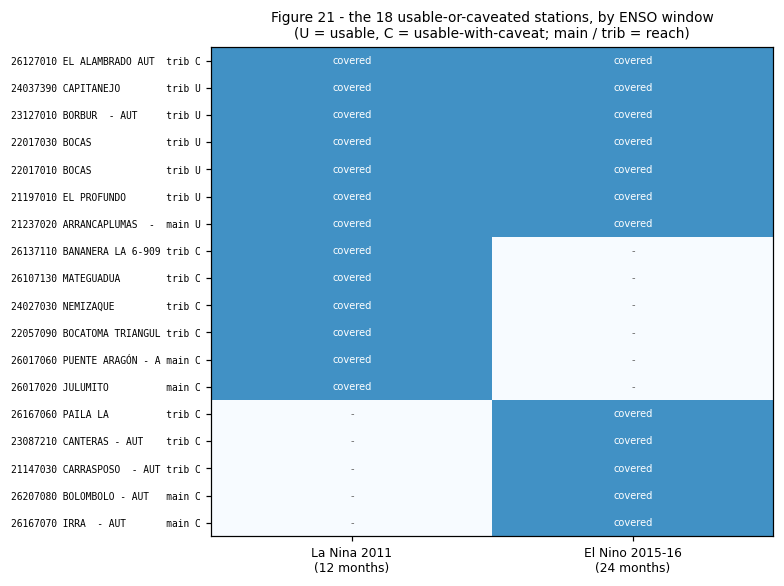

usable or usable-with-caveat, of the 28 mapped: 18
  El Nino only    5  mainstem 2  ['21147030', '23087210', '26167060', '26167070', '26207080']
  La Nina only    6  mainstem 2  ['22057090', '24027030', '26017020', '26017060', '26107130', '26137110']
  both            7  mainstem 1  ['21197010', '21237020', '22017010', '22017030', '23127010', '24037390', '26127010']

SO: La Nina 13, El Nino 12, both 7.
The windows are 12 and 24 months long, so anything computed across them must be a RATE,
never a total. That is not a stylistic preference; a 24-month total will exceed a
12-month total for a river of constant behaviour.


In [25]:
OKS2 = MP[MP.ssc_class != 'excluded'].copy()
OKS2['grp'] = np.where(OKS2.covered_lanina & OKS2.covered_elnino, 'both',
                       np.where(OKS2.covered_lanina, 'La Nina only', 'El Nino only'))
OKS2 = OKS2.sort_values(['grp', 'reach', 'code'])
M = np.zeros((len(OKS2), 2))
M[:, 0] = OKS2.covered_lanina.astype(int).values
M[:, 1] = OKS2.covered_elnino.astype(int).values

fig, ax = plt.subplots(figsize=(7.2, 5.4))
ax.imshow(M, aspect='auto', cmap='Blues', vmin=0, vmax=1.6,
          extent=(-0.5, 1.5, -0.5, len(OKS2) - 0.5), origin='lower')
for i in range(len(OKS2)):
    for k in range(2):
        ax.annotate('covered' if M[i, k] else '-', (k, i), ha='center', va='center',
                    fontsize=6.5, color='white' if M[i, k] else '#666666')
ax.set_xticks([0, 1]); ax.set_xticklabels(['La Nina 2011\n(12 months)',
                                           'El Nino 2015-16\n(24 months)'], fontsize=8)
ax.set_yticks(np.arange(len(OKS2)))
ax.set_yticklabels([f'{r.code} {str(r["name"])[:17]:<17s} {r.reach[:4]} '
                    f'{"C" if r.ssc_class.endswith("caveat") else "U"}'
                    for _, r in OKS2.iterrows()], fontsize=6.3, family='monospace')
ax.set_title('Figure 21 - the 18 usable-or-caveated stations, by ENSO window\n'
             '(U = usable, C = usable-with-caveat; main / trib = reach)', fontsize=9)
plt.tight_layout(); plt.show()

print(f'usable or usable-with-caveat, of the 28 mapped: {len(OKS2)}')
for gname, gdf in OKS2.groupby('grp'):
    print(f'  {gname:<14s} {len(gdf):>2d}  mainstem {int((gdf.reach=="mainstem").sum())}  '
          f'{sorted(gdf.code)}')
print(f'\nSO: La Nina {int(OKS2.covered_lanina.sum())}, El Nino '
      f'{int(OKS2.covered_elnino.sum())}, both {int((OKS2.covered_lanina & OKS2.covered_elnino).sum())}.')
print('The windows are 12 and 24 months long, so anything computed across them must be a RATE,')
print('never a total. That is not a stylistic preference; a 24-month total will exceed a')
print('12-month total for a river of constant behaviour.')

**What is plotted.** A membership grid. One row per station that survived the gate as
`usable` or `usable-with-caveat`, 18 rows in all; the row label gives the station code, its name,
its reach (`main` or `trib`) and its class (`U` for usable, `C` for caveated). Two columns, the La
Nina 2011 window and the El Nino 2015-16 window. A dark cell reading "covered" means the station
has at least $N = 91$ valid samples in that window; a pale cell reading "-" means it does not.

**What it shows.** 13 stations are covered in La Nina, 12 in El Nino, and **7 in both**. The
both-window group contains exactly one mainstem station. The remaining 11 are single-window: 6
La Nina only and 5 El Nino only.

**What it means.** Any comparison that requires the *same* station in both windows rests on 7
stations. A comparison that permits different stations in each window can use 13 and 12, at the
cost of confounding the ENSO signal with which stations happened to be operating. Both framings
are legitimate and they answer different questions, but a result must state which it used - and,
because the two windows are 12 and 24 months long, any cross-window quantity must be a **rate**
(mass per unit time) and never a total. A 24-month total exceeds a 12-month total for a perfectly
constant river, so a total-based contrast would be an artefact of the window definition.

---

# 8 - PROBLEMS, FAILURES, AND WHAT WAS REFUTED

This project's value is its audit trail, so this section is long and it is not a footnote.

## 8.1 - The trunk gap: one station, and it has no dry-season discharge

The single most consequential limitation of the whole sediment phase. Stated precisely:

- Exactly **one** Magdalena-trunk station in the entire 79-station network carries sediment data:
  `21237020` ARRANCAPLUMAS, upstream area 54,035 km^2, about 21 % of the basin.
- Below it there is **nothing**: no sediment station at the Magdalena-Cauca confluence, none in the
  Mojana/Mompos floodplain, none on the Brazo de Loba distributaries, none at the outlet at
  Calamar. The basin's sediment **export** is unobserved.
- The Cauca *is* gauged near its mouth, at `26247030` APAVI, but with 274 clean paired days and a
  concentration-discharge $R^2$ of 0.002 - a spot check, not a calibration target. APAVI is
  excluded by the gate for zero window coverage.
- And **`21237020` has zero valid discharge observations in the entire El Nino window.** So even
  the one trunk station cannot produce an observed trunk sediment flux for the dry phase, because
  flux needs discharge.

The figure below makes the second and fourth points visible together, and adds a third
uncomfortable measurement: the model's own skill at the outlet.

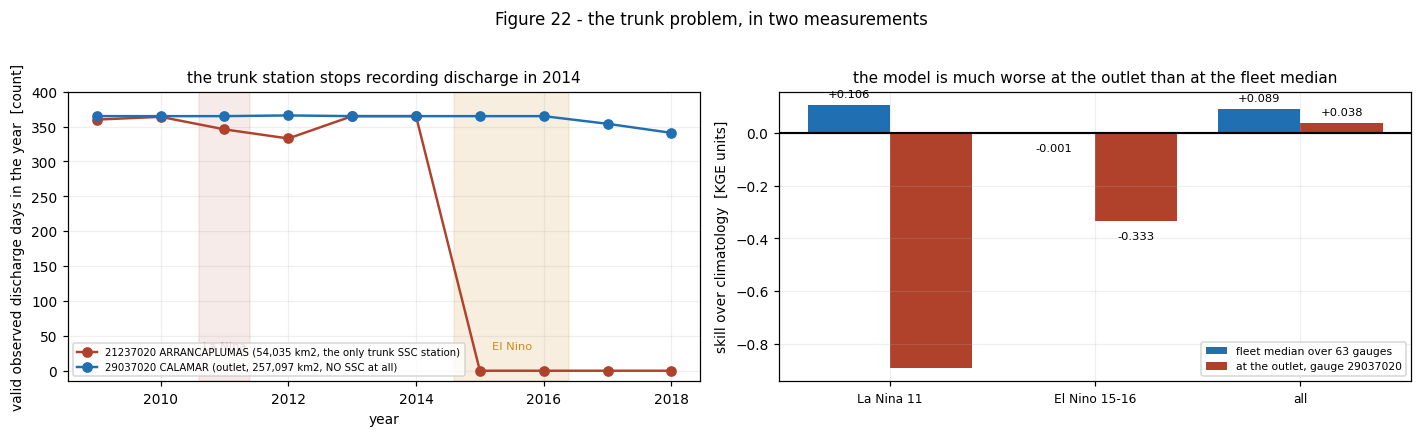

valid discharge days at 21237020 by year: 2009 360, 2010 364, 2011 346, 2012 333, 2013 365, 2014 365, 2015 0, 2016 0, 2017 0, 2018 0
  in the La Nina window: 346 days;  in the El Nino window: 0 days

skill over climatology at the outlet 29037020: La Nina 11 -0.8908, El Nino 15-16 -0.3329, all +0.0375
  against the fleet medians: La Nina 11 +0.1062, El Nino 15-16 -0.0005, all +0.0891
  -> in BOTH ENSO windows the outlet is far WORSE than a seasonal climatology, by a wide
     margin in La Nina. On VAL all it is marginally positive, because the four VAL
     sub-windows partly cancel - itself a warning about aggregate statistics. The fleet
     median hides all of this: the outlet is one gauge out of 63. Any basin-EXPORT
     sediment number inherits the error AT THE OUTLET, not the fleet-median error.


In [26]:
jc = OUTLET
jt = list(GC).index(TRUNK_SSC)
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
a = ax[0]
for nm, jj, col in ((f'{TRUNK_SSC} ARRANCAPLUMAS (54,035 km2, the only trunk SSC station)',
                     jt, '#B0412B'),
                    (f'{GC[jc]} CALAMAR (outlet, 257,097 km2, NO SSC at all)', jc, '#1F6FB2')):
    yrs = range(2009, 2019)
    vals = [int(np.isfinite(QOBS[Y == yy, jj]).sum()) for yy in yrs]
    a.plot(list(yrs), vals, 'o-', color=col, lw=1.6, label=nm)
a.axvspan(2010.6, 2011.4, color='#B0412B', alpha=.10)
a.axvspan(2014.6, 2016.4, color='#D08A1E', alpha=.14)
a.annotate('La Nina', (2011, 30), ha='center', fontsize=7.5, color='#B0412B')
a.annotate('El Nino', (2015.5, 30), ha='center', fontsize=7.5, color='#D08A1E')
a.set_xlabel('year'); a.set_ylabel('valid observed discharge days in the year  [count]')
a.set_ylim(-15, 400)
a.set_title('the trunk station stops recording discharge in 2014')
a.legend(fontsize=6.6, loc='lower left'); a.grid(alpha=.2)

a = ax[1]
per = ['VAL La Nina 11', 'VAL El Nino 15-16', 'VAL all']
xx = np.arange(len(per))
soc_fleet = [MINE.loc[p, 'skill_over_clim'] for p in per]
soc_out = []
for p in per:
    pm = PERIODS[p]
    km = kge_terms(QFIT[pm][:, jc], QOBS[pm][:, jc])
    kc = kge_terms(QCLIM[pm][:, jc], QOBS[pm][:, jc])
    soc_out.append(km['kge'] - kc['kge'])
a.bar(xx - 0.2, soc_fleet, 0.4, color='#1F6FB2', label='fleet median over 63 gauges')
a.bar(xx + 0.2, soc_out, 0.4, color='#B0412B', label=f'at the outlet, gauge {GC[jc]}')
a.axhline(0, color='k', lw=1.4)
for i, (u, v) in enumerate(zip(soc_fleet, soc_out)):
    a.annotate(f'{u:+.3f}', (i - 0.2, u + (0.03 if u >= 0 else -0.07)), ha='center', fontsize=7.5)
    a.annotate(f'{v:+.3f}', (i + 0.2, v + (0.03 if v >= 0 else -0.07)), ha='center', fontsize=7.5)
a.set_xticks(xx); a.set_xticklabels([p.replace('VAL ', '') for p in per], fontsize=8)
a.set_ylabel('skill over climatology  [KGE units]')
a.set_title('the model is much worse at the outlet than at the fleet median')
a.legend(fontsize=7); a.grid(alpha=.2)
fig.suptitle('Figure 22 - the trunk problem, in two measurements', y=1.03)
plt.tight_layout(); plt.show()

print(f'valid discharge days at {TRUNK_SSC} by year: '
      + ', '.join(f'{yy} {int(np.isfinite(QOBS[Y == yy, jt]).sum())}' for yy in range(2009, 2019)))
print(f'  in the La Nina window: {int(np.isfinite(QOBS[PERIODS["VAL La Nina 11"], jt]).sum())} '
      f'days;  in the El Nino window: '
      f'{int(np.isfinite(QOBS[PERIODS["VAL El Nino 15-16"], jt]).sum())} days')
print(f'\nskill over climatology at the outlet {GC[jc]}: '
      + ', '.join(f'{p.replace("VAL ","")} {v:+.4f}' for p, v in zip(per, soc_out)))
print(f'  against the fleet medians: '
      + ', '.join(f'{p.replace("VAL ","")} {v:+.4f}' for p, v in zip(per, soc_fleet)))
print('  -> in BOTH ENSO windows the outlet is far WORSE than a seasonal climatology, by a wide')
print('     margin in La Nina. On VAL all it is marginally positive, because the four VAL')
print('     sub-windows partly cancel - itself a warning about aggregate statistics. The fleet')
print('     median hides all of this: the outlet is one gauge out of 63. Any basin-EXPORT')
print('     sediment number inherits the error AT THE OUTLET, not the fleet-median error.')

**What is plotted.** Left: the number of valid observed discharge days per calendar year at
two stations - red, `21237020` ARRANCAPLUMAS, the only Magdalena-trunk sediment station; blue,
`29037020` CALAMAR, the basin outlet, which has no sediment data at all. The shaded strips mark
the two ENSO windows. Right: skill over climatology (in KGE units, dimensionless) for three
periods, comparing the fleet median over 63 gauges (blue) against the value at the outlet gauge
alone (red); the horizontal line at 0 is the level of a pure seasonal calendar.

**What it shows.** ARRANCAPLUMAS records discharge through 2009-2014 and then stops: it has 346
valid days in the La Nina window and **0** in the El Nino window. CALAMAR records throughout. On
the right, the outlet's skill over climatology is **$-0.891$** in La Nina and **$-0.333$** in El
Nino, against fleet medians of $+0.106$ and $-0.001$. On the combined `VAL all` window the outlet
reads **$+0.038$** against a fleet median of $+0.089$.

**What it means.** Three separate problems compound here, and none of them is an analysis choice.

First, the observed trunk sediment contrast the project set out to measure **cannot be computed**:
its one trunk station has sediment in both windows but discharge in only one, and flux requires
both.

Second, the model is **substantially worse at the outlet than its fleet median suggests** - far
worse than a seasonal climatology in *both ENSO windows*, which are the windows the project is
about. Note the aggregation trap in the third pair of bars: on the combined `VAL all` window the
outlet is marginally *positive* ($+0.038$), because the four VAL sub-windows partly cancel. So even
this diagnostic can be made to look acceptable by aggregating it, and the sub-window numbers are
the ones to quote. The fleet median is an average over 63 gauges of which the outlet is one, so it
does not represent the outlet, and a basin-export sediment number inherits the error at the outlet
rather than the fleet-median error. This is the discrepancy figure 1
flagged (outlet PBIAS $+18.3$ % against a fleet median of $+3.5$ %), and it is worse than that
figure alone implied. The likely mechanism is named in the project record - the model's routing
cannot represent the Mompos floodplain, a vast wetland that stores and releases water between the
Cauca confluence and the sea - but that is a hypothesis here, not a measurement.

Third, the two combine badly: the place where the project most needs a sediment observation is the
place where it has none, *and* the place where the water model is weakest. **A reader should not
accept any basin-export sediment figure from this project as validated.** It is a model
extrapolation below the last observation, on a reach where the water model fails its own
climatology benchmark.

## 8.2 - The rating-era segmentation is incomplete, and the break list is not on disk

Section 6.3 explained that rating fits must not cross a change point in the stage-discharge
relation. The change points come from an **SNHT** analysis (the standard normal homogeneity test,
a change-point test applied to a series to locate a step in its mean) performed at an earlier stage
of the project.

**The failure.** That analysis named **24** candidate break stations exceeding its test-statistic
threshold. **No results file exists on disk.** Only **7** station codes are recoverable, from
prose in the project's own documents and from a hard-coded list in one notebook generator. So the
era segmentation is complete only to the extent of those 7.

**What it actually cost, measured rather than feared.** Intersecting the 7 recoverable codes with
the 28 mapped sediment stations yields 3 hits, of which only one pair splits: the two BOCAS
stations `22017010` and `22017030`, at a break in February 2005, which is a verified physical
channel bifurcation. `25017020` SAN PEDRO carries a break in April 2009, but its sediment record
ends in October 1993, so the break falls outside the record and no split applies. **The net effect
of the missing list on this stage is therefore small** - 30 eras over 28 stations, only one pair
split - but that is luck rather than sufficiency: a station whose rating shifted mid-record and
whose break was among the 17 unrecoverable codes would have been fitted across the shift, and
nothing in this stage would detect it.

**Why it is not repaired here.** Re-running the SNHT analysis is discharge-QC work, not sediment
work, and doing it inside this stage would mean re-deriving a break list without the
pre-registration that governed the original. It is recorded as an open item.

## 8.3 - The fleet median hides the gauges that matter most

Recorded as its own problem because it changes how every number in section 2 should be read. The
objective, and every headline score, is a **median over 63 gauges**. That is the right statistic
for a calibration - it is robust and it does not let one mis-mapped gauge dominate - but it is the
wrong statistic for a sediment question, because the gauges that matter for sediment are not a
random sample of the 63. They are the large, low, trunk gauges, and section 8.1 shows the model is
worst exactly there. Concretely: fleet-median PBIAS $+3.5$ % against outlet PBIAS $+18.3$ %; and
in the two ENSO windows, fleet-median skill over climatology $+0.106$ / $-0.001$ against outlet
$-0.891$ / $-0.333$.

*This was not corrected by re-weighting*, and the reason is stated in 2.2: an area-weighted score
would import the unreliable catchment areas of 8.4 into every metric. The honest handling is to
report both numbers and to attach the outlet's, not the fleet's, to any export claim.

## 8.4 - Catchment areas are unreliable per gauge, so no yield in t/km^2/yr

An earlier stage of the project compared two independent implementations' per-gauge catchment
areas and found they disagree by more than a factor of two at **31 of 85** shared gauges - 36 %.
Because the two implementations were built independently and neither is demonstrably right, the
per-gauge area is not a trustworthy quantity.

**Specific erosion** or **specific yield** means an erosion or sediment-transport rate expressed
per unit area, in t/km^2/yr - the standard way such numbers are reported in the literature, and the
only way they are comparable between basins. It is obtained by dividing a flux by a catchment area.
Therefore **any gauge-referenced yield in t/km^2/yr inherits the area error one-for-one**, and this
project has embargoed the quantity: absolute flux only, in t/day or Mt/yr, until an independent
area arbiter exists. **No number in this notebook is divided by a catchment area**, and section 1.4's
cell says so where the areas are loaded. A model-internal specific erosion rate, computed on the
model's own grid where the area is a defined property of the grid rather than a snapped estimate,
is a different quantity and is not embargoed - but it must be labelled as model-internal.

## 8.5 - The 46 unmapped stations: an exclusion that is not a quality judgement

46 of the 79 sediment stations have **no coordinates at all** - no latitude or longitude in any
inventory in this project. They cannot be placed on a minibacia, so they cannot be compared with a
model output, so they are excluded. A further 5 do carry coordinates but fall outside the
8,672-minibacia network; they are the Cienaga Grande de Santa Marta / lower-Magdalena east-bank
group, tributaries of a coastal lagoon system rather than of the Magdalena.

Two things must be said about this.

First, **it is an exclusion on grounds of georeferencing, not of data quality.** Some of those 46
may hold excellent records. The project's own record labels recovering their coordinates as a
background task, and if it succeeded the usable set could grow substantially - 46 is more than
twice the size of the entire mapped set.

Second, calling all 51 "no coordinates" would have been wrong, and the distinction was made
explicitly: 46 have no coordinates, 5 are outside the domain. Collapsing them would have hidden the
fact that 5 stations are excluded for a reason that no amount of coordinate recovery would fix.

## 8.6 - Claims that were refuted, and beliefs this stage corrected

Recorded plainly, because a project that only records its successes is not auditable.

| the earlier claim | the measurement that refuted or corrected it |
|---|---|
| "The dry phase turns from worse-than-climatology to better than climatology." Stated in a project presentation. | True of attempt 1 to attempt 2. **Not true of the adopted configuration**: across attempts 2, 3 and 4 El Nino skill over climatology reads $+0.026 \rightarrow +0.006 \rightarrow -0.0005$. H2E sits *at* climatology. Figure 3. |
| The sediment network's danger is flood-chasing, which inflates concentration. | The fleet is marginally **low**-flow biased (median sampled-day percentile 0.470) and its most extreme station is extreme in the *opposite* direction (`21147030`, 0.115). The one-sided registered rule cannot see this. Figure 13. |
| The sediment network might be censored at a laboratory detection limit. | **Tested and negative.** Largest pile-up at any station's own minimum is 0.457 % of its samples, and station minima span 0 to 32 mg/L rather than sharing a floor. Figure 17. |
| A rating $R^2$ of about 0.55 shows discharge predicts sediment well. | **Inflated by construction.** $Q_s = Q\cdot C\cdot 0.0864$ contains $Q$. The same 30 fits give a concentration $R^2$ of **0.125**. Figures 10 and 20. |
| Imposing $k_{int} < k_{bas}$ fixes the inverted store ordering. | The constraint holds and the inversion **relocated**: surface response is now 22.2x slower than interflow, a pair the constraint does not cover. Third instance of the same pattern. Figure 6. |
| Flood peaks are about 18 % low ($R_{AMS} = 0.820$). | This notebook measures $R_{AMS}$ = **0.734** as a median of ratios and **0.551** as a ratio of medians on the frozen archive. Same sign, same order, different level; the published figure does not state its aggregation. Figure 7. |
| The reporting-density rainfall gradient is 4.38 / 6.75 / 11.69 mm/day. | Station counts reproduce **exactly** (92 / 119 / 83) but the levels measured here are 4.859 / 6.994 / 12.052 mm/day. Gradient, sign and ordering reproduce; level does not. Figure 11. |
| The selectivity null would be calibrated empirically on calendar-regular stations. | **Could not be done.** The network is near-daily with multi-year outages, so only 2 stations qualified against a threshold of about 10, and the registered theoretical fallback fired. The null used is anti-conservative in a known direction. Section 5.4, figure 16. |

## 8.7 - What remains open

1. **The selectivity rule is one-sided.** Four stations are strongly *low*-flow biased and are not
   flagged. A future revision should make the test two-tailed.
2. **The selectivity null is anti-conservative** by an unquantified amount, because of discharge
   autocorrelation. No effective-sample-size correction and no power calculation were done.
3. **Calendar-regularity should be defined on within-active-segment gaps**, not raw gaps. As
   registered it is defeated by multi-year outages. A sensitivity variant raises the qualifying
   pool only from 2 to 6, so the conclusion does not change, but the diagnostic is broken.
4. **17 of 24 SNHT break codes are unrecoverable** (8.2), so era segmentation is incomplete.
5. **46 stations lack coordinates** (8.5); recovering them is the single largest available
   expansion of the usable set.
6. **`21237020`'s post-2014 discharge is missing** (8.1). Recovering it would, on its own, create
   the observed trunk ENSO contrast the project currently cannot produce.
7. **`21197010` EL PROFUNDO carries an uncorroborated 15,180 mg/L spike inside the El Nino
   window** - 91 times its own 99th percentile - at an otherwise both-window usable station. It was
   not deleted, on the registered principle that extremes are corroborated rather than removed. The
   next stage must bound or exclude that single point explicitly rather than let it into a sample
   mean.
8. **`21237020` is `usable` on exactly 91 La Nina samples - exactly the registered $N$.** One
   sample fewer and the only Magdalena-trunk station would be single-window. That is not a defect,
   but it is a coincidence a reader should know about.
9. **$\theta_{crit} = 0.6$ has no sensitivity test** (2.1).
10. **`kc_mult` = 1.6625 is still above the FAO-56 plausible bar** of about 1.2 for this land cover
    mix. It came off its rail but it did not come down to a defensible level, so it remains a
    calibration coefficient absorbing something else.

## 8.8 - What a reader should NOT conclude

- **Not** that the water model is validated. It reproduces volume and recession well, timing
  poorly, flood peaks badly, and in both ENSO windows it is worse than a seasonal climatology at
  the basin outlet.
- **Not** that the El Nino half of this study rests on the same footing as the La Nina half. It
  does not: the model is at climatology in the dry phase, and the trunk station has no dry-phase
  discharge.
- **Not** that "18 usable stations" means 18 independent observations of the ENSO contrast. It
  means 7 stations observed in both windows, 6 more in La Nina only and 5 more in El Nino only.
- **Not** that flow-chasing has been ruled out at the 25 unflagged stations. The test that would
  have ruled it out could not be calibrated, and the substitute has unknown power.
- **Not** that a rating-derived sediment flux is a measurement. It is a fitted relation with a
  multiplicative uncertainty of about 2.25 either way on any single day, applied to a discharge
  value that is itself a fitted relation applied to a stage reading.
- **Not** that any t/km^2/yr figure may be quoted from this project's gauge-referenced results.
  They are embargoed (8.4).
- **Not** that the zero deletions in C1 mean the data are clean. C1 deleted nothing **by design** -
  extremes are corroborated and flagged rather than removed - so `sediment_daily_qc.csv` has the
  same 269,337 rows as `sediment_daily.csv`. The flags are the output, not a smaller file.

In [27]:
RAW = pd.read_csv(NEED['daily_raw'], dtype={'code': str}, low_memory=False)
print('C1 deleted nothing, by design - verified rather than asserted:')
print(f'  sediment_daily.csv    rows {len(RAW):,}   stations {RAW.code.nunique()}')
print(f'  sediment_daily_qc.csv rows {len(SD):,}   stations {SD.code.nunique()}')
print(f'  rows flagged c1_deleted: {int(SD.c1_deleted.sum())}')
assert len(RAW) == len(SD) and int(SD.c1_deleted.sum()) == 0
_v = SD[SD.ssc.notna()]
print(f'\nwhat C1 produced instead of deletions, on {len(_v):,} valid rows:')
print(f'  flag_flatline            {int(_v.flag_flatline.sum()):>7,}  '
      f'({100*_v.flag_flatline.mean():.4f} % of valid days)')
print(f'    -> vs the corrected quantisation nulls: '
      f'{100*_v.flag_flatline.mean()/0.030:.2f}x the within-year null (0.030 %), '
      f'{100*_v.flag_flatline.mean()/0.234:.3f}x the within-14-day null (0.234 %)')
print(f'  flag_zero                {int(SD.flag_zero.sum()):>7,}  on '
      f'{SD.loc[SD.flag_zero, "code"].nunique()} stations, of which '
      f'{int(SD.flag_missing_coded_as_zero.sum())} adjudicated missing-coded-as-zero')
print(f'  flag_extreme_candidate   {int(SD.flag_extreme_candidate.sum()):>7,}  of which '
      f'{int(SD.extreme_corroborated.sum())} corroborated; 0 deleted')
_mx = SD[SD.flag_extreme_candidate & SD.code.isin(codes)].nlargest(3, 'ssc_mean_mg_l')
print('\n  the consequential extreme candidates inside the mapped set:')
print(_mx[['code', 'date', 'ssc_mean_mg_l', 'extreme_corroborated']].to_string(index=False))
print('\nA quality gate whose output is a smaller file has thrown away evidence. This one\'s')
print('output is a set of flags plus a per-station verdict, so every decision stays checkable.')

C1 deleted nothing, by design - verified rather than asserted:
  sediment_daily.csv    rows 269,337   stations 79
  sediment_daily_qc.csv rows 269,337   stations 79
  rows flagged c1_deleted: 0

what C1 produced instead of deletions, on 269,337 valid rows:
  flag_flatline                952  (0.3535 % of valid days)
    -> vs the corrected quantisation nulls: 11.78x the within-year null (0.030 %), 1.511x the within-14-day null (0.234 %)
  flag_zero                    385  on 17 stations, of which 380 adjudicated missing-coded-as-zero
  flag_extreme_candidate        33  of which 2 corroborated; 0 deleted

  the consequential extreme candidates inside the mapped set:
    code       date  ssc_mean_mg_l  extreme_corroborated
24037390 2018-08-21   15901.168859                 False
21197010 2016-06-04   15179.805002                 False
22017010 2012-01-17    1733.000000                 False

A quality gate whose output is a smaller file has thrown away evidence. This one's
output is a se

**What this cell shows (no figure).** `sediment_daily_qc.csv` has exactly the same 269,337
rows and 79 stations as `sediment_daily.csv`, and zero rows carry `c1_deleted`. Instead the gate
produced flags: 952 flatline rows (0.3535 % of valid days, which is 11.78 times the corrected
within-year quantisation null of 0.030 % but only 1.511 times the within-14-day null of 0.234 %),
385 zero rows across 17 stations of which 380 were adjudicated as missing-coded-as-zero, and 33
extreme candidates of which 2 were corroborated and **none** deleted.

**What it means.** The flatline excess is real against the within-year null and marginal against
the within-14-day null, and since concentration measurements at a station genuinely do repeat over
a fortnight, the 1.5x figure is the one to believe. No station was classified on flatlining
because the largest flatline share at any mapped station is 3.40 % of its valid days - too small
to move a coverage count or a rating fit. The zeros are almost entirely in the unmapped coastal
group that is excluded anyway: only 2 zero rows fall inside the 28 mapped stations. And the
extreme policy is the important one: **corroborate, then flag, never silently delete.** The
project's own source paper had a 744 mg/L peak that turned out to be real, so a delete-the-outlier
rule would have destroyed a true observation. The cost of this policy is that a genuinely wrong
value stays in the file with a flag on it, which puts the burden on downstream code to respect the
flag - and item 7 of section 8.7 is exactly that burden coming due.

---

# 9 - What C0 and C1 hand forward, and the vocabulary of the next stage

C0 hands forward a frozen water model. C1 hands forward a named set of stations. Between them they
define what the sediment stage may and may not attempt. The terms below appear here for the first
time and are defined because a reader of this notebook will meet them immediately afterwards; the
*levels* of these quantities are not this notebook's subject and are not quoted.

**MUSLE** - the Modified Universal Soil Loss Equation (Williams, 1975). An empirical predictor of
the sediment mass delivered from a patch of land by a single runoff event. In the form this project
uses,

$$S \;=\; \alpha \left(Q_{surf}\, q_{peak}\, A\right)^{\beta} \cdot K \cdot C \cdot P \cdot LS$$

where $S$ is sediment yield for the event (tonnes), $Q_{surf}$ is the surface-runoff depth for the
event (mm), $q_{peak}$ is the peak runoff *rate* (m^3/s), $A$ is the area of the unit (here km^2 or
ha depending on the unit convention, which is exactly why unit conventions are dangerous in this
equation), and $\alpha$, $\beta$ are fitted coefficients ($\beta$ dimensionless, $\alpha$ carrying
whatever units make the equation balance). The five factors are:

| factor | name | what it is | units |
|---|---|---|---|
| $K$ | soil erodibility | how easily this soil detaches, from soil texture and organic matter | depends on unit system; a known trap |
| $C$ | cover management | how much the vegetation and residue protect the surface; 1 for bare soil, small for dense forest | dimensionless |
| $P$ | support practice | the effect of contouring, terracing and similar; 1 when no practice is credited | dimensionless |
| $LS$ | slope length and steepness | the topographic amplification of erosion | dimensionless |
| $\alpha, \beta$ | the MUSLE coefficients | the empirical scaling of yield with the runoff-energy product | $\beta$ dimensionless |

Note what MUSLE requires and what C0 therefore had to freeze: it needs **surface runoff** and a
**peak rate**, not total discharge. Section 1.2 explained why that makes the store partition
(figure 6) and the peak deficit (figure 7) the two inherited defects that matter most.

**Sediment delivery ratio (SDR).** MUSLE predicts erosion *on hillslopes*. Not all of that eroded
material reaches a river: much is deposited at the base of slopes, in field margins, in floodplains
and in channels. The SDR is the fraction that does arrive,

$$\mathrm{SDR} \;=\; \frac{\text{sediment yield at the outlet}}{\text{gross erosion upstream}}$$

dimensionless, in $(0,1]$. It is a notoriously slippery quantity because the numerator and
denominator must be defined consistently: an *all-source* gross erosion (hillslope plus channel
plus gully) gives a different ratio from a *hillslope-only* denominator, and the two can differ by
a factor of two in the same watershed. **This project's record establishes that no citable SDR band
exists for a basin at this scale, and that the SDR gate it originally proposed was therefore
retired as not evaluable - which is neither a pass nor a fail.** No SDR band is used anywhere in
this notebook, and none should be inferred from it.

**Specific erosion** was defined in 8.4 and is embargoed for gauge-referenced results.

**What C1 permits and forbids, in one list:**

- Permitted: a contrast of sediment flux **rates** between the two ENSO windows, at the 7
  both-window stations, expressed as mass per unit time.
- Permitted: the same contrast at 13 and 12 stations respectively if the station sets are allowed
  to differ, provided the confound is stated.
- Permitted: rating-derived fluxes at all 18 usable-or-caveated stations, with the $\times/\div 2.25$
  residual band propagated.
- Forbidden: a sample-mean flux at `26237020` PENALTA (flow-selective, $\Delta = +0.276$).
- Forbidden: any total (rather than rate) compared across the two windows, because they are 12 and
  24 months long.
- Forbidden: any observed sediment claim about the Magdalena trunk in the El Nino window, because
  the one trunk station has no discharge there.
- Forbidden: any gauge-referenced t/km^2/yr figure.
- Forbidden: any day-specific model-versus-observation sediment claim, because model daily timing
  is at $r \approx 0.59$ and at climatology in the dry phase.

# 10 - Every choice in this stage, with the alternative it rejected

| choice | taken | rejected, and why |
|---|---|---|
| Freeze the hydrology before sediment work | Yes - parameters, flows and drivers written to read-only artifacts | Letting sediment calibration adjust hydrology. Figure 1 measures the cost: two defensible configurations differ by 27 % in water volume, so an unfrozen model makes any sediment result a function of run order |
| The reproduction gate quantity | Re-evaluate the objective $F$ end to end, bar $10^{-8}$ | Comparing stored parameter bytes. That tests nothing about the pipeline that produced them; re-evaluating $F$ exercises forcing, engine, router and objective together |
| ET stress form | FAO-56 threshold, $\theta_{crit}$ fixed at 0.6 before the run | Fitting $\theta_{crit}$ (trades directly against $k_c$ and $W_m$, pure added equifinality); a Feddes form with a water-logging limb (the basin's problem is dry-season ET, so the extra parameter would be unconstrained) |
| Fleet aggregation of skill | Median over 63 gauges | Area-weighted mean, which is the natural basin statistic but would import the unreliable per-gauge areas of 8.4 into every score. The cost of the median is 8.3, and both numbers are reported |
| Validation design | Klemes differential split-sample: fit on 2012-2014 neutral years only | Fitting on all years. Would put an ENSO extreme in calibration and make the project's headline contrast partly circular |
| The comparability yardstick | Skill over a day-of-year climatology | NSE alone (window-dependent denominator, figure 3); a persistence benchmark (too strong on autocorrelated daily flow to isolate rainfall-runoff skill) |
| Recession scoring | Log-ratio of simulated to observed constant, symmetric, weight 0.20 | Squared error on the constants (scale-dependent, the slowest gauge dominates); constraining `k_bas` directly (asserts the mechanism instead of measuring the signature) |
| Recession and peak statistics | Report **both** aggregation conventions | Picking the kinder one after seeing the numbers. Both conventions are reported for the recession ratio and for $R_{AMS}$, and both disagreements with the documented levels are stated |
| Sample-count threshold $N$ | The knee of the distribution, floor $N \ge 12$, chosen and journalled before classification | Choosing $N$ after seeing which stations pass. The sensitivity is stated: 91 versus 12 moves exactly one station |
| Selectivity statistic | Median **flow percentile** of sampled days | Mean discharge on sampled days versus all days, which confounds the question with the shape of the flow distribution. Percentiles are distribution-free so 0.5 is the null for any river |
| Selectivity null | Registered empirical null on calendar-regular stations; **registered theoretical fallback used** because only 2 qualified | Redefining calendar-regularity after the fact to enlarge the pool. That is threshold tuning; the failure is recorded instead (5.4) |
| Consequence of a selectivity flag | A caveat - rating-only flux | Exclusion. The null in use over-flags, so exclusion on a flag would discard stations on a test known to be too tight |
| Extreme values | Corroborate, flag, never delete | Deleting outliers. The project's source paper had a real 744 mg/L peak; a delete rule destroys true observations. Cost: item 7 of 8.7 |
| Rating fits | Per station **per era**, never pooled across a change point | Pooling the whole record. A rating shift inside a pooled fit looks like a climate signal |
| Which rating $R^2$ to report | **Both**, and name $\ln C \sim \ln Q$ as the honest one | Reporting only $\ln Q_s \sim \ln Q$ at 0.55, which is inflated because $Q_s$ contains $Q$ |
| Yields | Absolute flux only | t/km^2/yr, embargoed while 36 % of shared gauges disagree by over 2x on catchment area |
| Peak deficit | Accept it; report sediment as a lower bound | Refitting to reach the peak band. That refit was run and **rejected**: it reached the band only by railing $k_c$ and zeroing the leaf-area multiplier, i.e. by deleting canopy interception |

# 11 - Summary

**C0.** The hydrology is frozen at configuration **H2E** - v2 repaired rainfall forcing, the
revised objective with a recession term, FAO-56 threshold ET at $\theta_{crit} = 0.6$. Its
objective value $F = 0.25931$ reproduces from committed inputs with a relative difference of
**0.000e+00** against a bar of $10^{-8}$, and all $3 \times 63$ per-gauge terms reproduce
bit-for-bit. Out-of-sample fleet medians: KGE 0.356, $r$ 0.591, $\alpha$ 0.905, $\beta$ 1.035,
PBIAS $+3.51$ %, recession ratio within 1.17x on both definitions. Mass closes to
$9.66\times10^{-17}$ relative.

**The honest reading of C0.** The wet phase is predictable and the dry phase is not: skill over a
day-of-year climatology is **$+0.106$** in La Nina 2011 and **$-0.0005$** in El Nino 2015-16. The
model's remaining error is in timing, not volume, and timing is bounded by the rainfall field
(field LOOCV $r$ = 0.429, cited not recomputed here), not by the parameters. Flood peaks are
systematically low ($R_{AMS}$ 0.734 median-of-ratios, 0.551 ratio-of-medians, 70.0 % of gauge-years
under-predicted), which makes every simulated sediment number a **lower bound**. At the basin
outlet the model is far *worse* than a seasonal climatology in both ENSO windows ($-0.891$ in La
Nina, $-0.333$ in El Nino, against fleet medians of $+0.106$ and $-0.001$), so no basin-export
figure is validated.

**C1.** All **79** sediment stations are classified, each with the single measurement that decided
it: **6 usable, 12 usable-with-caveat, 61 excluded** (51 of those for georeferencing rather than
data quality). The working set is **18** stations - **13** covered in La Nina, **12** in El Nino,
**7** in both - split **8 mainstem / 20 tributary** among the 28 mapped, with exactly **one**
Magdalena-trunk sediment station in the whole network, and that one has no discharge in the El Nino
window. Nothing was deleted: the gate's output is 269,337 rows with flags, not a smaller file.

**The transposed lesson.** A value screen cannot see absent records. In the rainfall network 153 of
294 gauges had omitted their dry days, producing a 2.48x gradient in apparent rainfall against
reporting density that the repair collapsed to 1.04x, with a neighbour-based selectivity statistic
that reads 1.001 on the population that should be unbiased and fell from 1.777 to 1.040 on the
suppressed one. Transposed to sediment, the analogous test found flow-chasing at **one** station
(`26237020`, $\Delta = +0.276$), a fleet that is marginally **low**-flow biased (0.470) rather than
flood-chasing, and **no** detection-limit censoring. It also found a genuine failure: the null
could not be calibrated as registered - only 2 calendar-regular stations existed against a
requirement of about 10 - so the weaker theoretical null was used, it over-flags in a known
direction, and two of the three flags sit inside the region that weakness covers.

**What this stage does not license.** Any basin-export sediment claim; any observed trunk contrast
in the dry phase; any t/km^2/yr yield; any day-specific sediment claim; any assertion that
flow-chasing is ruled out at the unflagged stations. Sections 8.6 to 8.8 give the full list, with
the measurement behind each.